In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv(r"..\outputs\tnrera_projects_final.csv")

In [3]:
df.head()

,Source_File,Project_Name,Project_Details,Type_of_Building,Usage,Site_Extent_Sqm,Total_Dwelling_Units,Stage_of_Construction,Project_Completion_Date,Latitude,...,Other_Cost,Total_Project_Cost,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,Heights_m,Floor_mentions,Districts,_missing_fields,Project_Registration_No
0,V:\Project\Project_Stick\data_source\raw\TNRER...,CRT Magilagam,"Ward-E,Block-21,TS No.2/3,Periyar Nagar,Erode ...",Non-High Rise Building (NHRB),Residential,1149.22,30.0,Under Construction,18/09/2028,11.335912,...,16491620,152493877.0,0.00,3150.00,-,[],[],['Erode'],NaN,TN/10/Building/0519/2024
1,V:\Project\Project_Stick\data_source\raw\TNRER...,Mayflower East Gate,"Old S.F.No.418/2pt,New T.S.No.5/1,Block.07,War...",High Rise Building (HRB),Residential,2230.00,42.0,Under Construction,31/12/2026,11.219200,...,15982769,325982769.0,-,6260.08,-,[],[],['Coimbatore'],NaN,TN/11/Building/0301/2024
2,V:\Project\Project_Stick\data_source\raw\TNRER...,CASAGRAND ALPINE,proposed construction of Residential Group Dev...,Non-High Rise Building (NHRB),Residential,5672.98,144.0,Not Yet Started,30/04/2029,110616.100000,...,23029644,238444958.0,-,11986.17,599.16,[],"[{'block': None, 'base_level': 'Stilt', 'floor...",['Coimbatore'],NaN,TN/11/Building/0331/2024
3,V:\Project\Project_Stick\data_source\raw\TNRER...,TIARA,"S.F.NO:370/3,CHINNAVEDAMPATTI,COIM BATORE-641049",Non-High Rise Building (NHRB),Residential,1133.00,22.0,Under Construction,31/12/2029,110530.700000,...,2917400,36576500.0,-,2913.67,-,[],[],['Coimbatore'],NaN,TN/11/Building/0341/2024
4,V:\Project\Project_Stick\data_source\raw\TNRER...,PNR MODERNA,"SF NO 129/4B, RANI GARDEN, 3RD STREET,SINGANAL...",Non-High Rise Building (NHRB),Residential,719.99,14.0,Under Construction,28/02/2027,11.006265,...,11130881,80894099.0,-,1818.3,-,[],[],['Coimbatore'],NaN,TN/11/Building/0344/2024


In [4]:
# Drop Stage_of_Construction , Project_Completion_Date , _missing_fields  
df = df.drop(['Stage_of_Construction', 'Project_Completion_Date', '_missing_fields','Source_File'], axis=1)

In [5]:
# Rearrange columns - > Project_Name, Project_Registration_No , Project_Details , Districts , Latitude , Longitude ,Usage 
# ,Type_of_Building ,Site_Extent_Sqm,FSI_LIG_Residential ,FSI_Other_Residential ,FSI_Commercial ,Total_Dwelling_Units ,Land_Cost 
# ,Construction_Cost ,Other_Cost , Total_Project_Cost ,Covered_Parking,Open_Parking ,Visitor_Parking ,Floor_mentions  ,Heights_m 

df = df[['Project_Name', 'Project_Registration_No', 'Project_Details', 'Districts', 'Latitude', 'Longitude', 'Usage', 
        'Type_of_Building', 'Site_Extent_Sqm', 'FSI_LIG_Residential', 'FSI_Other_Residential', 'FSI_Commercial',
        'Total_Dwelling_Units', 'Land_Cost', 'Construction_Cost', 'Other_Cost','Total_Project_Cost', 'Covered_Parking',
        'Open_Parking', 'Visitor_Parking', 'Floor_mentions', 'Heights_m']]




In [6]:
df.shape

(1030, 22)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Project_Name             1027 non-null   object 
 1   Project_Registration_No  1030 non-null   object 
 2   Project_Details          1027 non-null   object 
 3   Districts                1030 non-null   object 
 4   Latitude                 1027 non-null   float64
 5   Longitude                1027 non-null   float64
 6   Usage                    1027 non-null   object 
 7   Type_of_Building         1027 non-null   object 
 8   Site_Extent_Sqm          1027 non-null   float64
 9   FSI_LIG_Residential      1000 non-null   object 
 10  FSI_Other_Residential    1000 non-null   object 
 11  FSI_Commercial           1000 non-null   object 
 12  Total_Dwelling_Units     943 non-null    float64
 13  Land_Cost                1026 non-null   float64
 14  Construction_Cost       

In [8]:
# Change data type of FSI_LIG_Residential, FSI_Other_Residential, FSI_Commercial, Other_Cost to float 

cols = ['FSI_LIG_Residential', 'FSI_Other_Residential', 'FSI_Commercial', 'Other_Cost']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[cols] = df[cols].astype(float)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Project_Name             1027 non-null   object 
 1   Project_Registration_No  1030 non-null   object 
 2   Project_Details          1027 non-null   object 
 3   Districts                1030 non-null   object 
 4   Latitude                 1027 non-null   float64
 5   Longitude                1027 non-null   float64
 6   Usage                    1027 non-null   object 
 7   Type_of_Building         1027 non-null   object 
 8   Site_Extent_Sqm          1027 non-null   float64
 9   FSI_LIG_Residential      885 non-null    float64
 10  FSI_Other_Residential    981 non-null    float64
 11  FSI_Commercial           358 non-null    float64
 12  Total_Dwelling_Units     943 non-null    float64
 13  Land_Cost                1026 non-null   float64
 14  Construction_Cost       

## Categorical Distribution

In [10]:
# Cleaning the Districts column to remove brackets and quotes, and stripping whitespace.

df["Districts"] = (
    df["Districts"]
    .astype("string")
    .str.replace(r"[\[\]']", "", regex=True)
    .str.strip()
)

df["Districts"].value_counts()

Districts
Chennai            483
Chengalpattu       160
Coimbatore         159
Kancheepuram        45
Tiruchirappalli     43
Madurai             28
Salem               22
Tiruvallur          22
Tirunelveli         11
Krishnagiri         11
Tiruppur             9
Erode                7
Vellore              7
                     3
Thanjavur            3
Sivagangai           3
Dindigul             3
Karur                2
Namakkal             2
Tirupathur           1
Tiruvannamalai       1
Virudhunagar         1
Ranipet              1
Nilgiris             1
Theni                1
Cuddalore            1
Name: count, dtype: Int64

In [11]:
# TOP 15 districts by project count
print("Top 15 districts by project count:")
df["Districts"].value_counts().head(15)


Top 15 districts by project count:


Districts
Chennai            483
Chengalpattu       160
Coimbatore         159
Kancheepuram        45
Tiruchirappalli     43
Madurai             28
Salem               22
Tiruvallur          22
Tirunelveli         11
Krishnagiri         11
Tiruppur             9
Erode                7
Vellore              7
                     3
Thanjavur            3
Name: count, dtype: Int64

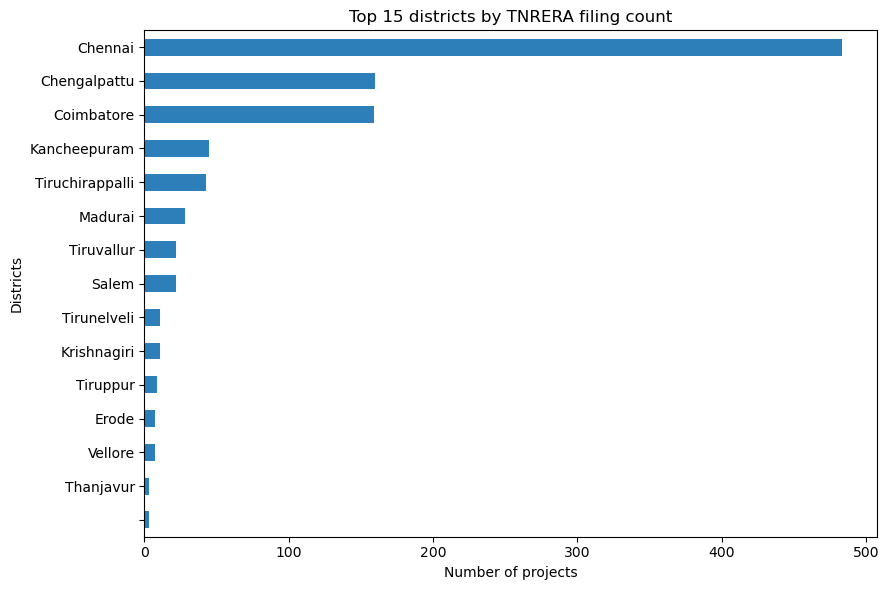

In [12]:
# Distribution of TOP 15 Districts by project count
fig, ax = plt.subplots(figsize=(9, 6))
df['Districts'].value_counts().head(15).sort_values().plot(kind='barh', ax=ax, color='#2c7fb8')
ax.set_xlabel('Number of projects')
ax.set_title('Top 15 districts by TNRERA filing count')
plt.tight_layout()
plt.show()


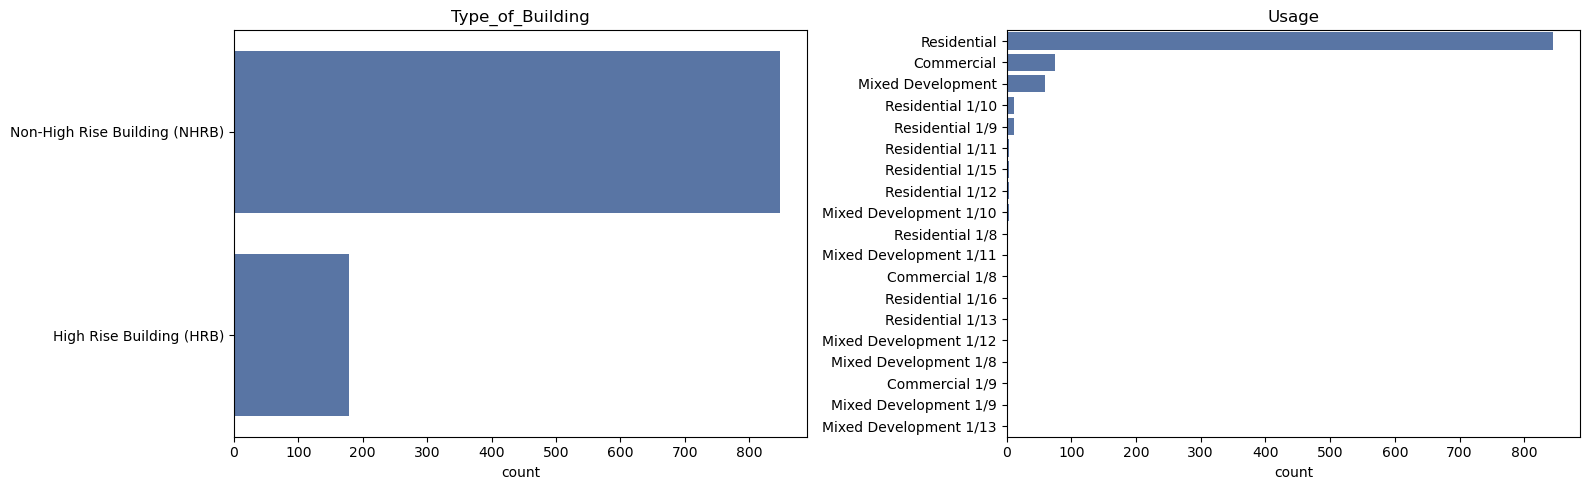

In [13]:

cat_cols = ['Type_of_Building', 'Usage']
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, color='#4c72b0')
    ax.set_title(col)
    ax.set_ylabel('')
plt.tight_layout()
plt.show()


## Numerical Distribution

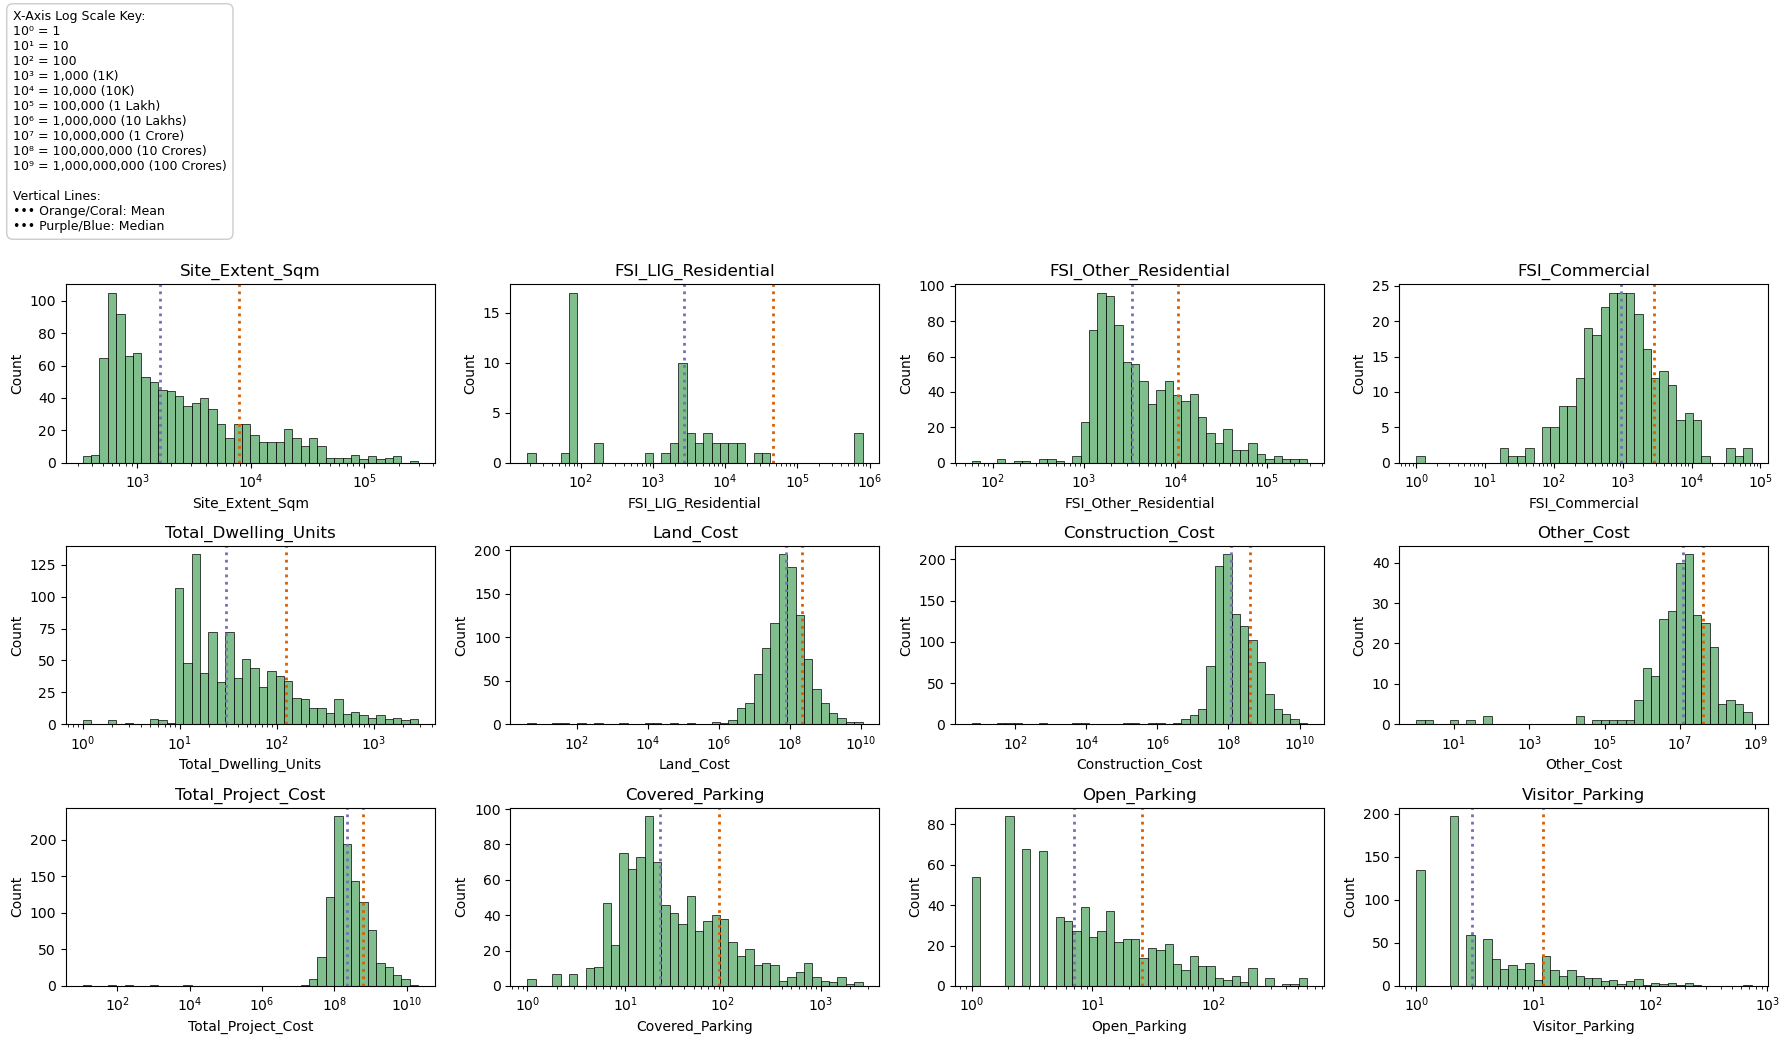

In [14]:


numeric_cols = [
    'Site_Extent_Sqm', 'FSI_LIG_Residential', 'FSI_Other_Residential',
    'FSI_Commercial', 'Total_Dwelling_Units', 'Land_Cost',
    'Construction_Cost', 'Other_Cost', 'Total_Project_Cost',
    'Covered_Parking', 'Open_Parking', 'Visitor_Parking'
]

fig, axes = plt.subplots(3, 4, figsize=(18, 8))

for ax, col in zip(axes.flat, numeric_cols):
    data = df[col].dropna()
    data = data[data > 0]
    
    # Plot histogram
    sns.histplot(data, ax=ax, bins=40, color='#55a868', log_scale=True)
    ax.set_title(col)
    
    # Calculate Mean and Median
    mean_val = data.mean()
    median_val = data.median()
    
    # Add vertical dotted lines
    ax.axvline(mean_val, color='#d95f02', linestyle=':', linewidth=2, label='Mean')
    ax.axvline(median_val, color='#7570b3', linestyle=':', linewidth=2, label='Median')

# Legend text to explain X-axis exponent values and vertical lines
x_legend_text = (
    "X-Axis Log Scale Key:\n"
    "10⁰ = 1\n"
    "10¹ = 10\n"
    "10² = 100\n"
    "10³ = 1,000 (1K)\n"
    "10⁴ = 10,000 (10K)\n"
    "10⁵ = 100,000 (1 Lakh)\n"
    "10⁶ = 1,000,000 (10 Lakhs)\n"
    "10⁷ = 10,000,000 (1 Crore)\n"
    "10⁸ = 100,000,000 (10 Crores)\n"
    "10⁹ = 1,000,000,000 (100 Crores)\n\n"
    "Vertical Lines:\n"
    "••• Orange/Coral: Mean\n"
    "••• Purple/Blue: Median"
)

# Placed on the top-left corner above the figure
fig.text(
    0.01, 1.02, x_legend_text, 
    ha='left', va='bottom', fontsize=9, multialignment='left',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#cccccc')
)

plt.tight_layout()
plt.show()

In [15]:
# Summary stats for the core numeric fields
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Site_Extent_Sqm,1027.0,7.936463e+03,2.240581e+04,332.0,7.490250e+02,1.589510e+03,4.726840e+03,2.968344e+05
FSI_LIG_Residential,885.0,2.919340e+03,4.574229e+04,0.0,0.000000e+00,0.000000e+00,0.000000e+00,8.012006e+05
FSI_Other_Residential,981.0,9.673731e+03,2.243866e+04,0.0,1.530060e+03,2.828580e+03,8.720020e+03,2.782915e+05
FSI_Commercial,358.0,2.160071e+03,6.608413e+03,0.0,4.589750e+01,5.329300e+02,1.664930e+03,7.465970e+04
Total_Dwelling_Units,943.0,1.237635e+02,3.025105e+02,1.0,1.500000e+01,3.000000e+01,9.000000e+01,2.880000e+03
Land_Cost,1026.0,2.029351e+08,6.046391e+08,0.0,3.034724e+07,7.437500e+07,1.600000e+08,1.100000e+10
Construction_Cost,1026.0,3.996782e+08,9.618872e+08,0.0,6.089973e+07,1.200000e+08,3.553395e+08,1.636254e+10
Other_Cost,312.0,3.578320e+07,9.163101e+07,0.0,2.000000e+06,1.000000e+07,2.893855e+07,8.031907e+08
Total_Project_Cost,1026.0,6.143387e+08,1.345967e+09,11.0,1.234882e+08,2.220123e+08,5.496500e+08,2.088336e+10
Covered_Parking,1024.0,8.528516e+01,2.184031e+02,0.0,1.100000e+01,2.000000e+01,6.425000e+01,2.668000e+03


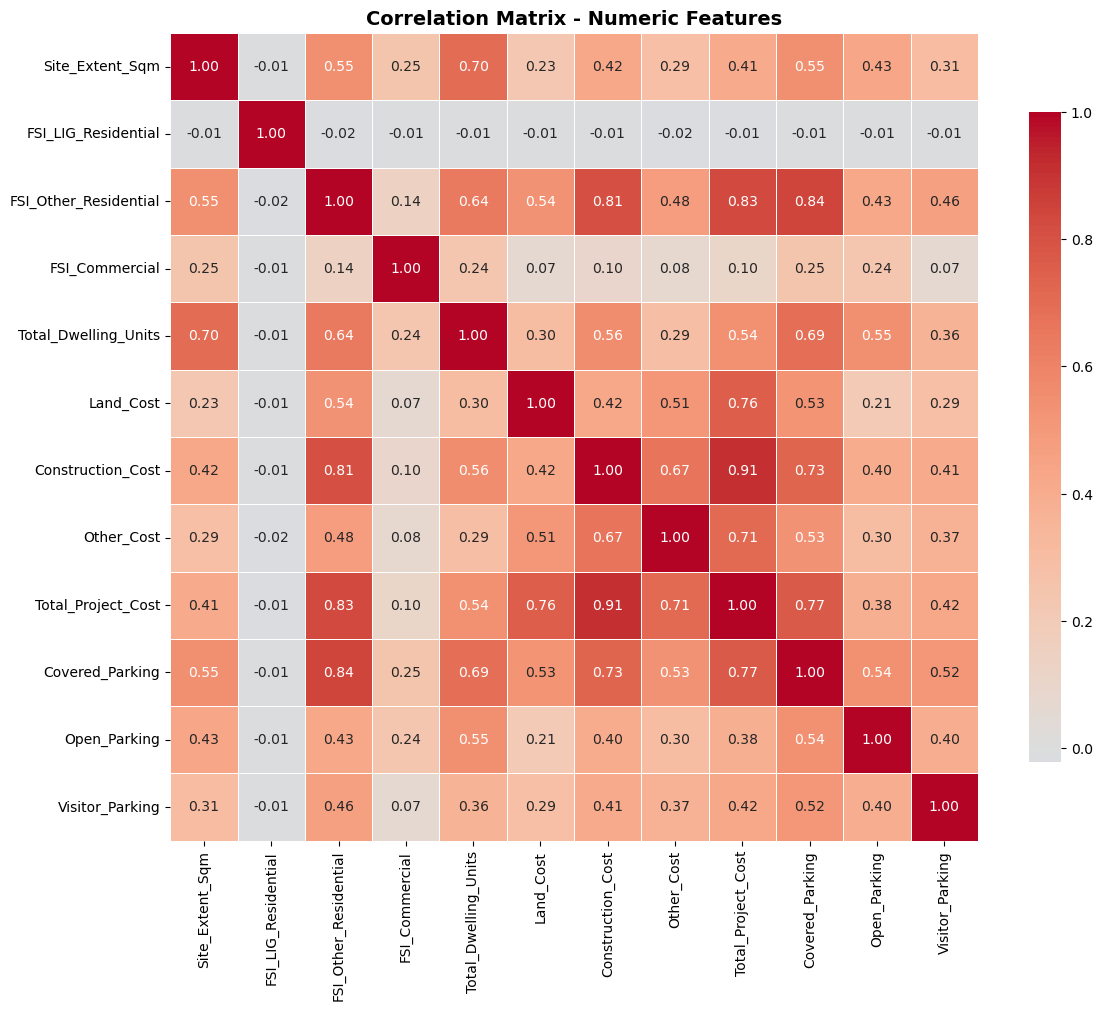

In [16]:
# Select only numeric columns for correlation analysis
numeric_features = df[numeric_cols].select_dtypes(include=['float64', 'int64'])

# Calculate correlation matrix
correlation_matrix = numeric_features.corr()

# Create correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix - Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Missing Values Check - 1st time

In [17]:

# Missing — sorted, as % of rows
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0]
missing_report


,missing_count,missing_pct
Other_Cost,718,69.7
FSI_Commercial,672,65.2
FSI_LIG_Residential,145,14.1
Total_Dwelling_Units,87,8.4
FSI_Other_Residential,49,4.8
Open_Parking,6,0.6
Covered_Parking,6,0.6
Visitor_Parking,6,0.6
Total_Project_Cost,4,0.4
Construction_Cost,4,0.4


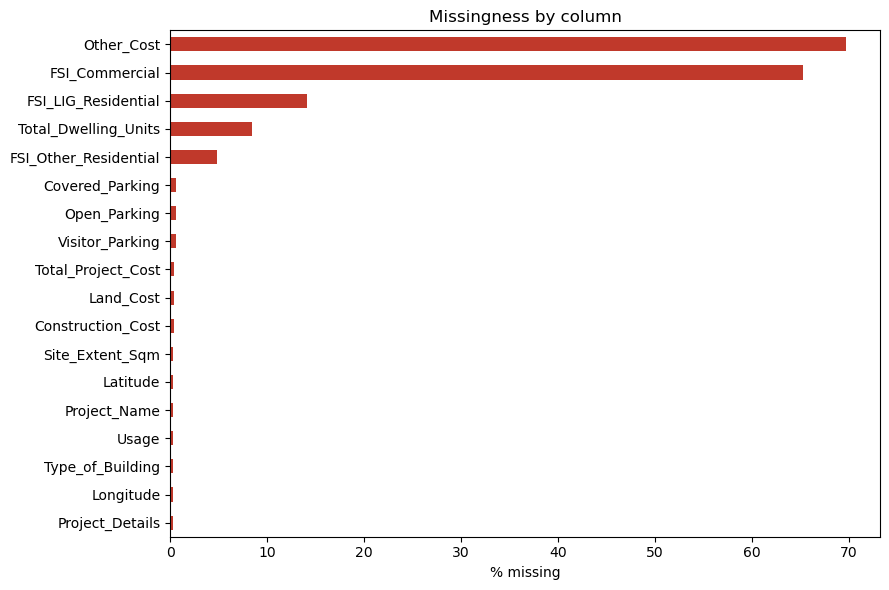

In [18]:

fig, ax = plt.subplots(figsize=(9, 6))
missing_report['missing_pct'].sort_values().plot(kind='barh', ax=ax, color='#c0392b')
ax.set_xlabel('% missing')
ax.set_title('Missingness by column')
plt.tight_layout()
plt.show()



Other_Cost column is part of the calculation in Total_Project_Cost. The missing values indicate there was no other cost involved in the particular project. 

FSI_Commercial & FSI_LIG_Residential missing values indicates a project might not be in that particular category. 

Total dwelling unit missing values could indicate a non residential project or actual missing values.

In [19]:

# Exact duplicate rows, and duplicate registration numbers (should be unique per project)
print(f"Fully duplicated rows: {df.duplicated().sum()}")
print(f"Duplicate Project_Registration_No: {df['Project_Registration_No'].duplicated().sum()}")
print(f"Duplicate Project_Name (expected — names repeat across phases/blocks): "
      f"{df['Project_Name'].duplicated().sum()}")


Fully duplicated rows: 0
Duplicate Project_Registration_No: 0
Duplicate Project_Name (expected — names repeat across phases/blocks): 61


In [20]:
##Cleaned versions usage column for analysis use.

df['Usage'] = df['Usage'].str.replace(r'\s*\d+/\d+\s*$', '', regex=True).str.strip()

print("Usage:")
usage_count = (df['Usage'].value_counts())

print(usage_count)

Usage:
Usage
Residential          881
Commercial            77
Mixed Development     69
Name: count, dtype: int64


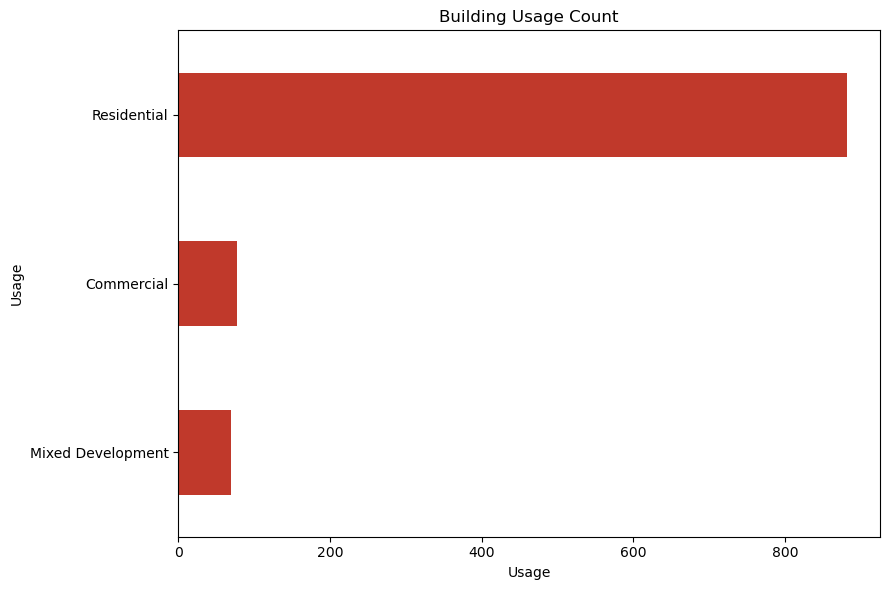

In [21]:
fig, ax = plt.subplots(figsize=(9, 6))
usage_count.sort_values().plot(kind='barh', ax=ax, color='#c0392b')
ax.set_xlabel('Usage')
ax.set_title('Building Usage Count')
plt.tight_layout()
plt.show()


## Checking Outliers and Missing Values 



#### Site Extent

In [22]:
df['Site_Extent_Sqm'].describe()

count      1027.000000
mean       7936.462687
std       22405.807936
min         332.000000
25%         749.025000
50%        1589.510000
75%        4726.840000
max      296834.440000
Name: Site_Extent_Sqm, dtype: float64

In [23]:
# Checking null values in site extent
df[(df['Site_Extent_Sqm'].isna())]

,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,...,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m
48,NaN,TN/11/Building/0603/2024,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[]
62,NaN,TN/16/Building/0541/2024,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[]
704,NaN,TN/35/Building/0172/2025,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[]


In [24]:
# Drop rows with null Site_Extent_Sqm values, as they are critical for analysis
df = df.dropna(subset=['Site_Extent_Sqm'])

<Axes: xlabel='Site_Extent_Sqm'>

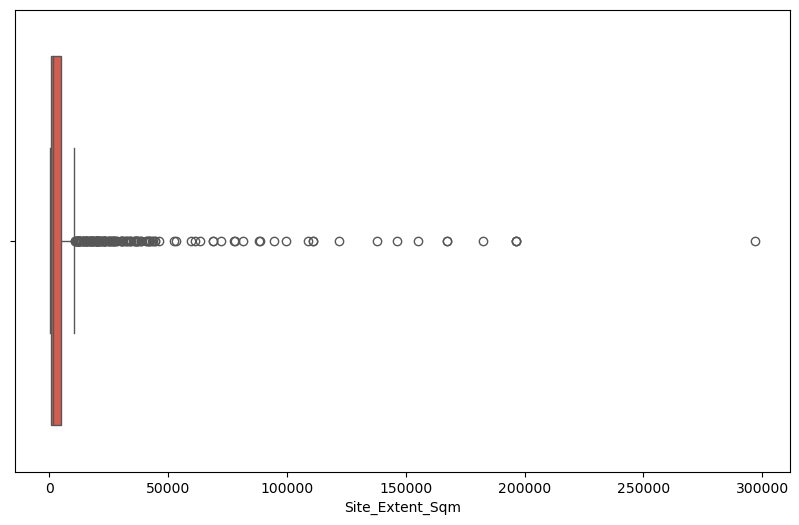

In [25]:
# Boxplot for Site_Extent_Sqm to visualize outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Site_Extent_Sqm'], color='#e74c3c')

In [26]:
# Show me the row with maximum Site_Extent_Sqm
df[df['Site_Extent_Sqm'] == df['Site_Extent_Sqm'].max()]

,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,...,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m
999,BLISS TOWER (TOWER A1-A2),TNRERA/35/BLG/0192/2026,LUXURIOUS HIGH RISE 2 & 3 BHK RESIDENTIAL APAR...,Chengalpattu,124825.9,801257.4,Residential,High Rise Building (HRB),296834.44,0.0,...,302.0,608000000.0,1.381378e+09,NaN,1.989378e+09,207.0,10.0,0.0,[],[]


 The project Bliss Tower is part of Pacifica township development. So this size of site extent is actual and not an error. We cant impute or remove and site extent values. 

#### Land_Cost, Construction_Cost, Other_Cost, Total_Project_Cost

In [27]:
# Suppress scientific notation and display 2 decimal places
pd.set_option('display.float_format', lambda x: '%.2f' % x)

df[
    [
        "Land_Cost",
        "Construction_Cost",
        "Other_Cost",
        "Total_Project_Cost",
    ]
].describe()

,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost
count,1026.00,1026.00,312.00,1026.00
mean,202935095.56,399678194.85,35783195.68,614338700.30
std,604639144.78,961887194.46,91631008.93,1345966972.88
min,0.00,0.00,0.00,11.00
25%,30347242.50,60899726.50,2000000.00,123488200.75
50%,74375000.00,120000000.00,10000000.00,222012273.50
75%,160000000.00,355339500.00,28938550.00,549650000.00
max,11000000000.00,16362541635.00,803190713.00,20883358736.00


This max value "11000000000.0" is a data entry error.  


In [28]:
# Find rows containing any of the reported maximum values
max_values = [11000000000.0, 16362541635.0, 803190713.0, 20883358736.0]

cost_columns = [
    "Land_Cost",
    "Construction_Cost",
    "Other_Cost",
    "Total_Project_Cost",
]

matching_rows = df[df[cost_columns].isin(max_values).any(axis=1)]

display(matching_rows)


,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,...,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m
286,PROVIDENT BAYSCAPE https://rera.tn.gov.in/publ...,TN/35/Building/0461/2024,The Promoter has legal title to the land on wh...,Chengalpattu,12.79,80.21,Residential,High Rise Building (HRB),23371.00,0.00,...,676.00,781119237.00,3690223848.00,803190713.00,5274533798.00,676.00,9.00,27.00,[],[]
386,RIVERA,TNRERA/29/BLG/0422/2025,The proposed construction of Stilt floor+ 5 fl...,Chennai,130141.00,801201.30,Residential,Non-High Rise Building (NHRB),683.00,0.00,...,15.00,11000000000.00,100000000.00,NaN,11100000000.00,14.00,3.00,2.00,"[{'block': None, 'base_level': 'Stilt', 'floor...",[18.3]
712,Prestige Pallavaram Estates Private Limited,TN/35/Building/0224/2025,The proposed construction of high-rise group d...,Chengalpattu,12.95,80.16,Mixed Development,High Rise Building (HRB),88389.50,0.00,...,2069.00,4520817101.00,16362541635.00,NaN,20883358736.00,2668.00,288.00,210.00,"[{'block': 'Block 14', 'base_level': 'Ground',...",[]


We can see from above "TNRERA/29/BLG/0422/2025"	project has error in data entry. impute the land cost column using the 
 median of Land_Cost

In [29]:
# Impute Land_Cost of TNRERA/29/BLG/0422/2025 using the median of Land_Cost for projects in the same district.

Median_Chennai_Land_Cost = df[df['Districts'] == 'Chennai'].Land_Cost.median()

df.loc[df['Project_Registration_No'] == 'TNRERA/29/BLG/0422/2025', 'Land_Cost'] = Median_Chennai_Land_Cost

In [30]:
# Check projects with all columns Land_Cost, Construction_Cost, Other_Cost, Total_Project_Cost as Null value

df[(df['Land_Cost'].isna()) & (df['Construction_Cost'].isna()) & (df['Other_Cost'].isna()) & (df['Total_Project_Cost'].isna())]


,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,...,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m
553,Powerkuppam Scheme 64 ( G+3 Floors),TN/29/Building/0082/2025,64 TENEMENTS AT POWERKUPPAM SCHEME IN R.S.NO.3...,Chennai,13733.32,801743.30,Residential,Non-High Rise Building (NHRB),10543.00,0.00,...,64.00,NaN,NaN,NaN,NaN,0.00,0.00,0.00,[],[]


In [31]:
# Provide project details of TN/29/Building/0082/2025

full_text = df[df['Project_Registration_No'] == 'TN/29/Building/0082/2025']['Project_Details'].iloc[0]
print(full_text)


64 TENEMENTS AT POWERKUPPAM SCHEME IN R.S.NO.3524 PART, 3527/1 and 2part, 3528/1 and 5, BLOCK.NO 52 OF TONDIARPET VILLAGE IN CHENNAI CORPORATION DIVISION 43 OF GCC ZONE-IV.


THe above project is a Tamil Nadu housing board project. We can drop this project as there is not enough details in them.

In [32]:
# Drop project TN/29/Building/0082/2025


df = df.drop(df[df['Project_Registration_No'] == 'TN/29/Building/0082/2025'].index)

#### FSI_LIG_Residential , FSI_Other_Residential , FSI_Commercial  

In [33]:
df[['FSI_LIG_Residential', 'FSI_Other_Residential', 'FSI_Commercial']].describe()

,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial
count,884.00,981.00,358.00
mean,2922.64,9673.73,2160.07
std,45768.08,22438.66,6608.41
min,0.00,0.00,0.00
25%,0.00,1530.06,45.90
50%,0.00,2828.58,532.93
75%,0.00,8720.02,1664.93
max,801200.60,278291.45,74659.70


In [34]:
# List rows where all three FSI_LIG_Residential , FSI_Other_Residential , FSI_Commercial areas equal to zero
df[(df['FSI_LIG_Residential'] == 0) & (df['FSI_Other_Residential'] == 0) & (df['FSI_Commercial'] == 0)]

,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,...,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m
173,KARGIL NAGAR SCHEME,TN/29/Building/0454/2024,Construction of (stilt + 15 floors) with 300 E...,Chennai,13.17,80.29,Residential,High Rise Building (HRB),52480.58,0.00,...,1200.00,0.00,1908800000.00,0.00,1908800000.00,0.00,0.00,0.00,"[{'block': None, 'base_level': 'Stilt', 'floor...",[]


In [35]:
# What is written in project details of the project with number TN/29/Building/0454/2024

df[df['Project_Registration_No'] == 'TN/29/Building/0454/2024']['Project_Details'].values[0]

'Construction of (stilt + 15 floors) with 300 Ews dwelling units totally1200 Ews (1192+8) units used for refuge area dewelling units abutting manali high ways bye pass road old S.no.618 G/3 Part T.S NO 1/1 & 3/1 , Block no.08, of thiruvottiyur Village, Greater Chennai coporation .'

In [36]:
# For project TN/29/Building/0454/2024, the FSI_LIG_Residential value can be imputed using the formula (Total_Dwelling_units * 40)
# This formula is based on TNRCDBR 2019, Chennai Metropolitan Area (CMA): Maximum carpet/plinth area of 40 sq.m per dwelling unit.  
# Rest of Tamil Nadu: Maximum carpet/plinth area of 60 sq.m per dwelling unit.

df.loc[df['Project_Registration_No'] == 'TN/29/Building/0454/2024', 'FSI_LIG_Residential'] = df.loc[df['Project_Registration_No'] == 'TN/29/Building/0454/2024', 'Total_Dwelling_Units'] * 40

df[df['Project_Registration_No'] == 'TN/29/Building/0454/2024']

,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,...,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m
173,KARGIL NAGAR SCHEME,TN/29/Building/0454/2024,Construction of (stilt + 15 floors) with 300 E...,Chennai,13.17,80.29,Residential,High Rise Building (HRB),52480.58,48000.00,...,1200.00,0.00,1908800000.00,0.00,1908800000.00,0.00,0.00,0.00,"[{'block': None, 'base_level': 'Stilt', 'floor...",[]


In [37]:
# # List rows where all three FSI_LIG_Residential , FSI_Other_Residential , FSI_Commercial areas equal to Nan

df[df[['FSI_LIG_Residential', 'FSI_Other_Residential', 'FSI_Commercial']].isnull().all(axis=1)]

,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,...,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m
81,RUBY COURTYARD,TN/1/Building/0518/2024,proposed construction of residential high rise...,Kancheepuram,12.89,80.03,Residential,High Rise Building (HRB),10560.00,NaN,...,286.00,203634830.00,736675243.00,34195695.00,974505768.00,259.00,27.00,22.00,"[{'block': 'block 1', 'base_level': 'Stilt', '...",[]
121,CASAGRAND HOLA CHENNAI https://rera.tn.gov.in/...,TN/29/Building/0352/2024,Proposed Construction of High Rise Group Devel...,Chennai,125325.63,80138.13,Residential,High Rise Building (HRB),121716.91,NaN,...,1818.00,3275402048.00,4073288500.00,461639363.30,7810329911.00,2262.00,502.00,214.00,"[{'block': 'Block 4-18) with Block 1', 'base_l...",[]
124,AYANA-95,TN/29/Building/0357/2024,Proposed Additional 5 th Floor Construction wi...,Chennai,13.08,80.15,Residential,Non-High Rise Building (NHRB),7902.00,NaN,...,185.00,210897000.00,375200000.00,43359000.00,629456000.00,136.00,49.00,15.00,[],[18.05]
125,BBCL SANSKRITI,TN/29/Building/0359/2024,STILT + 5 FLOORS CONSISTING 20 DWELLING UNITS,Chennai,13.04,80.22,Residential,Non-High Rise Building (NHRB),890.28,NaN,...,20.00,70000000.00,80000000.00,21000000.00,171000000.00,20.00,2.00,2.00,"[{'block': None, 'base_level': 'Stilt', 'floor...",[]
211,SHYAMALA,TN/29/Building/0543/2024,Proposed Construction of Stilt + 5 Floors Resi...,Chennai,13.00,80.25,Residential,Non-High Rise Building (NHRB),557.41,NaN,...,10.00,59400000.00,75880000.00,NaN,135280000.00,12.00,2.00,1.00,[],[]
268,CASAGRAND FRENCH TOWN https://rera.tn.gov.in/p...,TN/35/Building/0337/2024,Proposed Construction of Group Housing Develop...,Chengalpattu,801014.26,125233.43,Residential,Non-High Rise Building (NHRB),43542.49,NaN,...,639.00,69900000.00,1410900000.00,159800000.00,1640600000.00,694.00,0.00,63.00,"[{'block': None, 'base_level': 'Ground', 'floo...",[]
278,JONES CASSIA VIII https://rera.tn.gov.in/publi...,TN/35/Building/0431/2024,"S.NO284/1A, 285/1, 285/2A, 285/2B, 285/2C1A, 2...",Chengalpattu,12.87,80.19,Residential,Non-High Rise Building (NHRB),15146.00,NaN,...,66.00,85000000.00,448332500.00,65705684.00,599038184.00,131.00,10.00,13.00,"[{'block': None, 'base_level': 'Ground', 'floo...","[10.5, 10.5]"
324,RAVIMURUGAA'S WISTERIAA PARK,TNRERA/11/BLG/0417/2025,"S.F.NO:296/2B3A ,KALAPATTI VILLGE",Coimbatore,110328.70,770150.30,Residential,Non-High Rise Building (NHRB),4260.00,NaN,...,16.00,18000000.00,60000000.00,NaN,78000000.00,24.00,21.00,5.00,[],[]
369,Whispers of sky,TNRERA/29/BLG/0389/2025,"740/1 & 742/1A of Sholinganallur Village, Shol...",Chennai,125253.57,801257.39,Mixed Development,High Rise Building (HRB),24845.00,NaN,...,623.00,1025800000.00,3833700000.00,NaN,4859500000.00,626.00,46.00,46.00,[],[]
370,MERIDIAN,TNRERA/29/BLG/0390/2025,Revised Approval for Proposed Additional const...,Chennai,12.95,80.19,Commercial,Non-High Rise Building (NHRB),1389.00,NaN,...,NaN,112339470.00,134316142.00,NaN,246655612.00,15.00,10.00,3.00,"[{'block': None, 'base_level': 'Ground', 'floo...",[18.3]


There are quite a few missing values for all three FSI columns in a single project. Which means i dont know how much of construction is happening in that particular project. Now to impute these we will need to make some logic which will require some feature engineering first. So we will come back to these rows.

## Total Dwelling Units

In [38]:
# Describe Total DWelling units

df['Total_Dwelling_Units'].describe()

count    942.00
mean     123.83
std      302.66
min        1.00
25%       15.00
50%       30.00
75%       90.00
max     2880.00
Name: Total_Dwelling_Units, dtype: float64

In [39]:
# Select rows where usage is not Commercial and check the distribution of Total_Dwelling_Units

df_residential = df[df['Usage'] != 'Commercial']
df_residential['Total_Dwelling_Units'].describe()

count    939.00
mean     124.20
std      303.08
min        1.00
25%       15.00
50%       30.00
75%       90.00
max     2880.00
Name: Total_Dwelling_Units, dtype: float64

In [40]:
# Check null values in Total_Dwelling_Units column where usage is not Commercial

df_residential[df_residential['Total_Dwelling_Units'].isna()]

,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,...,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m
75,CASAGRAND ESTILO,TN/1/Building/0398/2024,Proposed Construction of Group Development Con...,Kancheepuram,80.84,12.58,Residential,Non-High Rise Building (NHRB),14164.00,NaN,...,NaN,304922592.00,447319440.00,50696203.00,802938235.00,233.00,24.00,24.00,"[{'block': 'Block – A', 'base_level': 'Ground'...",[]
226,GP HOMES ELANZA PHASE 2,TN/29/Building/0563/2024,PROPOSED CONSTRUCTION OF GROUP DEVELOPMENT WIT...,Chennai,130059.90,800930.30,Mixed Development,Non-High Rise Building (NHRB),2250.00,0.00,...,NaN,92000000.00,102500000.00,5500000.00,200000000.00,49.00,5.00,0.00,"[{'block': 'BLOCK – 1', 'base_level': 'Stilt',...","[18.0, 18.3]"
367,THE EDGE,TNRERA/29/BLG/0387/2025,High Rise Building (HRB) with 41.20M height co...,Chennai,13.05,80.25,Mixed Development,High Rise Building (HRB),2785.57,0.00,...,NaN,440000000.00,804357000.00,NaN,1244357000.00,95.00,0.00,12.00,"[{'block': None, 'base_level': 'Ground', 'floo...",[]
490,CASAGRAND HIGHCLERE,TN/1/Building/0177/2025,Proposed Construction of Residential Building ...,Kancheepuram,13.01,80.10,Residential,High Rise Building (HRB),12480.00,0.00,...,NaN,390000000.00,1750000000.00,NaN,2140000000.00,195.00,69.00,28.00,"[{'block': 'Block 1', 'base_level': 'Stilt', '...",[]
531,THE EDGE,TN/29/Building/0037/2025,NHRB (North) – Planning Permission for the Pro...,Chennai,13.08,80.11,Residential,Non-High Rise Building (NHRB),4807.00,0.00,...,NaN,100000000.00,20000000.00,NaN,120000000.00,103.00,6.00,9.00,"[{'block': None, 'base_level': 'Stilt', 'floor...",[18.3]
620,IYRA SPIRE,TN/29/Building/0217/2025,Proposed Construction of High Rise Residential...,Chennai,12.98,80.23,Residential,High Rise Building (HRB),4114.00,0.00,...,NaN,339900000.00,606100000.00,NaN,946000000.00,129.00,67.00,15.00,"[{'block': None, 'base_level': 'Basement', 'fl...",[]
647,The President By Asta,TN/29/Building/0288/2025,“The President” by Asta A High rise residentia...,Chennai,13.04,80.27,Residential,High Rise Building (HRB),7092.50,0.00,...,NaN,2775779061.00,1702900000.00,NaN,4478679061.00,349.00,17.00,37.00,"[{'block': None, 'base_level': 'Basement', 'fl...",[]
774,CASAGRAND ASCENTIA,TNRERA/11/BLG/0070/2026,PROPOSED CONSTRUCTION OF RESIDENTIAL NON HIGH ...,Coimbatore,11.09,76.97,Residential,Non-High Rise Building (NHRB),15950.00,0.00,...,NaN,470000000.00,1540000000.00,NaN,2010000000.00,246.00,0.00,24.00,"[{'block': 'BLOCK 1', 'base_level': 'Ground', ...",[]
913,CASAGRAND AQUAGROVE,TNRERA/29/BLG/0183/2026,Proposed Construction of High Rise Group Devel...,Chennai,13.15,80.19,Residential,High Rise Building (HRB),26950.00,0.00,...,NaN,1310000000.00,4840000000.00,NaN,6150000000.00,778.00,0.00,78.00,"[{'block': 'Block –1, Combined Extended 1st Ba...",[]
958,THE NEW TOWN,TNRERA/29/BLG/0276/2026,Group Housing Development: Block A: Stilt Floo...,Chennai,10.78,78.56,Residential,Non-High Rise Building (NHRB),7343.46,0.00,...,NaN,100000000.00,420000000.00,NaN,520000000.00,152.00,0.00,0.00,"[{'block': 'Block A', 'base_level': 'Stilt', '...","[18.3, 18.3, 18.3]"


We will come back to this after feature engineering

#### Covered_Parking, Open_Parking , Visitor_Parking


In [41]:
df[["Covered_Parking", "Open_Parking", "Visitor_Parking"]].describe()

,Covered_Parking,Open_Parking,Visitor_Parking
count,1023.00,1023.00,1023.00
mean,85.37,18.09,8.71
std,218.49,52.89,32.12
min,0.00,0.00,0.00
25%,11.00,0.00,0.00
50%,20.00,4.00,2.00
75%,64.50,13.00,5.50
max,2668.00,598.00,736.00


In [42]:
# Check project rows for  Visitors_Parking  > 10% of total parking (Covered_Parking + Open_Parking + Visitor_Parking)
# and number of dwelling unit is greater than 150


pd.set_option('display.max_rows', None)

total_parking = df['Covered_Parking'] + df['Open_Parking']

pd.set_option('display.max_columns', None)
df[(df['Visitor_Parking'] > 0.1 * total_parking) & (df['Total_Dwelling_Units'] > 50)]



,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m
6,ADHYA,TN/11/Building/0353/2024,"Adhya, SF.NO:577/1B2A, Chinnavedampatti Villag...",Coimbatore,11.04,76.59,Residential,Non-High Rise Building (NHRB),5046.84,NaN,14025.10,NaN,200.00,54450000.00,835820000.00,3000000.00,893270000.00,95.00,0.00,13.00,[],[]
25,CASAGRAND ORCHARDS PHASE I,TN/11/Building/0495/2024,Proposed Construction of Phase - I Non High Ri...,Coimbatore,11.00,77.06,Residential,Non-High Rise Building (NHRB),38525.75,0.00,23898.41,824.18,207.00,160000000.00,860000000.00,70000000.00,1090000000.00,222.00,0.00,24.00,"[{'block': 'Block - A', 'base_level': 'Ground'...",[]
28,SREE DAKSHA'S NEFELI,TN/11/Building/0500/2024,Proposed Residential Group Development Buildin...,Coimbatore,11.05,77.02,Residential,Non-High Rise Building (NHRB),18024.13,0.00,16905.42,538.70,86.00,98100000.00,918800000.00,75000000.00,1091900000.00,120.00,44.00,17.00,"[{'block': None, 'base_level': 'Ground', 'floo...",[]
46,PUNARJANI,TN/11/Building/0601/2024,RESIDENTIAL APPARTMENT,Coimbatore,10.99,76.93,Residential,Non-High Rise Building (NHRB),11654.97,0.00,6542.81,NaN,64.00,32500000.00,140200000.00,0.00,172700000.00,43.00,21.00,9.00,[],[]
54,Jeyam's Empire,TN/16/Building/0324/2024,Apartment,Tiruchirappalli,10.76,78.68,Residential,Non-High Rise Building (NHRB),5916.95,NaN,15230.28,NaN,130.00,200000000.00,510000000.00,40000000.00,750000000.00,95.00,35.00,16.00,[],[]
70,MARUTHAM ROYALGARDENS PHASE - II,TN/1/Building/0350/2024,"OLD SURVEY NO.267/1, AS PER PATTA NEW SURVEY N...",Kancheepuram,12.92,80.06,Residential,Non-High Rise Building (NHRB),3600.00,NaN,8790.35,450.45,75.00,13000000.00,298500000.00,49750000.00,361250000.00,7.00,8.00,7.00,[],[]
113,Construction of 80 HIG flats,TN/29/Building/0329/2024,construction of 80 Super HIG flats (stilt + 5 ...,Chennai,80.19,13.08,Residential,Non-High Rise Building (NHRB),6267.23,NaN,11611.84,153.75,80.00,539679200.00,928251000.00,77856360.00,1545786560.00,70.00,22.00,22.00,"[{'block': None, 'base_level': 'Ground', 'floo...",[]
114,LEGENDARY SUPER60,TN/29/Building/0330/2024,62 RESIDENTIAL UNITS,Chennai,13.02,80.21,Residential,Non-High Rise Building (NHRB),2095.88,NaN,5447.38,NaN,62.00,180000000.00,180000000.00,12000000.00,372000000.00,30.00,8.00,4.00,[],[]
144,BRIGADE ICON https://rera.tn.gov.in/public-vie...,TN/29/Building/0392/2024,"Extended 1st Basement floor for Block 1 & 3, B...",Chennai,13.03,80.15,Mixed Development,High Rise Building (HRB),1894.91,NaN,56496.55,35401.67,200.00,100013500.00,1275400.00,57510.00,101346410.00,773.00,0.00,117.00,"[{'block': 'Block 1 & 3, Block – 1', 'base_lev...",[]
146,GRANDEZZA,TN/29/Building/0399/2024,Stilt + 5 floors with 53 dwelling units and 5 ...,Chennai,13.07,80.19,Residential,Non-High Rise Building (NHRB),3314.00,NaN,8720.02,NaN,58.00,160000000.00,180000000.00,79641500.00,419641500.00,55.00,8.00,8.00,"[{'block': None, 'base_level': 'Stilt', 'floor...",[]


TN/29/Building/0175/2025, TNRERA/29/BLG/0364/2025, TN/5/Building/0203/2025, TNRERA/11/BLG/0198/2026, TNRERA/2/BLG/0220/2026

these projects have been flagged for the vistor car parking count. This has been based on the rule where visitore parking is way higher than 10% of total car parking. These can be imputed with the max(10% of total car park)


In [43]:
# Impute vistior parking for follwing projets TN/29/Building/0175/2025, TNRERA/29/BLG/0364/2025, TN/5/Building/0203/2025, 
# TNRERA/11/BLG/0198/2026, TNRERA/2/BLG/0220/2026
# Impute the visitor parking as 10% of total parking (Covered_Parking + Open_Parking) for these projects.


target_projects = [
    'TN/29/Building/0175/2025',
    'TNRERA/29/BLG/0364/2025',
    'TN/5/Building/0203/2025',
    'TNRERA/11/BLG/0198/2026',
    'TNRERA/2/BLG/0220/2026'
]

mask = df['Project_Registration_No'].isin(target_projects)

# Calculate 10% and round up to the nearest whole integer
df.loc[mask, 'Visitor_Parking'] = np.ceil(
    (df.loc[mask, 'Covered_Parking'].fillna(0) + df.loc[mask, 'Open_Parking'].fillna(0)) * 0.10
).astype(int)


In [44]:
# Check if changes have taken effect for the target projects

df[df['Project_Registration_No'].isin(target_projects)]

,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m
360,ALTITUDE 9 https://rera.tn.gov.in/public-view2...,TNRERA/29/BLG/0364/2025,CONSTRUCTION OF HIGH RISE BUILDING (HRB) CONSI...,Chennai,13.07,13.07,Residential,High Rise Building (HRB),3324.50,0.00,10989.42,294.00,75.00,620000000.00,700000000.00,NaN,1320000000.00,47.00,37.00,9.00,"[{'block': 'BLOCK 1', 'base_level': 'Ground', ...",[9.45]
599,Construction of High Rise Building consisting ...,TN/29/Building/0175/2025,Construction of High Rise Building consisting ...,Chennai,12.97,80.25,Commercial,High Rise Building (HRB),3380.00,0.00,0.00,13101.00,11.00,600000000.00,800000000.00,240000000.00,1640000000.00,183.00,15.00,20.00,"[{'block': None, 'base_level': 'Ground', 'floo...",[]
734,-,TN/5/Building/0203/2025,Stilt Floor + 13 floors Residential Building w...,Vellore,125810.24,790843.87,Residential,Non-High Rise Building (NHRB),5250.00,0.00,15310.96,397.27,132.00,106800000.00,598500000.00,NaN,705300000.00,78.00,77.00,16.00,"[{'block': None, 'base_level': 'Stilt', 'floor...",[]
798,PRINCE PROPERTY MANAGEMENT - PRINCE BLOSSOM,TNRERA/11/BLG/0198/2026,PROPOSED ADDITIONAL CONSTRUCTION OF 4 BLOCKS R...,Coimbatore,110457.70,770500.90,Residential,Non-High Rise Building (NHRB),21245.82,4777.50,38218.55,1670.35,250.00,250000000.00,663300000.00,NaN,913300000.00,182.00,71.00,26.00,"[{'block': None, 'base_level': 'Stilt', 'floor...",[]
970,SHRIRAM SWARGAM,TNRERA/2/BLG/0220/2026,"S.NO.399/1A, 1B, 1C, 1D,1E, 1F & 3B AND 418/1A...",Tiruvallur,800126.80,130251.00,Mixed Development,High Rise Building (HRB),35912.79,0.00,40199.69,0.00,429.00,122722081.00,1020252200.00,NaN,1142974281.00,30.00,175.00,21.00,[],[]


## Feature Engineering

1. Permissable Fsi = if Residential then 2 , If commericial then 2 for both high rise and non high rise. If high rise for both max premium fsi = 4.87. Rest of typology upto 2 fsi. 

2. Total FSI Area = FSI_LIG_Residential +	FSI_Other_Residential +	FSI_Commercial

3. FSI = TOTAL FSI Area / Site Extent 

4. Site_Extent_Sqft

5. Total_FSI_Area_Sqft

6. Total_Parking  = Covered_Parking + Open_Parking + Visitor_Parking + Imputed_Car_Parking

7. Construction_Cost_per_Sqft = Construction_Cost / Total FSI Area_Sqft

8. Construction_Cost_Ratio: Construction_Cost / Total_Project_Cost

8. Total_Project_Cost_per_Sqft = Total_Project_Cost / Total_FSI_Area_Sqft

9. Land_Cost_Ratio: Land_Cost / Total_Project_Cost

10. Cost_Per_Dwelling_Unit: Total_Project_Cost / Total_Dwelling_Units

11. Average_Unit_Size_Sqm: (FSI_LIG_Residential + FSI_Other_Residential) / Total_Dwelling_Units









In [45]:
df['Type_of_Building'].value_counts()

Type_of_Building
Non-High Rise Building (NHRB)    847
High Rise Building (HRB)         179
Name: count, dtype: int64

In [46]:
df['Type_of_Building'].unique()

array(['Non-High Rise Building (NHRB)', 'High Rise Building (HRB)'],
      dtype=object)

In [ ]:
import numpy as np

SQM_TO_SQFT = 10.7639

# Convert scraped numeric fields; blanks and '-' become missing values.
numeric_columns = [
    'Site_Extent_Sqm', 'FSI_LIG_Residential', 'FSI_Other_Residential',
    'FSI_Commercial', 'Total_Dwelling_Units', 'Land_Cost',
    'Construction_Cost', 'Other_Cost', 'Total_Project_Cost',
    'Covered_Parking', 'Open_Parking', 'Visitor_Parking'
]


for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

is_high_rise = df["Type_of_Building"] == "High Rise Building (HRB)"


# Convert Site Extent from Sqm to Sqft
df["FE_Site_Extent_Sqft"] = df["Site_Extent_Sqm"].mul(SQM_TO_SQFT)


# Calculate Total FSI Area in Sqft
df["FE_Total_FSI_Area_Sqft"] = (   
    df[[
        "FSI_LIG_Residential",
        "FSI_Other_Residential",
        "FSI_Commercial",
    ]].sum(axis=1, min_count=1).mul(SQM_TO_SQFT).round()        # COnverting from Sqm to Sqft and rounding to nearest whole number
)

# Calculate FSI in Sqft
df["FE_FSI"] = df["FE_Total_FSI_Area_Sqft"].div(
    df["FE_Site_Extent_Sqft"].replace(0, np.nan)
    )

# Permissable FSI is 2.0 for all projects 
df["FE_Permissable_FSI"] = 2.0

# The Max Premium FSI is 3.75 for High Rise Buildings and 2.0 for all other building types
df["FE_Max_Premium_FSI"] = np.where(is_high_rise, 4.87, 2.0)

# Calculate Total Parking
df["FE_Total_Parking"] = df[[
    "Covered_Parking", "Open_Parking", "Visitor_Parking"
    ]].sum(axis=1, min_count=1)

# Calculate Land Cost per Sqft 
df["FE_Land_Cost_per_Sqft"] = df["Land_Cost"].div(
    df["FE_Site_Extent_Sqft"].replace(0, np.nan)
    )

# Calculate Construction Cost per Sqft
df["FE_Construction_Cost_per_Sqft"] = df["Construction_Cost"].div(
    df["FE_Total_FSI_Area_Sqft"].replace(0, np.nan)
    )

# Calculate Total Project Cost per Sqft
df["FE_Total_Project_Cost_per_Sqft"] = df["Total_Project_Cost"].div(
    df["FE_Total_FSI_Area_Sqft"].replace(0, np.nan)
    )


# Calculate Land Cost Ratio
df["FE_Land_Cost_Ratio"] = df["Land_Cost"].div(
    df["Total_Project_Cost"].replace(0, np.nan)
)

# Calculate Construction Cost Ratio
df["FE_Construction_Cost_Ratio"] = df["Construction_Cost"].div(
    df["Total_Project_Cost"].replace(0, np.nan)
)

# Calculate Cost Per Dwelling Unit
df["FE_Cost_Per_Dwelling_Unit"] = df["Total_Project_Cost"].div(
    df["Total_Dwelling_Units"].replace(0, np.nan)
)

# Calculate Average Unit Size in Sqft
df["FE_Average_Unit_Size_Sqft"] = (
    df[["FSI_LIG_Residential", "FSI_Other_Residential"]].sum(axis=1, min_count=1)
    .mul(SQM_TO_SQFT)
    .div(df["Total_Dwelling_Units"].replace(0, np.nan))
)

# Whole numbers for money and parking; two decimals for areas, ratios, and rates.
whole_number_columns = [
    'Site_Extent_Sqm', 'FSI_LIG_Residential', 'FSI_Other_Residential',
    'FSI_Commercial', 'Total_Dwelling_Units', 'Land_Cost',
    'Construction_Cost', 'Other_Cost', 'Total_Project_Cost',
    'Covered_Parking', 'Open_Parking', 'Visitor_Parking',

    "FE_Total_Parking", "FE_Land_Cost_per_Sqft", "FE_Construction_Cost_per_Sqft",
    "FE_Total_Project_Cost_per_Sqft", "FE_Total_FSI_Area_Sqft",  "FE_Average_Unit_Size_Sqft",
    "FE_Cost_Per_Dwelling_Unit","FE_Site_Extent_Sqft"
]

two_decimal_columns = [
    "FE_Permissable_FSI", "FE_Max_Premium_FSI", "FE_FSI",
    "FE_Construction_Cost_Ratio", "FE_Land_Cost_Ratio"
]


for column in whole_number_columns:
    df[column] = df[column].round(0).astype("Int64")
for column in two_decimal_columns:
    df[column] = df[column].round(2)

feature_columns = [
    "FE_Permissable_FSI", "FE_Max_Premium_FSI", "FE_FSI",
    "FE_Site_Extent_Sqft", "FE_Total_FSI_Area_Sqft", "FE_Total_Parking",
    "FE_Land_Cost_per_Sqft", "FE_Construction_Cost_per_Sqft", "FE_Construction_Cost_Ratio",
    "FE_Total_Project_Cost_per_Sqft", "FE_Land_Cost_Ratio",
    "FE_Cost_Per_Dwelling_Unit", "FE_Average_Unit_Size_Sqft",
]
df.to_csv(r"..\outputs\tnrera_projects_feature_engineered.csv", index=False)

print("Feature-engineered rows:", len(df))
print("Saved: outputs/tnrera_projects_feature_engineered.csv")
display(df[["Project_Name"] + feature_columns].head())

Feature-engineered rows: 1026
Saved: src/tnrera_projects_feature_engineered.csv


,Project_Name,FE_Permissable_FSI,FE_Max_Premium_FSI,FE_FSI,FE_Site_Extent_Sqft,FE_Total_FSI_Area_Sqft,FE_Total_Parking,FE_Land_Cost_per_Sqft,FE_Construction_Cost_per_Sqft,FE_Construction_Cost_Ratio,FE_Total_Project_Cost_per_Sqft,FE_Land_Cost_Ratio,FE_Cost_Per_Dwelling_Unit,FE_Average_Unit_Size_Sqft
0,CRT Magilagam,2.00,2.00,2.74,12370,33906,31,1999,3282,0.73,4498,0.16,5083129,1130
1,Mayflower East Gate,2.00,4.87,2.81,24003,67383,84,3333,3413,0.71,4838,0.25,7761494,1604
2,CASAGRAND ALPINE,2.00,2.00,2.22,61063,135467,101,200,1500,0.85,1760,0.05,1655868,896
3,TIARA,2.00,2.00,2.57,12195,31362,26,300,957,0.82,1166,0.10,1662568,1426
4,PNR MODERNA,2.00,2.00,2.53,7750,19572,16,3357,2235,0.54,4133,0.32,5778150,1398


Site Extent column seems to be having plausable values. Many of these projects are done in phases and approvals are taken in phases. The very large site extent and very low achieved FSI is an indicator of these type of projects. We will keep these rows as is.

In [48]:
df.head()

,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m,FE_Site_Extent_Sqft,FE_Total_FSI_Area_Sqft,FE_FSI,FE_Permissable_FSI,FE_Max_Premium_FSI,FE_Total_Parking,FE_Land_Cost_per_Sqft,FE_Construction_Cost_per_Sqft,FE_Total_Project_Cost_per_Sqft,FE_Land_Cost_Ratio,FE_Construction_Cost_Ratio,FE_Cost_Per_Dwelling_Unit,FE_Average_Unit_Size_Sqft
0,CRT Magilagam,TN/10/Building/0519/2024,"Ward-E,Block-21,TS No.2/3,Periyar Nagar,Erode ...",Erode,11.34,77.73,Residential,Non-High Rise Building (NHRB),1149,0,3150,<NA>,30,24731214,111271043,16491620,152493877,22,6,3,[],[],12370,33906,2.74,2.00,2.00,31,1999,3282,4498,0.16,0.73,5083129,1130
1,Mayflower East Gate,TN/11/Building/0301/2024,"Old S.F.No.418/2pt,New T.S.No.5/1,Block.07,War...",Coimbatore,11.22,77.11,Residential,High Rise Building (HRB),2230,<NA>,6260,<NA>,42,80000000,230000000,15982769,325982769,27,15,42,[],[],24003,67383,2.81,2.00,4.87,84,3333,3413,4838,0.25,0.71,7761494,1604
2,CASAGRAND ALPINE,TN/11/Building/0331/2024,proposed construction of Residential Group Dev...,Coimbatore,110616.10,765959.10,Residential,Non-High Rise Building (NHRB),5673,<NA>,11986,599,144,12212576,203202738,23029644,238444958,97,2,2,"[{'block': None, 'base_level': 'Stilt', 'floor...",[],61063,135467,2.22,2.00,2.00,101,200,1500,1760,0.05,0.85,1655868,896
3,TIARA,TN/11/Building/0341/2024,"S.F.NO:370/3,CHINNAVEDAMPATTI,COIM BATORE-641049",Coimbatore,110530.70,765828.10,Residential,Non-High Rise Building (NHRB),1133,<NA>,2914,<NA>,22,3659100,30000000,2917400,36576500,24,0,2,[],[],12195,31362,2.57,2.00,2.00,26,300,957,1166,0.10,0.82,1662568,1426
4,PNR MODERNA,TN/11/Building/0344/2024,"SF NO 129/4B, RANI GARDEN, 3RD STREET,SINGANAL...",Coimbatore,11.01,77.04,Residential,Non-High Rise Building (NHRB),720,<NA>,1818,<NA>,14,26016000,43747218,11130881,80894099,16,0,0,[],[],7750,19572,2.53,2.00,2.00,16,3357,2235,4133,0.32,0.54,5778150,1398


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1026 entries, 0 to 1029
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Project_Name                    1026 non-null   object 
 1   Project_Registration_No         1026 non-null   object 
 2   Project_Details                 1026 non-null   object 
 3   Districts                       1026 non-null   string 
 4   Latitude                        1026 non-null   float64
 5   Longitude                       1026 non-null   float64
 6   Usage                           1026 non-null   object 
 7   Type_of_Building                1026 non-null   object 
 8   Site_Extent_Sqm                 1026 non-null   Int64  
 9   FSI_LIG_Residential             884 non-null    Int64  
 10  FSI_Other_Residential           981 non-null    Int64  
 11  FSI_Commercial                  358 non-null    Int64  
 12  Total_Dwelling_Units            942 non

In [50]:
# Project_Name, Project_Registration_No, Districts,Usage, Type_of_Building,
# Site_Extent_Sqm, FSI_LIG_Residential, FSI_Other_Residential, FSI_Commercial, Total_Dwelling_Units,
# Total_Project_Cost, 
# FE_Site_Extent_Sqft, FE_Total_FSI_Area_Sqft, FE_Total_Parking,FE_Land_Cost_per_Sqft,
# FE_Construction_Cost_per_Sqft, FE_Total_Project_Cost_per_Sqft, FE_Construction_Cost_Ratio, FE_Land_Cost_Ratio,
# FE_Cost_Per_Dwelling_Unit, FE_Average_Unit_Size_Sqft


df_analysis2 = df[[
    "Project_Name", "Project_Registration_No", "Districts", "Usage", "Type_of_Building", "Site_Extent_Sqm", 
    "FSI_LIG_Residential", "FSI_Other_Residential", "FSI_Commercial", "Total_Dwelling_Units", "Total_Project_Cost",
    "FE_Site_Extent_Sqft", "FE_Total_FSI_Area_Sqft", "FE_Total_Parking", "FE_Land_Cost_per_Sqft",
    "FE_Construction_Cost_per_Sqft", "FE_Total_Project_Cost_per_Sqft", "FE_Construction_Cost_Ratio", "FE_Land_Cost_Ratio",
    "FE_Cost_Per_Dwelling_Unit", "FE_Average_Unit_Size_Sqft"
]]

df_analysis2.head(5)

,Project_Name,Project_Registration_No,Districts,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,Total_Dwelling_Units,Total_Project_Cost,FE_Site_Extent_Sqft,FE_Total_FSI_Area_Sqft,FE_Total_Parking,FE_Land_Cost_per_Sqft,FE_Construction_Cost_per_Sqft,FE_Total_Project_Cost_per_Sqft,FE_Construction_Cost_Ratio,FE_Land_Cost_Ratio,FE_Cost_Per_Dwelling_Unit,FE_Average_Unit_Size_Sqft
0,CRT Magilagam,TN/10/Building/0519/2024,Erode,Residential,Non-High Rise Building (NHRB),1149,0,3150,<NA>,30,152493877,12370,33906,31,1999,3282,4498,0.73,0.16,5083129,1130
1,Mayflower East Gate,TN/11/Building/0301/2024,Coimbatore,Residential,High Rise Building (HRB),2230,<NA>,6260,<NA>,42,325982769,24003,67383,84,3333,3413,4838,0.71,0.25,7761494,1604
2,CASAGRAND ALPINE,TN/11/Building/0331/2024,Coimbatore,Residential,Non-High Rise Building (NHRB),5673,<NA>,11986,599,144,238444958,61063,135467,101,200,1500,1760,0.85,0.05,1655868,896
3,TIARA,TN/11/Building/0341/2024,Coimbatore,Residential,Non-High Rise Building (NHRB),1133,<NA>,2914,<NA>,22,36576500,12195,31362,26,300,957,1166,0.82,0.10,1662568,1426
4,PNR MODERNA,TN/11/Building/0344/2024,Coimbatore,Residential,Non-High Rise Building (NHRB),720,<NA>,1818,<NA>,14,80894099,7750,19572,16,3357,2235,4133,0.54,0.32,5778150,1398


## Identify TNHB/TNUHDB Projects 

Tried various rules before sticking to below rule. 

construction < 2500 failed
construction < 2500 failed and Keywords also failed



A simple method below based on land cost. assuming most governement projects wont have a land cost value to it. Zero land cost or a null value to be checked.

In [51]:
# Reset Is_EWS_TNHB values to False for all rows, preparing for re-evaluation

df['Is_TNUHDB_TNHB'] = False

In [52]:
# 1. Regex pattern
ews_keywords = r'TNHB|TNUHDB|TNSCB|EWS|LIG|Low Income Group|Tenement|Slum|Board|Scheme|scheme|Government|HUDCO'

# 2. Build individual condition masks
is_missing_land_cost = (df['Land_Cost'] == 0) | (df['Land_Cost'].isna())

has_keyword = df['Project_Name'].str.contains(
    ews_keywords, case=False, na=False
) | df['Project_Details'].str.contains(ews_keywords, case=False, na=False)

is_residential = df['Usage'].str.strip().str.lower() == 'residential'

# New conditions
is_cost_above_25l = df['FE_Cost_Per_Dwelling_Unit'] < 2500000
is_size_above_700 = (df['FE_Average_Unit_Size_Sqft'] < 700) | (df['FE_Average_Unit_Size_Sqft'].isna())  # Adjust column name if different

# 3. Combine: (Missing Land Cost OR Keyword Match) AND Usage == Residential AND Cost > 25L AND Size > 700
combined_condition = (
    (is_missing_land_cost | has_keyword)
    & is_residential
    & is_cost_above_25l
    & is_size_above_700
)

# 4. Filter and display
filtered_df = df[combined_condition]

print(f'Total matching rows: {len(filtered_df)}')
display(filtered_df)

Total matching rows: 30


,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m,FE_Site_Extent_Sqft,FE_Total_FSI_Area_Sqft,FE_FSI,FE_Permissable_FSI,FE_Max_Premium_FSI,FE_Total_Parking,FE_Land_Cost_per_Sqft,FE_Construction_Cost_per_Sqft,FE_Total_Project_Cost_per_Sqft,FE_Land_Cost_Ratio,FE_Construction_Cost_Ratio,FE_Cost_Per_Dwelling_Unit,FE_Average_Unit_Size_Sqft,Is_TNUHDB_TNHB
87,Subramaniyapuram Colony sheme,TN/20/Building/0473/2024,construction of 396 Units at subramaniyapuram ...,Madurai,9.91,78.11,Residential,High Rise Building (HRB),5789,0,0,<NA>,396,0,626893000,0,626893000,0,0,0,[],[],62312,0,0.00,2.00,4.87,0,0,<NA>,<NA>,0.00,1.00,1583063,0,False
93,Dr.Ambedkar Nagar Scheme,TN/26/Building/0475/2024,Construction of 408 (S+6) tenements adopting T...,Tirunelveli,8.73,77.75,Residential,High Rise Building (HRB),8350,0,0,<NA>,408,0,531932000,0,531932000,0,0,0,"[{'block': None, 'base_level': 'Stilt', 'floor...",[],89879,0,0.00,2.00,4.87,0,0,<NA>,<NA>,0.00,1.00,1303755,0,False
157,Construction of 450 EWS tenements at NN Nagar ...,TN/29/Building/0420/2024,Construction of 450 EWS tenements at NN Nagar ...,Chennai,130435.20,801623.20,Residential,Non-High Rise Building (NHRB),9063,<NA>,18547,<NA>,450,0,7687,0,7687,0,0,0,[],[],97556,199638,2.05,2.00,2.00,0,0,0,0,0.00,1.00,17,444,False
158,Construction of 65 EWS Tenements at Ellispuram...,TN/29/Building/0421/2024,Construction of 65 EWS Tenements at Ellispuram...,Chennai,13.07,80.27,Residential,Non-High Rise Building (NHRB),1861,<NA>,3178,<NA>,65,0,110484000,0,110484000,0,0,0,[],[],20034,34209,1.71,2.00,2.00,0,0,3230,3230,0.00,1.00,1699754,526,False
159,Construction of 78 EWS Tenements at Cox colony...,TN/29/Building/0423/2024,Construction of 78 EWS Tenements at Cox colony...,Chennai,130445.10,801610.20,Residential,Non-High Rise Building (NHRB),1703,<NA>,3236,<NA>,78,0,142002000,0,142002000,0,0,0,[],[],18334,34828,1.90,2.00,2.00,0,0,4077,4077,0.00,1.00,1820538,447,False
164,construction of 192 tenements (S+6) R.S.No 483...,TN/29/Building/0433/2024,construction of 192 tenements (S+6) R.S.No 483...,Chennai,132352716.00,3014485008.00,Residential,High Rise Building (HRB),3166,7466,0,7466,192,0,340550000,0,340550000,0,0,0,"[{'block': None, 'base_level': 'Stilt', 'floor...",[],34079,160727,4.72,2.00,4.87,0,0,2119,2119,0.00,1.00,1773698,419,False
165,Construction of 68 EWS Tenements at Appasamy M...,TN/29/Building/0435/2024,Construction of 68 EWS Tenements at Appasamy M...,Chennai,13.07,80.24,Residential,Non-High Rise Building (NHRB),1849,2752,59,<NA>,68,0,128307000,0,128307000,0,0,0,[],[],19902,30253,1.52,2.00,2.00,0,0,4241,4241,0.00,1.00,1886868,445,False
173,KARGIL NAGAR SCHEME,TN/29/Building/0454/2024,Construction of (stilt + 15 floors) with 300 E...,Chennai,13.17,80.29,Residential,High Rise Building (HRB),52481,48000,0,0,1200,0,1908800000,0,1908800000,0,0,0,"[{'block': None, 'base_level': 'Stilt', 'floor...",[],564896,516667,0.91,2.00,4.87,0,0,3694,3694,0.00,1.00,1590667,431,False
174,Construction of 32 EWS tenement at Periyapalai...,TN/29/Building/0455/2024,Construction of 32 EWS tenement at Periyapalai...,Chennai,13.05,80.26,Residential,Non-High Rise Building (NHRB),565,73,1254,<NA>,32,0,56961000,0,56961000,0,0,0,[],[],6085,14279,2.35,2.00,2.00,0,0,3989,3989,0.00,1.00,1780031,446,False
179,Vembuliamman Kovil Street,TN/29/Building/0462/2024,Re-Construction of 188 Nos of Tenements at Vem...,Chennai,13.07,80.23,Residential,High Rise Building (HRB),2816,55,7257,<NA>,188,22525120,161280000,96506000,280311120,0,0,0,[],[],30307,78713,2.60,2.00,4.87,0,743,2049,3561,0.08,0.58,1491017,419,False


In [53]:
# Giving true value to Is_EWS_TNHB 

# Set Is_EWS_TNHB to True for the matching 29 projects using .loc
df.loc[combined_condition, 'Is_TNUHDB_TNHB'] = True

# Verify the reflection in your main DataFrame
print(f"Total True flags in df: {df['Is_TNUHDB_TNHB'].sum()}")

Total True flags in df: 30


In [54]:
df['Is_TNUHDB_TNHB'].value_counts()

Is_TNUHDB_TNHB
False    996
True      30
Name: count, dtype: int64

## Relooking at Dwelling Unit Column

In [55]:
df['Usage'].value_counts()

Usage
Residential          880
Commercial            77
Mixed Development     69
Name: count, dtype: int64

In [56]:
# Checking rows where Total_Dwelling_Units is null or zero and Usage is Residential or Mixed Development

filter_dwelling_units = df[((df['Total_Dwelling_Units'].isna()) | (df['Total_Dwelling_Units'] == 0)) & df['Usage'].isin(['Residential', 'Mixed Development'])]

print("No of Rows :", len(filter_dwelling_units))
display(filter_dwelling_units)

No of Rows : 10


,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m,FE_Site_Extent_Sqft,FE_Total_FSI_Area_Sqft,FE_FSI,FE_Permissable_FSI,FE_Max_Premium_FSI,FE_Total_Parking,FE_Land_Cost_per_Sqft,FE_Construction_Cost_per_Sqft,FE_Total_Project_Cost_per_Sqft,FE_Land_Cost_Ratio,FE_Construction_Cost_Ratio,FE_Cost_Per_Dwelling_Unit,FE_Average_Unit_Size_Sqft,Is_TNUHDB_TNHB
75,CASAGRAND ESTILO,TN/1/Building/0398/2024,Proposed Construction of Group Development Con...,Kancheepuram,80.84,12.58,Residential,Non-High Rise Building (NHRB),14164,<NA>,27056,649,<NA>,304922592,447319440,50696203,802938235,233,24,24,"[{'block': 'Block – A', 'base_level': 'Ground'...",[],152460,298210,1.96,2.00,2.00,281,2000,1500,2693,0.38,0.56,<NA>,<NA>,False
226,GP HOMES ELANZA PHASE 2,TN/29/Building/0563/2024,PROPOSED CONSTRUCTION OF GROUP DEVELOPMENT WIT...,Chennai,130059.90,800930.30,Mixed Development,Non-High Rise Building (NHRB),2250,0,3090,106,<NA>,92000000,102500000,5500000,200000000,49,5,0,"[{'block': 'BLOCK – 1', 'base_level': 'Stilt',...","[18.0, 18.3]",24219,34407,1.42,2.00,2.00,54,3799,2979,5813,0.46,0.51,<NA>,<NA>,False
367,THE EDGE,TNRERA/29/BLG/0387/2025,High Rise Building (HRB) with 41.20M height co...,Chennai,13.05,80.25,Mixed Development,High Rise Building (HRB),2786,0,7590,206,<NA>,440000000,804357000,<NA>,1244357000,95,0,12,"[{'block': None, 'base_level': 'Ground', 'floo...",[],29984,83910,2.80,2.00,4.87,107,14675,9586,14830,0.35,0.65,<NA>,<NA>,False
490,CASAGRAND HIGHCLERE,TN/1/Building/0177/2025,Proposed Construction of Residential Building ...,Kancheepuram,13.01,80.10,Residential,High Rise Building (HRB),12480,0,37286,797,<NA>,390000000,1750000000,<NA>,2140000000,195,69,28,"[{'block': 'Block 1', 'base_level': 'Stilt', '...",[],134333,409922,3.05,2.00,4.87,292,2903,4269,5221,0.18,0.82,<NA>,<NA>,False
531,THE EDGE,TN/29/Building/0037/2025,NHRB (North) – Planning Permission for the Pro...,Chennai,13.08,80.11,Residential,Non-High Rise Building (NHRB),4807,0,11335,<NA>,<NA>,100000000,20000000,<NA>,120000000,103,6,9,"[{'block': None, 'base_level': 'Stilt', 'floor...",[18.3],51742,122012,2.36,2.00,2.00,118,1933,164,984,0.83,0.17,<NA>,<NA>,False
620,IYRA SPIRE,TN/29/Building/0217/2025,Proposed Construction of High Rise Residential...,Chennai,12.98,80.23,Residential,High Rise Building (HRB),4114,0,19751,<NA>,<NA>,339900000,606100000,<NA>,946000000,129,67,15,"[{'block': None, 'base_level': 'Basement', 'fl...",[],44283,212596,4.80,2.00,4.87,211,7676,2851,4450,0.36,0.64,<NA>,<NA>,False
647,The President By Asta,TN/29/Building/0288/2025,“The President” by Asta A High rise residentia...,Chennai,13.04,80.27,Residential,High Rise Building (HRB),7092,0,34397,311,<NA>,2775779061,1702900000,<NA>,4478679061,349,17,37,"[{'block': None, 'base_level': 'Basement', 'fl...",[],76343,373596,4.89,2.00,4.87,403,36359,4558,11988,0.62,0.38,<NA>,<NA>,False
774,CASAGRAND ASCENTIA,TNRERA/11/BLG/0070/2026,PROPOSED CONSTRUCTION OF RESIDENTIAL NON HIGH ...,Coimbatore,11.09,76.97,Residential,Non-High Rise Building (NHRB),15950,0,33397,1012,<NA>,470000000,1540000000,<NA>,2010000000,246,0,24,"[{'block': 'BLOCK 1', 'base_level': 'Ground', ...",[],171684,370383,2.16,2.00,2.00,270,2738,4158,5427,0.23,0.77,<NA>,<NA>,False
913,CASAGRAND AQUAGROVE,TNRERA/29/BLG/0183/2026,Proposed Construction of High Rise Group Devel...,Chennai,13.15,80.19,Residential,High Rise Building (HRB),26950,0,85802,1523,<NA>,1310000000,4840000000,<NA>,6150000000,778,0,78,"[{'block': 'Block –1, Combined Extended 1st Ba...",[],290087,939963,3.24,2.00,4.87,856,4516,5149,6543,0.21,0.79,<NA>,<NA>,False
958,THE NEW TOWN,TNRERA/29/BLG/0276/2026,Group Housing Development: Block A: Stilt Floo...,Chennai,10.78,78.56,Residential,Non-High Rise Building (NHRB),7343,0

Hard code these dwelling unit numbers in to respective project rows.

TN/1/Building/0398/2024 - 202 dwelling units
TN/29/Building/0563/2024 - 34 
TNRERA/29/BLG/0387/2025 - 15
TN/1/Building/0177/2025 - 330
TN/29/Building/0037/2025 - 120
TN/29/Building/0217/2025 - 123
TN/29/Building/0288/2025 - 79
TNRERA/11/BLG/0070/2026 - 238
TNRERA/29/BLG/0183/2026 - 544
TNRERA/29/BLG/0276/2026 - 100






In [57]:
# Hardcoded dwelling unit values, sourced manually from TNRERA project filings
# for rows where Total_Dwelling_Units was null/zero despite being Residential/Mixed Development
hardcoded_dwelling_units = {
    'TN/1/Building/0398/2024': 202,
    'TN/29/Building/0563/2024': 34,
    'TNRERA/29/BLG/0387/2025': 15,
    'TN/1/Building/0177/2025': 330,
    'TN/29/Building/0037/2025': 120,
    'TN/29/Building/0217/2025': 123,
    'TN/29/Building/0288/2025': 79,
    'TNRERA/11/BLG/0070/2026': 238,
    'TNRERA/29/BLG/0183/2026': 544,
    'TNRERA/29/BLG/0276/2026': 100,
    'TNRERA/29/BLG/0425/2025' : pd.NA, 
    'TN/29/Building/0175/2025': pd.NA,
    'TNRERA/29/BLG/0139/2026' : pd.NA,
}

# Boolean flag: True only for the rows we manually hardcoded (set BEFORE overwriting,
# so the flag is based on which rows were targeted, not on the resulting value)
df['Is_Dwelling_Units_Hardcoded'] = df['Project_Registration_No'].isin(hardcoded_dwelling_units.keys())

# Sanity check: confirm all 10 registration numbers matched a row in df
matched = df['Is_Dwelling_Units_Hardcoded'].sum()
print(f"Matched {matched} of {len(hardcoded_dwelling_units)} hardcoded registration numbers")

if matched < len(hardcoded_dwelling_units):
    missing = set(hardcoded_dwelling_units.keys()) - set(df.loc[df['Is_Dwelling_Units_Hardcoded'], 'Project_Registration_No'])
    print("Missing/unmatched registration numbers:", missing)

# Overwrite Total_Dwelling_Units directly for these rows using .map() + .fillna()
# on a masked update — only touches rows in the dict, leaves everything else untouched
df['Total_Dwelling_Units'] = df['Total_Dwelling_Units'].mask(
    df['Is_Dwelling_Units_Hardcoded'],
    df['Project_Registration_No'].map(hardcoded_dwelling_units)
)

display(df.loc[df['Is_Dwelling_Units_Hardcoded'], ['Project_Registration_No', 'Total_Dwelling_Units', 'Is_Dwelling_Units_Hardcoded']])

Matched 13 of 13 hardcoded registration numbers


,Project_Registration_No,Total_Dwelling_Units,Is_Dwelling_Units_Hardcoded
75,TN/1/Building/0398/2024,202,True
226,TN/29/Building/0563/2024,34,True
367,TNRERA/29/BLG/0387/2025,15,True
389,TNRERA/29/BLG/0425/2025,<NA>,True
490,TN/1/Building/0177/2025,330,True
531,TN/29/Building/0037/2025,120,True
599,TN/29/Building/0175/2025,<NA>,True
620,TN/29/Building/0217/2025,123,True
647,TN/29/Building/0288/2025,79,True
774,TNRERA/11/BLG/0070/2026,238,True


In [58]:
df.head(5)

,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m,FE_Site_Extent_Sqft,FE_Total_FSI_Area_Sqft,FE_FSI,FE_Permissable_FSI,FE_Max_Premium_FSI,FE_Total_Parking,FE_Land_Cost_per_Sqft,FE_Construction_Cost_per_Sqft,FE_Total_Project_Cost_per_Sqft,FE_Land_Cost_Ratio,FE_Construction_Cost_Ratio,FE_Cost_Per_Dwelling_Unit,FE_Average_Unit_Size_Sqft,Is_TNUHDB_TNHB,Is_Dwelling_Units_Hardcoded
0,CRT Magilagam,TN/10/Building/0519/2024,"Ward-E,Block-21,TS No.2/3,Periyar Nagar,Erode ...",Erode,11.34,77.73,Residential,Non-High Rise Building (NHRB),1149,0,3150,<NA>,30,24731214,111271043,16491620,152493877,22,6,3,[],[],12370,33906,2.74,2.00,2.00,31,1999,3282,4498,0.16,0.73,5083129,1130,False,False
1,Mayflower East Gate,TN/11/Building/0301/2024,"Old S.F.No.418/2pt,New T.S.No.5/1,Block.07,War...",Coimbatore,11.22,77.11,Residential,High Rise Building (HRB),2230,<NA>,6260,<NA>,42,80000000,230000000,15982769,325982769,27,15,42,[],[],24003,67383,2.81,2.00,4.87,84,3333,3413,4838,0.25,0.71,7761494,1604,False,False
2,CASAGRAND ALPINE,TN/11/Building/0331/2024,proposed construction of Residential Group Dev...,Coimbatore,110616.10,765959.10,Residential,Non-High Rise Building (NHRB),5673,<NA>,11986,599,144,12212576,203202738,23029644,238444958,97,2,2,"[{'block': None, 'base_level': 'Stilt', 'floor...",[],61063,135467,2.22,2.00,2.00,101,200,1500,1760,0.05,0.85,1655868,896,False,False
3,TIARA,TN/11/Building/0341/2024,"S.F.NO:370/3,CHINNAVEDAMPATTI,COIM BATORE-641049",Coimbatore,110530.70,765828.10,Residential,Non-High Rise Building (NHRB),1133,<NA>,2914,<NA>,22,3659100,30000000,2917400,36576500,24,0,2,[],[],12195,31362,2.57,2.00,2.00,26,300,957,1166,0.10,0.82,1662568,1426,False,False
4,PNR MODERNA,TN/11/Building/0344/2024,"SF NO 129/4B, RANI GARDEN, 3RD STREET,SINGANAL...",Coimbatore,11.01,77.04,Residential,Non-High Rise Building (NHRB),720,<NA>,1818,<NA>,14,26016000,43747218,11130881,80894099,16,0,0,[],[],7750,19572,2.53,2.00,2.00,16,3357,2235,4133,0.32,0.54,5778150,1398,False,False


In [59]:
df['Usage'].value_counts()

Usage
Residential          880
Commercial            77
Mixed Development     69
Name: count, dtype: int64

In [60]:
df['Total_Dwelling_Units'].isnull().sum()


np.int64(77)

## Re-looking at FSI Column


In [61]:
filtered_df = df[
    df[
        ['FSI_LIG_Residential', 'FSI_Other_Residential', 'FSI_Commercial']
    ].isna().all(axis=1)
    & (df['Usage'] == 'Residential') & (df['Is_TNUHDB_TNHB'] == False)
]

print("No of Rows :", len(filtered_df))
display(filtered_df)

No of Rows : 23


,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m,FE_Site_Extent_Sqft,FE_Total_FSI_Area_Sqft,FE_FSI,FE_Permissable_FSI,FE_Max_Premium_FSI,FE_Total_Parking,FE_Land_Cost_per_Sqft,FE_Construction_Cost_per_Sqft,FE_Total_Project_Cost_per_Sqft,FE_Land_Cost_Ratio,FE_Construction_Cost_Ratio,FE_Cost_Per_Dwelling_Unit,FE_Average_Unit_Size_Sqft,Is_TNUHDB_TNHB,Is_Dwelling_Units_Hardcoded
81,RUBY COURTYARD,TN/1/Building/0518/2024,proposed construction of residential high rise...,Kancheepuram,12.89,80.03,Residential,High Rise Building (HRB),10560,<NA>,<NA>,<NA>,286,203634830,736675243,34195695,974505768,259,27,22,"[{'block': 'block 1', 'base_level': 'Stilt', '...",[],113667,<NA>,NaN,2.00,4.87,308,1792,<NA>,<NA>,0.21,0.76,3407363,<NA>,False,False
121,CASAGRAND HOLA CHENNAI https://rera.tn.gov.in/...,TN/29/Building/0352/2024,Proposed Construction of High Rise Group Devel...,Chennai,125325.63,80138.13,Residential,High Rise Building (HRB),121717,<NA>,<NA>,<NA>,1818,3275402048,4073288500,461639363,7810329911,2262,502,214,"[{'block': 'Block 4-18) with Block 1', 'base_l...",[],1310149,<NA>,NaN,2.00,4.87,2978,2500,<NA>,<NA>,0.42,0.52,4296111,<NA>,False,False
124,AYANA-95,TN/29/Building/0357/2024,Proposed Additional 5 th Floor Construction wi...,Chennai,13.08,80.15,Residential,Non-High Rise Building (NHRB),7902,<NA>,<NA>,<NA>,185,210897000,375200000,43359000,629456000,136,49,15,[],[18.05],85056,<NA>,NaN,2.00,2.00,200,2479,<NA>,<NA>,0.34,0.60,3402465,<NA>,False,False
125,BBCL SANSKRITI,TN/29/Building/0359/2024,STILT + 5 FLOORS CONSISTING 20 DWELLING UNITS,Chennai,13.04,80.22,Residential,Non-High Rise Building (NHRB),890,<NA>,<NA>,<NA>,20,70000000,80000000,21000000,171000000,20,2,2,"[{'block': None, 'base_level': 'Stilt', 'floor...",[],9583,<NA>,NaN,2.00,2.00,24,7305,<NA>,<NA>,0.41,0.47,8550000,<NA>,False,False
211,SHYAMALA,TN/29/Building/0543/2024,Proposed Construction of Stilt + 5 Floors Resi...,Chennai,13.00,80.25,Residential,Non-High Rise Building (NHRB),557,<NA>,<NA>,<NA>,10,59400000,75880000,<NA>,135280000,12,2,1,[],[],6000,<NA>,NaN,2.00,2.00,15,9900,<NA>,<NA>,0.44,0.56,13528000,<NA>,False,False
268,CASAGRAND FRENCH TOWN https://rera.tn.gov.in/p...,TN/35/Building/0337/2024,Proposed Construction of Group Housing Develop...,Chengalpattu,801014.26,125233.43,Residential,Non-High Rise Building (NHRB),43542,<NA>,<NA>,<NA>,639,69900000,1410900000,159800000,1640600000,694,0,63,"[{'block': None, 'base_level': 'Ground', 'floo...",[],468687,<NA>,NaN,2.00,2.00,757,149,<NA>,<NA>,0.04,0.86,2567449,<NA>,False,False
278,JONES CASSIA VIII https://rera.tn.gov.in/publi...,TN/35/Building/0431/2024,"S.NO284/1A, 285/1, 285/2A, 285/2B, 285/2C1A, 2...",Chengalpattu,12.87,80.19,Residential,Non-High Rise Building (NHRB),15146,<NA>,<NA>,<NA>,66,85000000,448332500,65705684,599038184,131,10,13,"[{'block': None, 'base_level': 'Ground', 'floo...","[10.5, 10.5]",163030,<NA>,NaN,2.00,2.00,154,521,<NA>,<NA>,0.14,0.75,9076336,<NA>,False,False
324,RAVIMURUGAA'S WISTERIAA PARK,TNRERA/11/BLG/0417/2025,"S.F.NO:296/2B3A ,KALAPATTI VILLGE",Coimbatore,110328.70,770150.30,Residential,Non-High Rise Building (NHRB),4260,<NA>,<NA>,<NA>,16,18000000,60000000,<NA>,78000000,24,21,5,[],[],45854,<NA>,NaN,2.00,2.00,50,393,<NA>,<NA>,0.23,0.77,4875000,<NA>,False,False
442,Varam,TN/11/Building/0202/2025,Construction of 144 Nos of Apartment units in ...,Coimbatore,11.09,77.02,Residential,High Rise Building (HRB),6248,<NA>,<NA>,<NA>,144,150000000,700000000,<NA>,850000000,144,44,15,[],[],67253,<NA>,NaN,2.00,4.87,203,2230,<NA>,<NA>,0.18,0.82,5902778,<NA>,False,False
457,WILLA 25,TN/11/Building/0284/2025,Group House Building- District Town and Countr...,Coimbatore,11.05,76.92,Residential,Non-High Rise Building (NHRB),2796,<NA>,<NA>,

In [62]:
# List rows where all three FSI_LIG_Residential , FSI_Other_Residential , FSI_Commercial areas equal to 
# Nan and Total_Dwelling_Units greater than 50

fsi_null = df[
    ['FSI_LIG_Residential', 'FSI_Other_Residential', 'FSI_Commercial']
].isnull().all(axis=1)

# Evaluates to True strictly if > 10; treats <NA> as False
units_above_50 = (df['Total_Dwelling_Units'] > 50).fillna(False)


Unit_Is_Not_TNUHDB_TNHB = df['Is_TNUHDB_TNHB'] == False


print("No of Rows : ", len(df[fsi_null & units_above_50 & Unit_Is_Not_TNUHDB_TNHB]))

# Filters for rows with missing FSI AND known dwelling units > 50
df[fsi_null & units_above_50 & Unit_Is_Not_TNUHDB_TNHB]



No of Rows :  10


,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m,FE_Site_Extent_Sqft,FE_Total_FSI_Area_Sqft,FE_FSI,FE_Permissable_FSI,FE_Max_Premium_FSI,FE_Total_Parking,FE_Land_Cost_per_Sqft,FE_Construction_Cost_per_Sqft,FE_Total_Project_Cost_per_Sqft,FE_Land_Cost_Ratio,FE_Construction_Cost_Ratio,FE_Cost_Per_Dwelling_Unit,FE_Average_Unit_Size_Sqft,Is_TNUHDB_TNHB,Is_Dwelling_Units_Hardcoded
81,RUBY COURTYARD,TN/1/Building/0518/2024,proposed construction of residential high rise...,Kancheepuram,12.89,80.03,Residential,High Rise Building (HRB),10560,<NA>,<NA>,<NA>,286,203634830,736675243,34195695,974505768,259,27,22,"[{'block': 'block 1', 'base_level': 'Stilt', '...",[],113667,<NA>,NaN,2.00,4.87,308,1792,<NA>,<NA>,0.21,0.76,3407363,<NA>,False,False
121,CASAGRAND HOLA CHENNAI https://rera.tn.gov.in/...,TN/29/Building/0352/2024,Proposed Construction of High Rise Group Devel...,Chennai,125325.63,80138.13,Residential,High Rise Building (HRB),121717,<NA>,<NA>,<NA>,1818,3275402048,4073288500,461639363,7810329911,2262,502,214,"[{'block': 'Block 4-18) with Block 1', 'base_l...",[],1310149,<NA>,NaN,2.00,4.87,2978,2500,<NA>,<NA>,0.42,0.52,4296111,<NA>,False,False
124,AYANA-95,TN/29/Building/0357/2024,Proposed Additional 5 th Floor Construction wi...,Chennai,13.08,80.15,Residential,Non-High Rise Building (NHRB),7902,<NA>,<NA>,<NA>,185,210897000,375200000,43359000,629456000,136,49,15,[],[18.05],85056,<NA>,NaN,2.00,2.00,200,2479,<NA>,<NA>,0.34,0.60,3402465,<NA>,False,False
268,CASAGRAND FRENCH TOWN https://rera.tn.gov.in/p...,TN/35/Building/0337/2024,Proposed Construction of Group Housing Develop...,Chengalpattu,801014.26,125233.43,Residential,Non-High Rise Building (NHRB),43542,<NA>,<NA>,<NA>,639,69900000,1410900000,159800000,1640600000,694,0,63,"[{'block': None, 'base_level': 'Ground', 'floo...",[],468687,<NA>,NaN,2.00,2.00,757,149,<NA>,<NA>,0.04,0.86,2567449,<NA>,False,False
278,JONES CASSIA VIII https://rera.tn.gov.in/publi...,TN/35/Building/0431/2024,"S.NO284/1A, 285/1, 285/2A, 285/2B, 285/2C1A, 2...",Chengalpattu,12.87,80.19,Residential,Non-High Rise Building (NHRB),15146,<NA>,<NA>,<NA>,66,85000000,448332500,65705684,599038184,131,10,13,"[{'block': None, 'base_level': 'Ground', 'floo...","[10.5, 10.5]",163030,<NA>,NaN,2.00,2.00,154,521,<NA>,<NA>,0.14,0.75,9076336,<NA>,False,False
369,Whispers of sky,TNRERA/29/BLG/0389/2025,"740/1 & 742/1A of Sholinganallur Village, Shol...",Chennai,125253.57,801257.39,Mixed Development,High Rise Building (HRB),24845,<NA>,<NA>,<NA>,623,1025800000,3833700000,<NA>,4859500000,626,46,46,[],[],267429,<NA>,NaN,2.00,4.87,718,3836,<NA>,<NA>,0.21,0.79,7800161,<NA>,False,False
442,Varam,TN/11/Building/0202/2025,Construction of 144 Nos of Apartment units in ...,Coimbatore,11.09,77.02,Residential,High Rise Building (HRB),6248,<NA>,<NA>,<NA>,144,150000000,700000000,<NA>,850000000,144,44,15,[],[],67253,<NA>,NaN,2.00,4.87,203,2230,<NA>,<NA>,0.18,0.82,5902778,<NA>,False,False
528,RADIANCE SOLITAIRE https://rera.tn.gov.in/publ...,TN/29/Building/0028/2025,The Proposed Construction of High Rise Group D...,Chennai,13.14,80.24,Residential,High Rise Building (HRB),21740,<NA>,<NA>,<NA>,660,850000000,1314314000,<NA>,2164314000,684,178,58,"[{'block': 'Block A, B & D (Club house), in Bl...",[],234007,<NA>,NaN,2.00,4.87,920,3632,<NA>,<NA>,0.39,0.61,3279264,<NA>,False,False
651,SIGNATURE TOWERS,TN/29/Building/0298/2025,"S.NO. 552/1A1, 553/2B1A. 553/2B2A, 742/2, 742/...",Chennai,12.90,80.23,Mixed Development,High Rise Building (HRB),30755,<NA>,<NA>,<NA>,770,1092458070,1694824700,156308434,2943591204,680,101,62,[],[],331045,<NA>,NaN,2.00,4.87,843,3300,<NA>,<NA>,0.37,0.58,3822846,<NA>,False,False
725,ASHIANA VATSALYA PHASE II,TN/35/Building/0290/2025,"he whole project named A

## Trying to fill the Total Area by imputing avg FSI Figures district-wise - But failed

In [63]:
# Imputing Based on 
#       Null FSI area for all three -'FSI_LIG_Residential', 'FSI_Other_Residential', 'FSI_Commercial'
#       Dwelling Units Count is above 150 in the project
#       The project is not a TNUHDB/TNHB Project
#       The Projects is a Residential Project 
# We impute the FSI column using Calculated District-level FE_FSI averages

SQM_TO_SQFT = 10.7639

# 1. Create a safe temporary copy
df_temp = df.copy()

# 2. Define masks
fsi_null = df_temp[
    ['FSI_LIG_Residential', 'FSI_Other_Residential', 'FSI_Commercial']
].isnull().all(axis=1)

units_above_150 = (df_temp['Total_Dwelling_Units'] > 150).fillna(False)

Unit_Is_Not_TNUHDB_TNHB = df_temp['Is_TNUHDB_TNHB'] == False
Usage_is_Residential = df_temp['Usage'] == 'Residential'

target_mask = fsi_null & units_above_150 & Unit_Is_Not_TNUHDB_TNHB & Usage_is_Residential

# 3. Calculate District-level FE_FSI averages
district_fsi_avg = df_temp.groupby('Districts')['FE_FSI'].transform('mean')
overall_fsi_avg = df_temp['FE_FSI'].mean()
imputed_fsi = district_fsi_avg.fillna(overall_fsi_avg)

# 4. Impute FE_FSI and FE_Total_FSI_Area_Sqft
df_temp.loc[target_mask, 'FE_FSI'] = imputed_fsi[target_mask].round(0)

calculated_sqft = (
    df_temp.loc[target_mask, 'FE_Site_Extent_Sqft']
    * df_temp.loc[target_mask, 'FE_FSI']
).round(0)

df_temp.loc[target_mask, 'FE_Total_FSI_Area_Sqft'] = calculated_sqft.astype(
    'Int64'
)

# Assign back-calculated SqM area to FSI_Other_Residential using explicit pd.to_numeric
calculated_sqm = (calculated_sqft / SQM_TO_SQFT).round(0)
df_temp.loc[target_mask, 'FSI_Other_Residential'] = pd.to_numeric(
    calculated_sqm, errors='coerce'
).astype('Int64')

# 5. Recalculate dependent cost metrics as floats first
fsi_area_series = (
    df_temp.loc[target_mask, 'FE_Total_FSI_Area_Sqft']
    .astype('float64')
    .replace(0, np.nan)
)

df_temp.loc[target_mask, 'FE_Construction_Cost_per_Sqft'] = (
    df_temp.loc[target_mask, 'Construction_Cost']
    .astype('float64')
    .div(fsi_area_series)
    .round(0)
)

df_temp.loc[target_mask, 'FE_Total_Project_Cost_per_Sqft'] = (
    df_temp.loc[target_mask, 'Total_Project_Cost']
    .astype('float64')
    .div(fsi_area_series)
    .round(0)
)

df_temp.loc[target_mask, 'FE_Average_Unit_Size_Sqft'] = (
    fsi_area_series.div(
        df_temp.loc[target_mask, 'Total_Dwelling_Units'].astype('float64')
    ).round(0)
)

# 6. Cast integer column selections explicitly
whole_number_cols = [
    'FE_Construction_Cost_per_Sqft',
    'FE_Total_Project_Cost_per_Sqft',
    'FE_Average_Unit_Size_Sqft',
]

for col in whole_number_cols:
  df_temp[col] = pd.to_numeric(df_temp[col], errors='coerce').astype('Int64')

# 7. Preview results
print(f'Rows imputed: {target_mask.sum()}')
display(df_temp.loc[target_mask])

Rows imputed: 6


,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m,FE_Site_Extent_Sqft,FE_Total_FSI_Area_Sqft,FE_FSI,FE_Permissable_FSI,FE_Max_Premium_FSI,FE_Total_Parking,FE_Land_Cost_per_Sqft,FE_Construction_Cost_per_Sqft,FE_Total_Project_Cost_per_Sqft,FE_Land_Cost_Ratio,FE_Construction_Cost_Ratio,FE_Cost_Per_Dwelling_Unit,FE_Average_Unit_Size_Sqft,Is_TNUHDB_TNHB,Is_Dwelling_Units_Hardcoded
81,RUBY COURTYARD,TN/1/Building/0518/2024,proposed construction of residential high rise...,Kancheepuram,12.89,80.03,Residential,High Rise Building (HRB),10560,<NA>,21120,<NA>,286,203634830,736675243,34195695,974505768,259,27,22,"[{'block': 'block 1', 'base_level': 'Stilt', '...",[],113667,227334,2.00,2.00,4.87,308,1792,3240,4287,0.21,0.76,3407363,795,False,False
121,CASAGRAND HOLA CHENNAI https://rera.tn.gov.in/...,TN/29/Building/0352/2024,Proposed Construction of High Rise Group Devel...,Chennai,125325.63,80138.13,Residential,High Rise Building (HRB),121717,<NA>,608585,<NA>,1818,3275402048,4073288500,461639363,7810329911,2262,502,214,"[{'block': 'Block 4-18) with Block 1', 'base_l...",[],1310149,6550745,5.00,2.00,4.87,2978,2500,622,1192,0.42,0.52,4296111,3603,False,False
124,AYANA-95,TN/29/Building/0357/2024,Proposed Additional 5 th Floor Construction wi...,Chennai,13.08,80.15,Residential,Non-High Rise Building (NHRB),7902,<NA>,39510,<NA>,185,210897000,375200000,43359000,629456000,136,49,15,[],[18.05],85056,425280,5.00,2.00,2.00,200,2479,882,1480,0.34,0.60,3402465,2299,False,False
268,CASAGRAND FRENCH TOWN https://rera.tn.gov.in/p...,TN/35/Building/0337/2024,Proposed Construction of Group Housing Develop...,Chengalpattu,801014.26,125233.43,Residential,Non-High Rise Building (NHRB),43542,<NA>,87085,<NA>,639,69900000,1410900000,159800000,1640600000,694,0,63,"[{'block': None, 'base_level': 'Ground', 'floo...",[],468687,937374,2.00,2.00,2.00,757,149,1505,1750,0.04,0.86,2567449,1467,False,False
528,RADIANCE SOLITAIRE https://rera.tn.gov.in/publ...,TN/29/Building/0028/2025,The Proposed Construction of High Rise Group D...,Chennai,13.14,80.24,Residential,High Rise Building (HRB),21740,<NA>,108700,<NA>,660,850000000,1314314000,<NA>,2164314000,684,178,58,"[{'block': 'Block A, B & D (Club house), in Bl...",[],234007,1170035,5.00,2.00,4.87,920,3632,1123,1850,0.39,0.61,3279264,1773,False,False
725,ASHIANA VATSALYA PHASE II,TN/35/Building/0290/2025,"he whole project named Ashiana Vatsalya, is be...",Chengalpattu,12.72,79.99,Residential,High Rise Building (HRB),72416,<NA>,144832,<NA>,1114,203100000,652600000,<NA>,855700000,22,47,7,[],[],779481,1558962,2.00,2.00,4.87,76,261,419,549,0.24,0.76,768133,1399,False,False


In [64]:
# Update the main df dataframe 

df.loc[target_mask] = df_temp.loc[target_mask]

In [65]:
df.isna().sum()

Project_Name                        0
Project_Registration_No             0
Project_Details                     0
Districts                           0
Latitude                            0
Longitude                           0
Usage                               0
Type_of_Building                    0
Site_Extent_Sqm                     0
FSI_LIG_Residential               142
FSI_Other_Residential              39
FSI_Commercial                    668
Total_Dwelling_Units               77
Land_Cost                           0
Construction_Cost                   0
Other_Cost                        714
Total_Project_Cost                  0
Covered_Parking                     3
Open_Parking                        3
Visitor_Parking                     3
Floor_mentions                      0
Heights_m                           0
FE_Site_Extent_Sqft                 0
FE_Total_FSI_Area_Sqft             21
FE_FSI                             21
FE_Permissable_FSI                  0
FE_Max_Premi

In [66]:
# Hardcode FSI_Residential value for TN/11/Building/0202/2025 as 15,099.55 Sq.m and covert to sqft
# Hardcode FSI_Residential value for TN/35/Building/0431/2024 as 14,499.60 Sq.m and covert to sqft


SQM_TO_SQFT = 10.7639

# Hardcoded FSI area values, sourced manually, keyed by Project_Registration_No
# Values given in Sqm — assigned to FSI_Other_Residential (standard residential,
# not LIG/EWS), and converted to Sqft for FE_Total_FSI_Area_Sqft
hardcoded_fsi_sqm = {
    'TN/11/Building/0202/2025': 15099.55,  # Varam
    'TN/35/Building/0431/2024': 14499.60,  # Jones Cassia VIII
}

for reg_no, sqm_value in hardcoded_fsi_sqm.items():
    target_row = df['Project_Registration_No'] == reg_no

    matched = target_row.sum()
    print(f"Matched {matched} row(s) for {reg_no}")
    if matched != 1:
        print(f"WARNING: expected exactly 1 match for {reg_no} — check Project_Registration_No for duplicates or typos")
        continue

    # Round before assigning — FSI_Other_Residential is Int64, can't hold decimals
    df.loc[target_row, 'FSI_Other_Residential'] = round(sqm_value)

    fsi_sqft = round(sqm_value * SQM_TO_SQFT)
    df.loc[target_row, 'FE_Total_FSI_Area_Sqft'] = fsi_sqft

display(
    df.loc[
        df['Project_Registration_No'].isin(hardcoded_fsi_sqm.keys()),
        ['Project_Name', 'Project_Registration_No', 'FSI_LIG_Residential', 'FSI_Other_Residential', 'FSI_Commercial', 'FE_Total_FSI_Area_Sqft']
    ]
)

Matched 1 row(s) for TN/11/Building/0202/2025
Matched 1 row(s) for TN/35/Building/0431/2024


,Project_Name,Project_Registration_No,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,FE_Total_FSI_Area_Sqft
278,JONES CASSIA VIII https://rera.tn.gov.in/publi...,TN/35/Building/0431/2024,<NA>,14500,<NA>,156072
442,Varam,TN/11/Building/0202/2025,<NA>,15100,<NA>,162530


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1026 entries, 0 to 1029
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Project_Name                    1026 non-null   object 
 1   Project_Registration_No         1026 non-null   object 
 2   Project_Details                 1026 non-null   object 
 3   Districts                       1026 non-null   string 
 4   Latitude                        1026 non-null   float64
 5   Longitude                       1026 non-null   float64
 6   Usage                           1026 non-null   object 
 7   Type_of_Building                1026 non-null   object 
 8   Site_Extent_Sqm                 1026 non-null   Int64  
 9   FSI_LIG_Residential             884 non-null    Int64  
 10  FSI_Other_Residential           989 non-null    Int64  
 11  FSI_Commercial                  358 non-null    Int64  
 12  Total_Dwelling_Units            949 non

In [68]:
null_mask = (
    df['FE_Total_FSI_Area_Sqft'].isna()
    & df['FE_FSI'].isna()
    & (df['Is_TNUHDB_TNHB'] == False)
    & (df['Usage'] == 'Residential')
)

print(f"No of Rows: {null_mask.sum()}")
display(df.loc[null_mask])

No of Rows: 15


,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m,FE_Site_Extent_Sqft,FE_Total_FSI_Area_Sqft,FE_FSI,FE_Permissable_FSI,FE_Max_Premium_FSI,FE_Total_Parking,FE_Land_Cost_per_Sqft,FE_Construction_Cost_per_Sqft,FE_Total_Project_Cost_per_Sqft,FE_Land_Cost_Ratio,FE_Construction_Cost_Ratio,FE_Cost_Per_Dwelling_Unit,FE_Average_Unit_Size_Sqft,Is_TNUHDB_TNHB,Is_Dwelling_Units_Hardcoded
125,BBCL SANSKRITI,TN/29/Building/0359/2024,STILT + 5 FLOORS CONSISTING 20 DWELLING UNITS,Chennai,13.04,80.22,Residential,Non-High Rise Building (NHRB),890,<NA>,<NA>,<NA>,20,70000000,80000000,21000000,171000000,20,2,2,"[{'block': None, 'base_level': 'Stilt', 'floor...",[],9583,<NA>,NaN,2.00,2.00,24,7305,<NA>,<NA>,0.41,0.47,8550000,<NA>,False,False
211,SHYAMALA,TN/29/Building/0543/2024,Proposed Construction of Stilt + 5 Floors Resi...,Chennai,13.00,80.25,Residential,Non-High Rise Building (NHRB),557,<NA>,<NA>,<NA>,10,59400000,75880000,<NA>,135280000,12,2,1,[],[],6000,<NA>,NaN,2.00,2.00,15,9900,<NA>,<NA>,0.44,0.56,13528000,<NA>,False,False
324,RAVIMURUGAA'S WISTERIAA PARK,TNRERA/11/BLG/0417/2025,"S.F.NO:296/2B3A ,KALAPATTI VILLGE",Coimbatore,110328.70,770150.30,Residential,Non-High Rise Building (NHRB),4260,<NA>,<NA>,<NA>,16,18000000,60000000,<NA>,78000000,24,21,5,[],[],45854,<NA>,NaN,2.00,2.00,50,393,<NA>,<NA>,0.23,0.77,4875000,<NA>,False,False
457,WILLA 25,TN/11/Building/0284/2025,Group House Building- District Town and Countr...,Coimbatore,11.05,76.92,Residential,Non-High Rise Building (NHRB),2796,<NA>,<NA>,<NA>,14,70000000,113500000,<NA>,183500000,14,14,0,"[{'block': 'Block No', 'base_level': 'Ground',...",[],30096,<NA>,NaN,2.00,2.00,28,2326,<NA>,<NA>,0.38,0.62,13107143,<NA>,False,False
569,PEARL ASTER,TN/29/Building/0105/2025,PROPOSED CONSTRUCTION OF STILT FLOOR (PARKING)...,Chennai,12.91,80.19,Residential,Non-High Rise Building (NHRB),556,<NA>,<NA>,<NA>,15,33855000,44100000,<NA>,93955000,4,0,1,"[{'block': None, 'base_level': 'Stilt', 'floor...",[],5980,<NA>,NaN,2.00,2.00,5,5662,<NA>,<NA>,0.36,0.47,6263667,<NA>,False,False
596,DWARAKA DARSHAN,TN/29/Building/0170/2025,The proposed construction of stilt floor (park...,Chennai,13.09,80.19,Residential,Non-High Rise Building (NHRB),678,<NA>,<NA>,<NA>,10,72270000,41400000,<NA>,113670000,6,4,1,[],[],7300,<NA>,NaN,2.00,2.00,11,9900,<NA>,<NA>,0.64,0.36,11367000,<NA>,False,False
619,NAVIN'S AUM GRIHA,TN/29/Building/0213/2025,High Rise Building (HRB) with 30.0m height con...,Chennai,13.07,80.25,Residential,High Rise Building (HRB),1224,<NA>,<NA>,<NA>,18,637946400,160000000,<NA>,797946400,34,14,4,"[{'block': None, 'base_level': 'Basement', 'fl...",[],13175,<NA>,NaN,2.00,4.87,52,48421,<NA>,<NA>,0.80,0.20,44330356,<NA>,False,False
644,ETICA MALAR MRC NAGAR,TN/29/Building/0281/2025,High Rise Building (HRB) with extended Basemen...,Chennai,13.02,80.27,Residential,High Rise Building (HRB),1200,<NA>,<NA>,<NA>,18,227959375,255875531,<NA>,483834906,8,12,2,"[{'block': None, 'base_level': 'Ground', 'floo...",[],12917,<NA>,NaN,2.00,4.87,22,17648,<NA>,<NA>,0.47,0.53,26879717,<NA>,False,False
778,SLV AISWARYAM,TNRERA/11/BLG/0091/2026,"S.F.No : 333 / 1D, VEERAKERALAM VILLAGE, COIMB...",Coimbatore,110053.40,765323.80,Residential,Non-High Rise Building (NHRB),5800,<NA>,<NA>,<NA>,20,5335000,107000000,<NA>,112335000,19,29,0,[],[],62427,<NA>,NaN,2.00,2.00,48,85,<NA>,<NA>,0.05,0.95,5616750,<NA>,False,False
805,PROMAG ARANYA,TNRERA/11/BLG/0248/2026,Residential Group Development Villas with 18 D...,Coimbatore,11.02,76.88,Residential,Non-High Rise Building (NHRB),4727,<NA>,<NA>,<NA>,20,50860800,195231880,<NA>,246092680,20,37,15,"[{'block': None, 'base_level': 'Ground', 'floo...",[],50879,<NA>,NaN,2.00,2.00,72,1000,<NA>,<NA>,0.21,0.79,12304634,<NA>,False,False


I want to filter projects rows that have no of dwelling units between 10 and 50 - and take FE_Cost_Per_Dwelling_Unit > 10000000 
take the average FE_FSI.

In [69]:
comparable_mask = (
    (df['Total_Dwelling_Units'] >= 10) & (df['Total_Dwelling_Units'] <= 50)
    & (df['FE_Cost_Per_Dwelling_Unit'] > 10000000)
    & (df['Is_TNUHDB_TNHB'] == False)
    & (df['FE_FSI'] < 5)
   
)

comparable_df = df.loc[comparable_mask]

print(f"No of comparable rows: {len(comparable_df)}")
display(comparable_df[['Project_Name', 'Project_Registration_No', 'Districts', 'Total_Dwelling_Units', 'FE_Cost_Per_Dwelling_Unit', 'FE_FSI', 'FE_Average_Unit_Size_Sqft']])

avg_fsi = comparable_df['FE_FSI'].mean()
avg_unit_size = comparable_df['FE_Average_Unit_Size_Sqft'].mean()

print(f"\nAverage FE_FSI: {avg_fsi:.2f}")
print(f"Average FE_Average_Unit_Size_Sqft: {avg_unit_size:.0f}")

No of comparable rows: 195


,Project_Name,Project_Registration_No,Districts,Total_Dwelling_Units,FE_Cost_Per_Dwelling_Unit,FE_FSI,FE_Average_Unit_Size_Sqft
13,SREEVATSA POORNA,TN/11/Building/0422/2024,Coimbatore,15,17528667,1.11,3135
19,NIVASAN SWARNAPURAA,TN/11/Building/0467/2024,Coimbatore,19,20889774,0.99,4298
20,CASAGRAND COLOSSEUM,TN/11/Building/0474/2024,Coimbatore,48,14628041,1.28,2778
26,LUXE TOWN,TN/11/Building/0496/2024,Coimbatore,25,14787861,0.86,1753
27,ANTARA,TN/11/Building/0498/2024,Coimbatore,36,10521528,0.85,4315
29,Dhiya's Mallisseri,TN/11/Building/0506/2024,Coimbatore,15,17566667,2.41,1425
34,Dhiya's Sri Rangas,TN/11/Building/0525/2024,Coimbatore,19,18157895,2.45,1391
45,SOBHA VERDURE,TN/11/Building/0600/2024,Coimbatore,44,12149358,0.47,2037
80,JOHITHA'S VILLE,TN/1/Building/0499/2024,Kancheepuram,27,10370370,1.62,1559
85,PRYME AER,TN/20/Building/0358/2024,Madurai,22,11710057,2.77,1607



Average FE_FSI: 2.35
Average FE_Average_Unit_Size_Sqft: 1871


In [70]:
#Imputing the 15 rows that has no FSI details in the rows and subsequently calculating other fields of those rows. 


SQM_TO_SQFT = 10.7639

# Average FSI and unit size derived from comparable small residential projects
# (10-50 units, cost/unit > ₹1cr, non-TNHB, FE_FSI < 5) — computed in the previous cell
AVG_FE_FSI = 2.35

# The 15 target rows: residential, non-TNHB, no FSI area recorded anywhere,
# below the 150-unit threshold used in the earlier imputation pass
target_reg_nos = [
    'TN/29/Building/0359/2024',   # BBCL SANSKRITI
    'TN/29/Building/0543/2024',   # SHYAMALA
    'TNRERA/11/BLG/0417/2025',    # RAVIMURUGAA'S WISTERIAA PARK
    'TN/11/Building/0284/2025',   # WILLA 25
    'TN/29/Building/0105/2025',   # PEARL ASTER
    'TN/29/Building/0170/2025',   # DWARAKA DARSHAN
    'TN/29/Building/0213/2025',   # NAVIN'S AUM GRIHA
    'TN/29/Building/0281/2025',   # ETICA MALAR MRC NAGAR
    'TNRERA/11/BLG/0091/2026',    # SLV AISWARYAM
    'TNRERA/11/BLG/0248/2026',    # PROMAG ARANYA
    'TNRERA/29/BLG/0049/2026',    # AMARA ADHYATMA
    'TNRERA/29/BLG/0096/2026',    # JANAV JUBLIANCE
    'TNRERA/29/BLG/0171/2026',    # BLUEMOON SEA BREEZE
    'TNRERA/29/BLG/0219/2026',    # VENKATADRI
    'TNRERA/35/BLG/0065/2026',    # THE MADRAS PAVILION PH I
]

target_mask = df['Project_Registration_No'].isin(target_reg_nos)

# Sanity check before writing
matched = target_mask.sum()
print(f"Matched {matched} of {len(target_reg_nos)} target registration numbers")
if matched != len(target_reg_nos):
    missing = set(target_reg_nos) - set(df.loc[target_mask, 'Project_Registration_No'])
    print("Missing/unmatched registration numbers:", missing)

# Boolean flag: set BEFORE any values change, based on which rows were targeted
df['Is_FSI_Imputed_From_Comparable_Avg'] = target_mask

# Impute FE_FSI using the fixed comparable-average value
df.loc[target_mask, 'FE_FSI'] = AVG_FE_FSI

# Back-calculate FE_Total_FSI_Area_Sqft from Site_Extent x imputed FSI
calculated_sqft = (
    df.loc[target_mask, 'FE_Site_Extent_Sqft'] * AVG_FE_FSI
).round(0)

df.loc[target_mask, 'FE_Total_FSI_Area_Sqft'] = calculated_sqft.astype('Int64')

# Convert to Sqm and write into FSI_Other_Residential
calculated_sqm = (calculated_sqft / SQM_TO_SQFT).round(0)
df.loc[target_mask, 'FSI_Other_Residential'] = pd.to_numeric(
    calculated_sqm, errors='coerce'
).astype('Int64')

# Recalculate dependent cost metrics
fsi_area_series = (
    df.loc[target_mask, 'FE_Total_FSI_Area_Sqft']
    .astype('float64')
    .replace(0, np.nan)
)

df.loc[target_mask, 'FE_Construction_Cost_per_Sqft'] = (
    df.loc[target_mask, 'Construction_Cost']
    .astype('float64')
    .div(fsi_area_series)
    .round(0)
)

df.loc[target_mask, 'FE_Total_Project_Cost_per_Sqft'] = (
    df.loc[target_mask, 'Total_Project_Cost']
    .astype('float64')
    .div(fsi_area_series)
    .round(0)
)

df.loc[target_mask, 'FE_Average_Unit_Size_Sqft'] = (
    fsi_area_series.div(
        df.loc[target_mask, 'Total_Dwelling_Units'].astype('float64')
    ).round(0)
)

# Cast integer columns explicitly
whole_number_cols = [
    'FE_Construction_Cost_per_Sqft',
    'FE_Total_Project_Cost_per_Sqft',
    'FE_Average_Unit_Size_Sqft',
]
for col in whole_number_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

print(f"\nRows imputed: {target_mask.sum()}")
display(df.loc[target_mask])

Matched 15 of 15 target registration numbers

Rows imputed: 15


,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m,FE_Site_Extent_Sqft,FE_Total_FSI_Area_Sqft,FE_FSI,FE_Permissable_FSI,FE_Max_Premium_FSI,FE_Total_Parking,FE_Land_Cost_per_Sqft,FE_Construction_Cost_per_Sqft,FE_Total_Project_Cost_per_Sqft,FE_Land_Cost_Ratio,FE_Construction_Cost_Ratio,FE_Cost_Per_Dwelling_Unit,FE_Average_Unit_Size_Sqft,Is_TNUHDB_TNHB,Is_Dwelling_Units_Hardcoded,Is_FSI_Imputed_From_Comparable_Avg
125,BBCL SANSKRITI,TN/29/Building/0359/2024,STILT + 5 FLOORS CONSISTING 20 DWELLING UNITS,Chennai,13.04,80.22,Residential,Non-High Rise Building (NHRB),890,<NA>,2092,<NA>,20,70000000,80000000,21000000,171000000,20,2,2,"[{'block': None, 'base_level': 'Stilt', 'floor...",[],9583,22520,2.35,2.00,2.00,24,7305,3552,7593,0.41,0.47,8550000,1126,False,False,True
211,SHYAMALA,TN/29/Building/0543/2024,Proposed Construction of Stilt + 5 Floors Resi...,Chennai,13.00,80.25,Residential,Non-High Rise Building (NHRB),557,<NA>,1310,<NA>,10,59400000,75880000,<NA>,135280000,12,2,1,[],[],6000,14100,2.35,2.00,2.00,15,9900,5382,9594,0.44,0.56,13528000,1410,False,False,True
324,RAVIMURUGAA'S WISTERIAA PARK,TNRERA/11/BLG/0417/2025,"S.F.NO:296/2B3A ,KALAPATTI VILLGE",Coimbatore,110328.70,770150.30,Residential,Non-High Rise Building (NHRB),4260,<NA>,10011,<NA>,16,18000000,60000000,<NA>,78000000,24,21,5,[],[],45854,107757,2.35,2.00,2.00,50,393,557,724,0.23,0.77,4875000,6735,False,False,True
457,WILLA 25,TN/11/Building/0284/2025,Group House Building- District Town and Countr...,Coimbatore,11.05,76.92,Residential,Non-High Rise Building (NHRB),2796,<NA>,6571,<NA>,14,70000000,113500000,<NA>,183500000,14,14,0,"[{'block': 'Block No', 'base_level': 'Ground',...",[],30096,70726,2.35,2.00,2.00,28,2326,1605,2595,0.38,0.62,13107143,5052,False,False,True
569,PEARL ASTER,TN/29/Building/0105/2025,PROPOSED CONSTRUCTION OF STILT FLOOR (PARKING)...,Chennai,12.91,80.19,Residential,Non-High Rise Building (NHRB),556,<NA>,1306,<NA>,15,33855000,44100000,<NA>,93955000,4,0,1,"[{'block': None, 'base_level': 'Stilt', 'floor...",[],5980,14053,2.35,2.00,2.00,5,5662,3138,6686,0.36,0.47,6263667,937,False,False,True
596,DWARAKA DARSHAN,TN/29/Building/0170/2025,The proposed construction of stilt floor (park...,Chennai,13.09,80.19,Residential,Non-High Rise Building (NHRB),678,<NA>,1594,<NA>,10,72270000,41400000,<NA>,113670000,6,4,1,[],[],7300,17155,2.35,2.00,2.00,11,9900,2413,6626,0.64,0.36,11367000,1716,False,False,True
619,NAVIN'S AUM GRIHA,TN/29/Building/0213/2025,High Rise Building (HRB) with 30.0m height con...,Chennai,13.07,80.25,Residential,High Rise Building (HRB),1224,<NA>,2876,<NA>,18,637946400,160000000,<NA>,797946400,34,14,4,"[{'block': None, 'base_level': 'Basement', 'fl...",[],13175,30961,2.35,2.00,4.87,52,48421,5168,25773,0.80,0.20,44330356,1720,False,False,True
644,ETICA MALAR MRC NAGAR,TN/29/Building/0281/2025,High Rise Building (HRB) with extended Basemen...,Chennai,13.02,80.27,Residential,High Rise Building (HRB),1200,<NA>,2820,<NA>,18,227959375,255875531,<NA>,483834906,8,12,2,"[{'block': None, 'base_level': 'Ground', 'floo...",[],12917,30355,2.35,2.00,4.87,22,17648,8429,15939,0.47,0.53,26879717,1686,False,False,True
778,SLV AISWARYAM,TNRERA/11/BLG/0091/2026,"S.F.No : 333 / 1D, VEERAKERALAM VILLAGE, COIMB...",Coimbatore,110053.40,765323.80,Residential,Non-High Rise Building (NHRB),5800,<NA>,13629,<NA>,20,5335000,107000000,<NA>,112335000,19,29,0,[],[],62427,146703,2.35,2.00,2.00,48,85,729,766,0.05,0.95,5616750,7335,False,False,True
805,PROMAG ARANYA,TNRERA/11/BLG/0248/2026,Residential Group Development Villas with 18 D...,Coimbatore,11.02,76.88,Residential,Non-High Rise Building (NHRB),4727,<NA>,11108,<NA>,20,50860800,195231880,<NA>,246092680,20,37,15,"[{'block': None, 'base_level': 'Groun

In [71]:
# Check FE_FSI > 8

fsi_above_8 = df[df['FE_FSI'] >8]

print("Number of rows:", len(fsi_above_8))

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(fsi_above_8)

Number of rows: 4


,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m,FE_Site_Extent_Sqft,FE_Total_FSI_Area_Sqft,FE_FSI,FE_Permissable_FSI,FE_Max_Premium_FSI,FE_Total_Parking,FE_Land_Cost_per_Sqft,FE_Construction_Cost_per_Sqft,FE_Total_Project_Cost_per_Sqft,FE_Land_Cost_Ratio,FE_Construction_Cost_Ratio,FE_Cost_Per_Dwelling_Unit,FE_Average_Unit_Size_Sqft,Is_TNUHDB_TNHB,Is_Dwelling_Units_Hardcoded,Is_FSI_Imputed_From_Comparable_Avg
47,-,TN/11/Building/0602/2024,"Ward –H(8), Block No -3, T.S.No. 123/1, 123/2 ...",Coimbatore,110053.90,765653.40,Residential,Non-High Rise Building (NHRB),1207,765653,3376,<NA>,15,55267000,151000000,30874473,237141473,50,0,0,[],[],12992,8277754,637.15,2.00,2.00,50,4254,18,29,0.23,0.64,15809432,551850,False,False,False
144,BRIGADE ICON https://rera.tn.gov.in/public-vie...,TN/29/Building/0392/2024,"Extended 1st Basement floor for Block 1 & 3, B...",Chennai,13.03,80.15,Mixed Development,High Rise Building (HRB),1895,<NA>,56497,35402,200,100013500,1275400,57510,101346410,773,0,117,"[{'block': 'Block 1 & 3, Block – 1', 'base_lev...",[],20397,989183,48.50,2.00,4.87,890,4903,1,102,0.99,0.01,506732,3041,False,False,False
193,SUPRABHATH,TN/29/Building/0488/2024,"DOOR NO:9/6, VAIGAI STREET AND KRISHNA STREET,...",Chennai,12.99,801200.60,Residential,Non-High Rise Building (NHRB),741,801201,1909,<NA>,17,31120000,67782000,6993000,105895000,13,3,2,[],[],7976,8644595,1083.82,2.00,2.00,18,3902,8,12,0.29,0.64,6229118,508506,False,False,False
305,The Enigma,TN/5/Building/0509/2024,Development of 0.43 acres situated at SF.No.60...,Vellore,125806.00,790912.00,Residential,Non-High Rise Building (NHRB),1703,790912,4142,846,31,150000000,325536561,18670750,494207311,37,13,5,[],[],18331,8566981,467.35,2.00,2.00,55,8183,38,58,0.30,0.66,15942171,276061,False,False,False


Hard code below figures 

TN/29/Building/0392/2024 - land area = 5 acre, 
TN/11/Building/0602/2024 - fsi residential area = 3,375.85 
TN/29/Building/0488/2024 - delete fsi lig residential
TN/5/Building/0509/2024 - delete fsi lig residential




In [72]:
# Hard code details below for respective rows
#TN/29/Building/0392/2024 - land area = 5 acre, 
#TN/11/Building/0602/2024 - fsi residential area = 3,375.85  , also delete fsi lig residential
#TN/29/Building/0488/2024 - delete fsi lig residential
#TN/5/Building/0509/2024 - delete fsi lig residential


SQM_TO_SQFT = 10.7639
ACRE_TO_SQM = 4046.8564224

def recompute_downstream(mask):
    """Recompute FE_Total_FSI_Area_Sqft, FE_FSI, FE_Land_Cost_per_Sqft,
    FE_Construction_Cost_per_Sqft, FE_Total_Project_Cost_per_Sqft,
    FE_Average_Unit_Size_Sqft for the given row mask, based on whatever
    FSI_LIG_Residential / FSI_Other_Residential / FSI_Commercial /
    Site_Extent_Sqft values currently sit in df."""

    # Total FSI area (Sqm) = sum of the three FSI components, NA treated as 0
    # unless all three are NA (in which case leave the row's total untouched)
    fsi_cols = ['FSI_LIG_Residential', 'FSI_Other_Residential', 'FSI_Commercial']
    all_null = df.loc[mask, fsi_cols].isna().all(axis=1)

    fsi_sum_sqm = df.loc[mask, fsi_cols].fillna(0).sum(axis=1)
    fsi_sum_sqft = (fsi_sum_sqm * SQM_TO_SQFT).round(0)

    df.loc[mask & ~all_null, 'FE_Total_FSI_Area_Sqft'] = fsi_sum_sqft[~all_null].astype('Int64')

    # FE_FSI = total FSI area / site extent
    site_extent = df.loc[mask, 'FE_Site_Extent_Sqft'].astype('float64')
    fsi_area = df.loc[mask, 'FE_Total_FSI_Area_Sqft'].astype('float64')
    df.loc[mask, 'FE_FSI'] = (fsi_area / site_extent).round(2)

    # FE_Land_Cost_per_Sqft = Land_Cost / site extent
    df.loc[mask, 'FE_Land_Cost_per_Sqft'] = (
        df.loc[mask, 'Land_Cost'].astype('float64').div(site_extent).round(0)
    ).astype('Int64')

    # Cost-per-sqft metrics, divided by FSI area (not site extent)
    fsi_area_safe = fsi_area.replace(0, np.nan)
    df.loc[mask, 'FE_Construction_Cost_per_Sqft'] = (
        df.loc[mask, 'Construction_Cost'].astype('float64').div(fsi_area_safe).round(0)
    ).astype('Int64')
    df.loc[mask, 'FE_Total_Project_Cost_per_Sqft'] = (
        df.loc[mask, 'Total_Project_Cost'].astype('float64').div(fsi_area_safe).round(0)
    ).astype('Int64')
    df.loc[mask, 'FE_Average_Unit_Size_Sqft'] = (
        fsi_area_safe.div(df.loc[mask, 'Total_Dwelling_Units'].astype('float64')).round(0)
    ).astype('Int64')


# ---------------------------------------------------------------------------
# 1. TN/29/Building/0392/2024 — hardcode land area = 5 acres
# ---------------------------------------------------------------------------
target_reg_no = 'TN/29/Building/0392/2024'
mask_1 = df['Project_Registration_No'] == target_reg_no
print(f"Matched {mask_1.sum()} row(s) for {target_reg_no}")

land_area_sqm = round(5 * ACRE_TO_SQM)
df.loc[mask_1, 'Site_Extent_Sqm'] = land_area_sqm
df.loc[mask_1, 'FE_Site_Extent_Sqft'] = round(land_area_sqm * SQM_TO_SQFT)
recompute_downstream(mask_1)

# ---------------------------------------------------------------------------
# 2. TN/11/Building/0602/2024 — hardcode FSI residential area = 3,375.85 Sqm and delete LIG area
# ---------------------------------------------------------------------------
target_reg_no = 'TN/11/Building/0602/2024'
mask_2 = df['Project_Registration_No'] == target_reg_no
print(f"Matched {mask_2.sum()} row(s) for {target_reg_no}")

df.loc[mask_2, 'FSI_Other_Residential'] = round(3375.85)
df.loc[mask_2, 'FSI_LIG_Residential'] = pd.NA
recompute_downstream(mask_2)
# ---------------------------------------------------------------------------
# 3 & 4. TN/29/Building/0488/2024 and TN/5/Building/0509/2024
#         — delete FSI_LIG_Residential
# ---------------------------------------------------------------------------
delete_lig_reg_nos = ['TN/29/Building/0488/2024', 'TN/5/Building/0509/2024']
mask_34 = df['Project_Registration_No'].isin(delete_lig_reg_nos)
print(f"Matched {mask_34.sum()} of {len(delete_lig_reg_nos)} rows for FSI_LIG_Residential deletion")

df.loc[mask_34, 'FSI_LIG_Residential'] = pd.NA
recompute_downstream(mask_34)

# ---------------------------------------------------------------------------
# Preview all 4 changes
# ---------------------------------------------------------------------------
all_target_reg_nos = [
    'TN/29/Building/0392/2024', 'TN/11/Building/0602/2024',
    'TN/29/Building/0488/2024', 'TN/5/Building/0509/2024',
]
display(
    df.loc[
        df['Project_Registration_No'].isin(all_target_reg_nos),
        ['Project_Name', 'Project_Registration_No', 'Site_Extent_Sqm', 'FE_Site_Extent_Sqft',
         'FSI_LIG_Residential', 'FSI_Other_Residential', 'FSI_Commercial',
         'FE_Total_FSI_Area_Sqft', 'FE_FSI', 'FE_Land_Cost_per_Sqft',
         'FE_Construction_Cost_per_Sqft', 'FE_Total_Project_Cost_per_Sqft', 'FE_Average_Unit_Size_Sqft']
    ]
)


Matched 1 row(s) for TN/29/Building/0392/2024
Matched 1 row(s) for TN/11/Building/0602/2024
Matched 2 of 2 rows for FSI_LIG_Residential deletion


,Project_Name,Project_Registration_No,Site_Extent_Sqm,FE_Site_Extent_Sqft,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,FE_Total_FSI_Area_Sqft,FE_FSI,FE_Land_Cost_per_Sqft,FE_Construction_Cost_per_Sqft,FE_Total_Project_Cost_per_Sqft,FE_Average_Unit_Size_Sqft
47,-,TN/11/Building/0602/2024,1207,12992,<NA>,3376,<NA>,36339,2.80,4254,4155,6526,2423
144,BRIGADE ICON https://rera.tn.gov.in/public-vie...,TN/29/Building/0392/2024,20234,217797,<NA>,56497,35402,989192,4.54,459,1,102,4946
193,SUPRABHATH,TN/29/Building/0488/2024,741,7976,<NA>,1909,<NA>,20548,2.58,3902,3299,5154,1209
305,The Enigma,TN/5/Building/0509/2024,1703,18331,<NA>,4142,846,53690,2.93,8183,6063,9205,1732


### Visualization - Land Cost Per Sqft and Total Project Cost Per Sqft

In [73]:
df['FE_Land_Cost_per_Sqft'].describe()

count    1026.00
mean     6201.12
std      7460.64
min         0.00
25%      1368.50
50%      3524.00
75%      8188.25
max     84620.00
Name: FE_Land_Cost_per_Sqft, dtype: Float64

In [74]:
df['FE_Total_Project_Cost_per_Sqft'].describe()

count     1001.00
mean      7194.58
std      20325.05
min          0.00
25%       3965.00
50%       5405.00
75%       8028.00
max     581304.00
Name: FE_Total_Project_Cost_per_Sqft, dtype: Float64

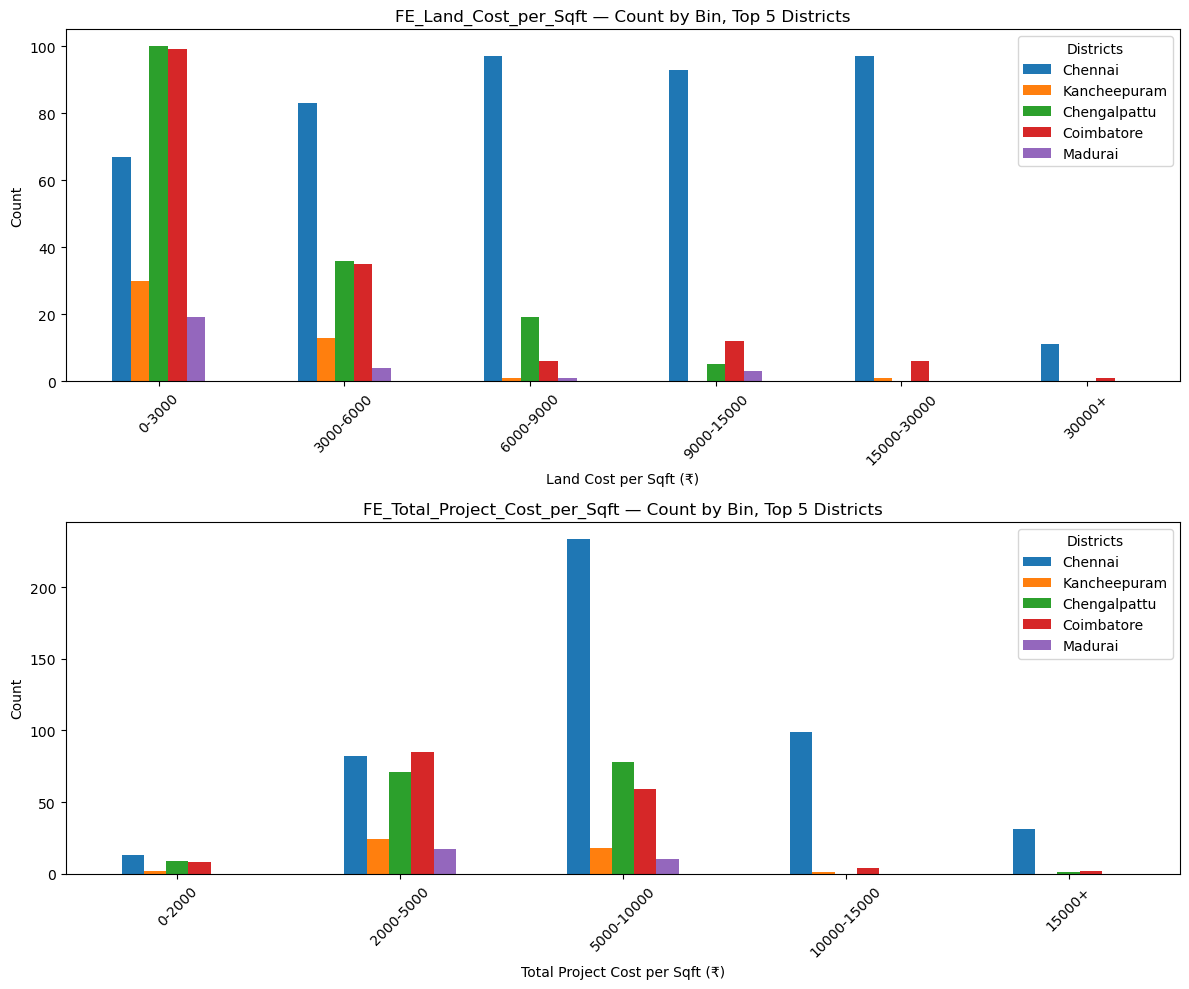

Districts    Chennai  Kancheepuram  Chengalpattu  Coimbatore  Madurai
Land_Bin                                                             
0-3000            67            30           100          99       19
3000-6000         83            13            36          35        4
6000-9000         97             1            19           6        1
9000-15000        93             0             5          12        3
15000-30000       97             1             0           6        0
30000+            11             0             0           1        0
Districts    Chennai  Kancheepuram  Chengalpattu  Coimbatore  Madurai
Cost_Bin                                                             
0-2000            13             2             9           8        0
2000-5000         82            24            71          85       17
5000-10000       234            18            78          59       10
10000-15000       99             1             0           4        0
15000+            31

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Fixed district order ---
top5_districts = ['Chennai', 'Kancheepuram', 'Chengalpattu', 'Coimbatore', 'Madurai']
df_top5 = df[df['Districts'].isin(top5_districts)].copy()

# --- Bin edges ---
bins_land = [0, 3000, 6000, 9000, 15000, 30000, float('inf')]
labels_land = ['0-3000', '3000-6000', '6000-9000', '9000-15000', '15000-30000', '30000+']

bins_cost = [0, 2000, 5000, 10000, 15000, float('inf')]
labels_cost = ['0-2000', '2000-5000', '5000-10000', '10000-15000', '15000+']

df_top5['Land_Bin'] = pd.cut(df_top5['FE_Land_Cost_per_Sqft'], bins=bins_land, labels=labels_land)
df_top5['Cost_Bin'] = pd.cut(df_top5['FE_Total_Project_Cost_per_Sqft'], bins=bins_cost, labels=labels_cost)

# --- Crosstab: bins x district, counts ---
land_ct = pd.crosstab(df_top5['Land_Bin'], df_top5['Districts']).reindex(index=labels_land, columns=top5_districts)
cost_ct = pd.crosstab(df_top5['Cost_Bin'], df_top5['Districts']).reindex(index=labels_cost, columns=top5_districts)

# --- Plot: grouped bar charts ---
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

land_ct.plot(kind='bar', ax=axes[0])
axes[0].set_title('FE_Land_Cost_per_Sqft — Count by Bin, Top 5 Districts')
axes[0].set_xlabel('Land Cost per Sqft (₹)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Districts')

cost_ct.plot(kind='bar', ax=axes[1])
axes[1].set_title('FE_Total_Project_Cost_per_Sqft — Count by Bin, Top 5 Districts')
axes[1].set_xlabel('Total Project Cost per Sqft (₹)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Districts')

plt.tight_layout()
plt.show()

print(land_ct)
print(cost_ct)

## Geo Analysis - Fix Corrupted Coordinates

In [76]:
df.head(5)

,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m,FE_Site_Extent_Sqft,FE_Total_FSI_Area_Sqft,FE_FSI,FE_Permissable_FSI,FE_Max_Premium_FSI,FE_Total_Parking,FE_Land_Cost_per_Sqft,FE_Construction_Cost_per_Sqft,FE_Total_Project_Cost_per_Sqft,FE_Land_Cost_Ratio,FE_Construction_Cost_Ratio,FE_Cost_Per_Dwelling_Unit,FE_Average_Unit_Size_Sqft,Is_TNUHDB_TNHB,Is_Dwelling_Units_Hardcoded,Is_FSI_Imputed_From_Comparable_Avg
0,CRT Magilagam,TN/10/Building/0519/2024,"Ward-E,Block-21,TS No.2/3,Periyar Nagar,Erode ...",Erode,11.34,77.73,Residential,Non-High Rise Building (NHRB),1149,0,3150,<NA>,30,24731214,111271043,16491620,152493877,22,6,3,[],[],12370,33906,2.74,2.00,2.00,31,1999,3282,4498,0.16,0.73,5083129,1130,False,False,False
1,Mayflower East Gate,TN/11/Building/0301/2024,"Old S.F.No.418/2pt,New T.S.No.5/1,Block.07,War...",Coimbatore,11.22,77.11,Residential,High Rise Building (HRB),2230,<NA>,6260,<NA>,42,80000000,230000000,15982769,325982769,27,15,42,[],[],24003,67383,2.81,2.00,4.87,84,3333,3413,4838,0.25,0.71,7761494,1604,False,False,False
2,CASAGRAND ALPINE,TN/11/Building/0331/2024,proposed construction of Residential Group Dev...,Coimbatore,110616.10,765959.10,Residential,Non-High Rise Building (NHRB),5673,<NA>,11986,599,144,12212576,203202738,23029644,238444958,97,2,2,"[{'block': None, 'base_level': 'Stilt', 'floor...",[],61063,135467,2.22,2.00,2.00,101,200,1500,1760,0.05,0.85,1655868,896,False,False,False
3,TIARA,TN/11/Building/0341/2024,"S.F.NO:370/3,CHINNAVEDAMPATTI,COIM BATORE-641049",Coimbatore,110530.70,765828.10,Residential,Non-High Rise Building (NHRB),1133,<NA>,2914,<NA>,22,3659100,30000000,2917400,36576500,24,0,2,[],[],12195,31362,2.57,2.00,2.00,26,300,957,1166,0.10,0.82,1662568,1426,False,False,False
4,PNR MODERNA,TN/11/Building/0344/2024,"SF NO 129/4B, RANI GARDEN, 3RD STREET,SINGANAL...",Coimbatore,11.01,77.04,Residential,Non-High Rise Building (NHRB),720,<NA>,1818,<NA>,14,26016000,43747218,11130881,80894099,16,0,0,[],[],7750,19572,2.53,2.00,2.00,16,3357,2235,4133,0.32,0.54,5778150,1398,False,False,False


In [77]:


# ---------------------------------------------------------------------------
# FIX CORRUPTED COORDINATES (in place) + FLAG THEM
#    ~150 rows have a decimal point dropped/shifted during extraction
#    (e.g. Latitude = 110616.10 instead of 11.061610). Repeatedly dividing
#    by 10 until the value lands in a plausible lat/lon range recovers most.
#    Unrecoverable rows are left as NaN rather than guessed.
# ---------------------------------------------------------------------------
def rescale_coord(val, lo, hi, max_tries=7):
    if pd.isna(val) or val == 0:
        return np.nan
    v = abs(val)
    for _ in range(max_tries):
        if lo <= v <= hi:
            return v if val > 0 else -v
        v /= 10
    return np.nan  # not recoverable

# flag BEFORE overwriting — this is your permanent record of which rows were touched
df['Coord_Was_Corrupted'] = ((df['Latitude'] > 90) | (df['Longitude'] > 180)).astype(int)
corrupted_mask = df['Coord_Was_Corrupted'] == 1

# overwrite Latitude/Longitude in place, only for corrupted rows
df.loc[corrupted_mask, 'Latitude'] = df.loc[corrupted_mask, 'Latitude'].apply(lambda v: rescale_coord(v, 8, 14))
df.loc[corrupted_mask, 'Longitude'] = df.loc[corrupted_mask, 'Longitude'].apply(lambda v: rescale_coord(v, 76, 81))

n_broken = corrupted_mask.sum()
n_unrecoverable = df.loc[corrupted_mask, ['Latitude', 'Longitude']].isna().any(axis=1).sum()
n_recovered = n_broken - n_unrecoverable
print(f"Corrupted coordinate rows: {n_broken} | Recovered via rescale: {n_recovered} | "
      f"Unrecoverable: {n_unrecoverable}")

# view the unrecoverable rows
unrecoverable = df[corrupted_mask & (df['Latitude'].isna() | df['Longitude'].isna())]
print(f"Unrecoverable coordinate rows: {len(unrecoverable)}")
display(unrecoverable[['Project_Name', 'Project_Registration_No', 'Districts', 'Latitude', 'Longitude']])

Corrupted coordinate rows: 151 | Recovered via rescale: 136 | Unrecoverable: 15
Unrecoverable coordinate rows: 15


,Project_Name,Project_Registration_No,Districts,Latitude,Longitude
72,CASAGRAND MASSIMO https://rera.tn.gov.in/publi...,TN/1/Building/0362/2024,Kancheepuram,8.06,NaN
80,JOHITHA'S VILLE,TN/1/Building/0499/2024,Kancheepuram,NaN,80.09
164,construction of 192 tenements (S+6) R.S.No 483...,TN/29/Building/0433/2024,Chennai,NaN,NaN
176,KCEE NIVEDITHAM,TN/29/Building/0457/2024,Chennai,13.02,NaN
205,Sreshta Sree Ganesh,TN/29/Building/0524/2024,Chennai,13.04,NaN
253,Hansa Pooram,TN/2/Building/0410/2024,Tiruvallur,NaN,79.55
268,CASAGRAND FRENCH TOWN https://rera.tn.gov.in/p...,TN/35/Building/0337/2024,Chengalpattu,8.01,NaN
270,CASAGRAND SELENIA,TN/35/Building/0345/2024,Chengalpattu,8.01,NaN
272,CASAGRAND SELENIA II,TN/35/Building/0369/2024,Chengalpattu,8.01,NaN
310,NAAVAL PARADISE,TN/7/Building/0505/2024,Salem,11.71,NaN


Sourced from the web. hardcode these onto the df dataframe

TN/1/Building/0362/2024	 -  Latitude: 13.005° NLongitude: 80.105° E

TN/1/Building/0499/2024  -  Latitude: 13.0039° N Longitude: 80.1565° E 

TN/29/Building/0433/2024  -  Latitude: 13.0428° NLongitude: 80.2372° E

TN/29/Building/0457/2024  -  Latitude: 13.033° N   Longitude: 80.223° E

TN/29/Building/0524/2024  -  Latitude: 13.0354° N   Longitude: 80.2589° E

TN/2/Building/0410/2024	-   Latitude: 13.1367° NLongitude: 79.9078° E

TN/35/Building/0337/2024	-  Latitude: 12.8797° N Longitude: 80.1793° E

TN/35/Building/0345/2024	-  Latitude: 12.4656° N  Longitude: 80.1149° E 

TN/35/Building/0369/2024    -  Latitude: 12.4656° N  Longitude: 80.1149° E

TN/7/Building/0505/2024     - Latitude: 11.6917° N Longitude: 78.1825° E 

TNRERA/1/BLG/0286/2026  - Latitude: 13.0278° N   Longitude: 80.1130° E 

TNRERA/1/BLG/0287/2026   -  Latitude: 13.0278° N      Longitude: 80.1130° E

TNRERA/29/BLG/0161/2026 - Latitude: 13.0189° N   Longitude: 80.2227° E

TNRERA/29/BLG/0191/2026  - Latitude: 13.0748° N Longitude: 80.1917° E 

TNRERA/2/BLG/0220/2026   -  Latitude: 13.0475° N Longitude: 80.0211° E


In [78]:
# Manually sourced coordinates for the 15 rows with unrecoverable corrupted coordinates
hardcoded_coordinates = {
    'TN/1/Building/0362/2024':  (13.0050, 80.1050),
    'TN/1/Building/0499/2024':  (13.0039, 80.1565),
    'TN/29/Building/0433/2024': (13.0428, 80.2372),
    'TN/29/Building/0457/2024': (13.0330, 80.2230),
    'TN/29/Building/0524/2024': (13.0354, 80.2589),
    'TN/2/Building/0410/2024':  (13.1367, 79.9078),
    'TN/35/Building/0337/2024': (12.8797, 80.1793),
    'TN/35/Building/0345/2024': (12.4656, 80.1149),
    'TN/35/Building/0369/2024': (12.4656, 80.1149),
    'TN/7/Building/0505/2024':  (11.6917, 78.1825),
    'TNRERA/1/BLG/0286/2026':   (13.0278, 80.1130),
    'TNRERA/1/BLG/0287/2026':   (13.0278, 80.1130),
    'TNRERA/29/BLG/0161/2026':  (13.0189, 80.2227),
    'TNRERA/29/BLG/0191/2026':  (13.0748, 80.1917),
    'TNRERA/2/BLG/0220/2026':   (13.0475, 80.0211),
}

df['Is_Coordinates_Hardcoded'] = df['Project_Registration_No'].isin(hardcoded_coordinates.keys())

matched = df['Is_Coordinates_Hardcoded'].sum()
print(f"Matched {matched} of {len(hardcoded_coordinates)} hardcoded registration numbers")

if matched < len(hardcoded_coordinates):
    missing = set(hardcoded_coordinates.keys()) - set(df.loc[df['Is_Coordinates_Hardcoded'], 'Project_Registration_No'])
    print("Missing/unmatched registration numbers:", missing)

lat_map = {k: v[0] for k, v in hardcoded_coordinates.items()}
lon_map = {k: v[1] for k, v in hardcoded_coordinates.items()}

# overwrite Latitude/Longitude IN PLACE — no new columns
df['Latitude']  = df['Latitude'].mask(df['Is_Coordinates_Hardcoded'], df['Project_Registration_No'].map(lat_map))
df['Longitude'] = df['Longitude'].mask(df['Is_Coordinates_Hardcoded'], df['Project_Registration_No'].map(lon_map))

display(df.loc[df['Is_Coordinates_Hardcoded'], ['Project_Name', 'Project_Registration_No', 'Districts', 'Latitude', 'Longitude']])

Matched 15 of 15 hardcoded registration numbers


,Project_Name,Project_Registration_No,Districts,Latitude,Longitude
72,CASAGRAND MASSIMO https://rera.tn.gov.in/publi...,TN/1/Building/0362/2024,Kancheepuram,13.01,80.11
80,JOHITHA'S VILLE,TN/1/Building/0499/2024,Kancheepuram,13.00,80.16
164,construction of 192 tenements (S+6) R.S.No 483...,TN/29/Building/0433/2024,Chennai,13.04,80.24
176,KCEE NIVEDITHAM,TN/29/Building/0457/2024,Chennai,13.03,80.22
205,Sreshta Sree Ganesh,TN/29/Building/0524/2024,Chennai,13.04,80.26
253,Hansa Pooram,TN/2/Building/0410/2024,Tiruvallur,13.14,79.91
268,CASAGRAND FRENCH TOWN https://rera.tn.gov.in/p...,TN/35/Building/0337/2024,Chengalpattu,12.88,80.18
270,CASAGRAND SELENIA,TN/35/Building/0345/2024,Chengalpattu,12.47,80.11
272,CASAGRAND SELENIA II,TN/35/Building/0369/2024,Chengalpattu,12.47,80.11
310,NAAVAL PARADISE,TN/7/Building/0505/2024,Salem,11.69,78.18


In [79]:
df[['Latitude', 'Longitude']].describe()

,Latitude,Longitude
count,1026.00,1026.00
mean,13.07,78.14
std,6.94,8.90
min,3.03,8.79
25%,11.11,78.14
50%,12.92,80.14
75%,13.04,80.22
max,80.84,86.25


## Geo COmparison of FSI Achieved , Land Cost per sqft , Construction cost per sqft , Total project cost per sqft


In [80]:
df.columns

Index(['Project_Name', 'Project_Registration_No', 'Project_Details',
       'Districts', 'Latitude', 'Longitude', 'Usage', 'Type_of_Building',
       'Site_Extent_Sqm', 'FSI_LIG_Residential', 'FSI_Other_Residential',
       'FSI_Commercial', 'Total_Dwelling_Units', 'Land_Cost',
       'Construction_Cost', 'Other_Cost', 'Total_Project_Cost',
       'Covered_Parking', 'Open_Parking', 'Visitor_Parking', 'Floor_mentions',
       'Heights_m', 'FE_Site_Extent_Sqft', 'FE_Total_FSI_Area_Sqft', 'FE_FSI',
       'FE_Permissable_FSI', 'FE_Max_Premium_FSI', 'FE_Total_Parking',
       'FE_Land_Cost_per_Sqft', 'FE_Construction_Cost_per_Sqft',
       'FE_Total_Project_Cost_per_Sqft', 'FE_Land_Cost_Ratio',
       'FE_Construction_Cost_Ratio', 'FE_Cost_Per_Dwelling_Unit',
       'FE_Average_Unit_Size_Sqft', 'Is_TNUHDB_TNHB',
       'Is_Dwelling_Units_Hardcoded', 'Is_FSI_Imputed_From_Comparable_Avg',
       'Coord_Was_Corrupted', 'Is_Coordinates_Hardcoded'],
      dtype='object')

Districts kept: ['Chennai', 'Chengalpattu', 'Coimbatore', 'Kancheepuram', 'Tiruchirappalli', 'Madurai', 'Tiruvallur', 'Salem']
Rows after district filter: 961 / 1026

17 of 37 District x Usage x Type groups have fewer than 5 projects — excluded from plots below, still in the table.


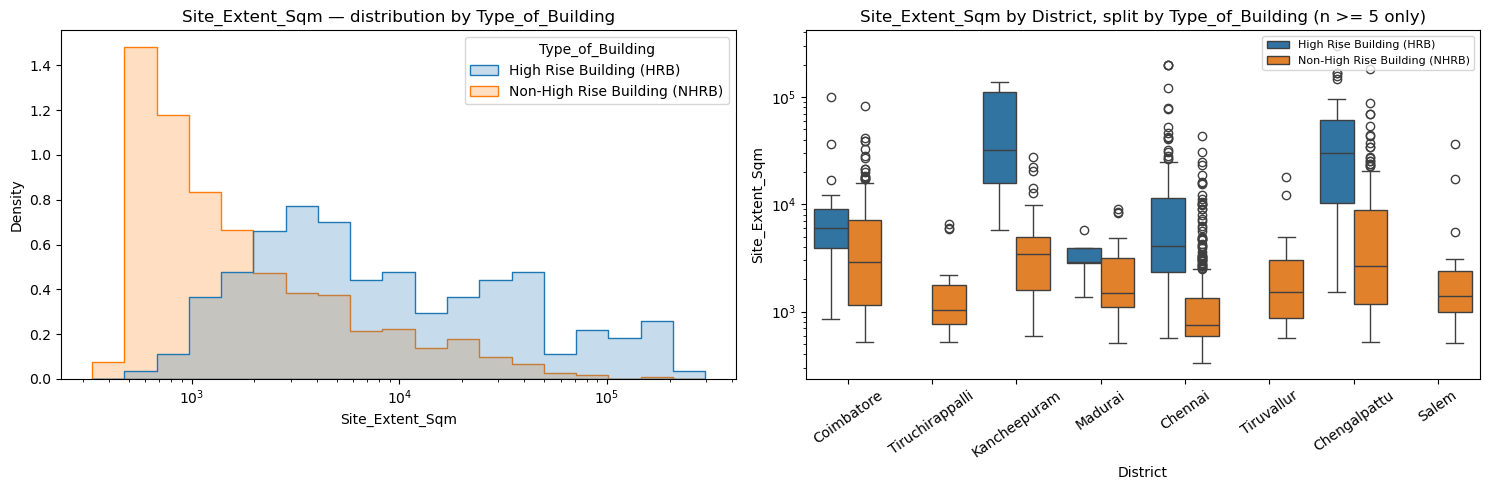

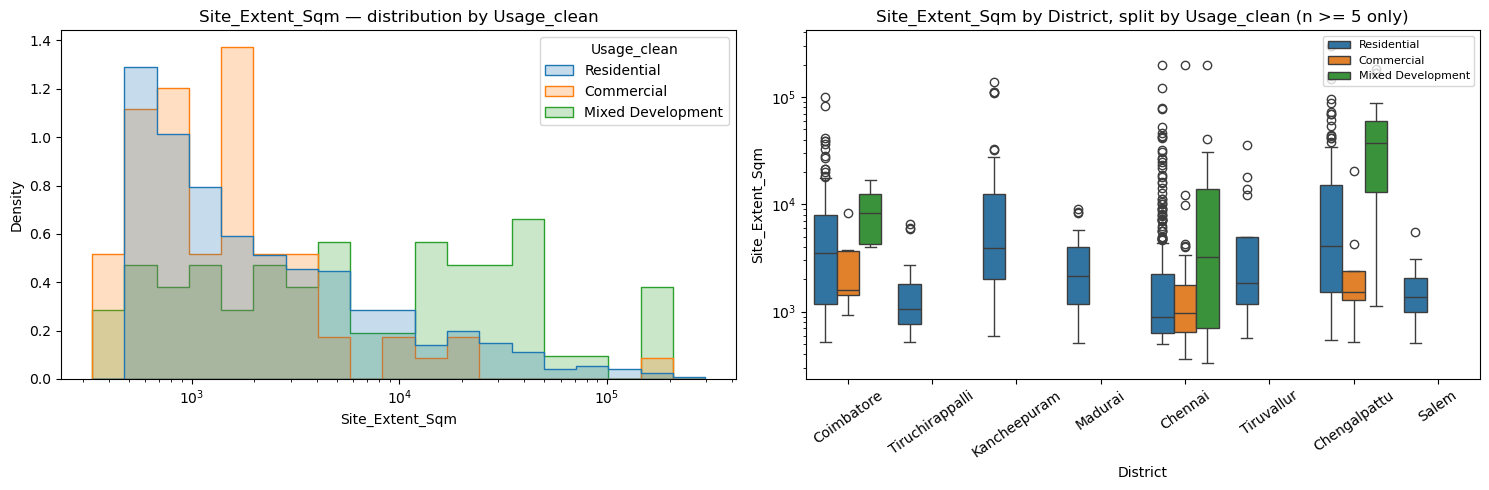

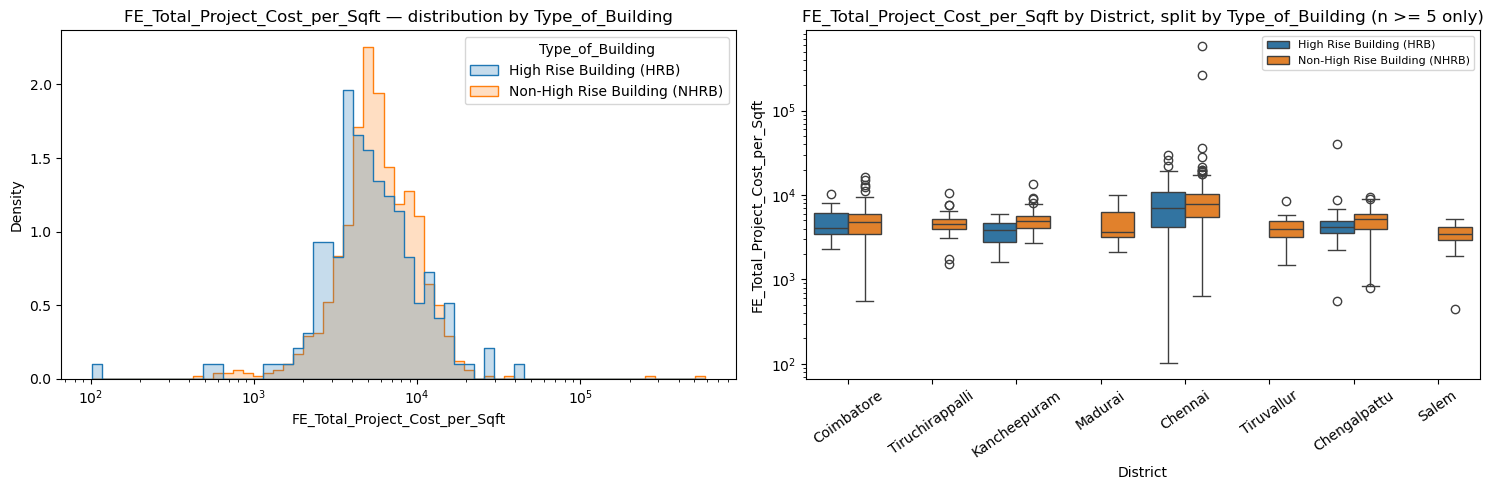

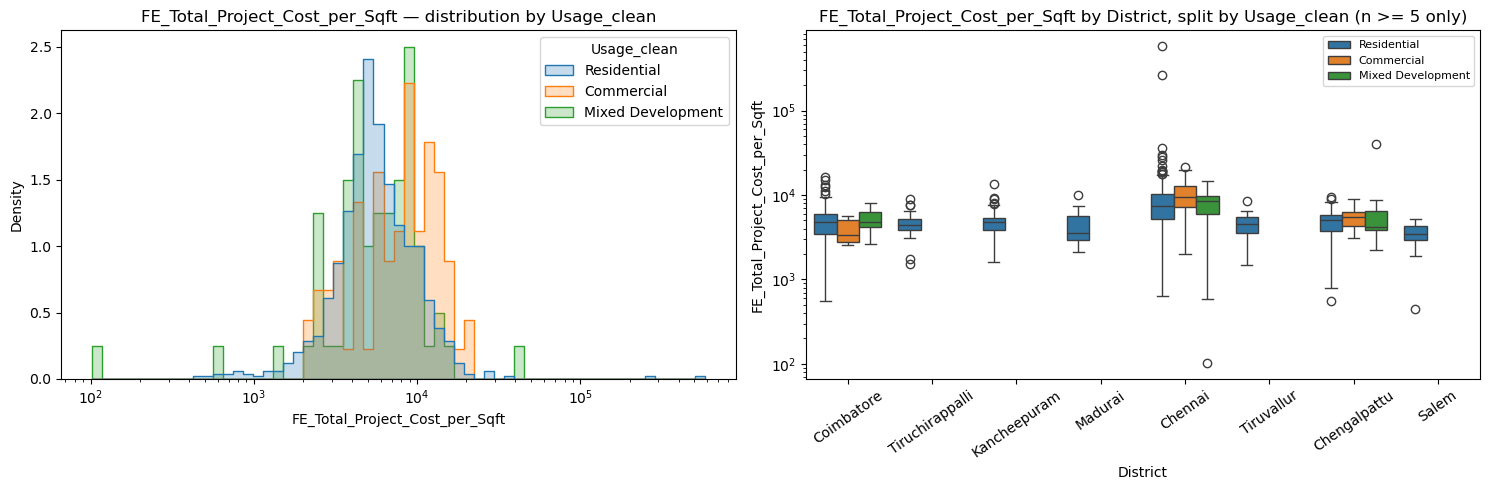

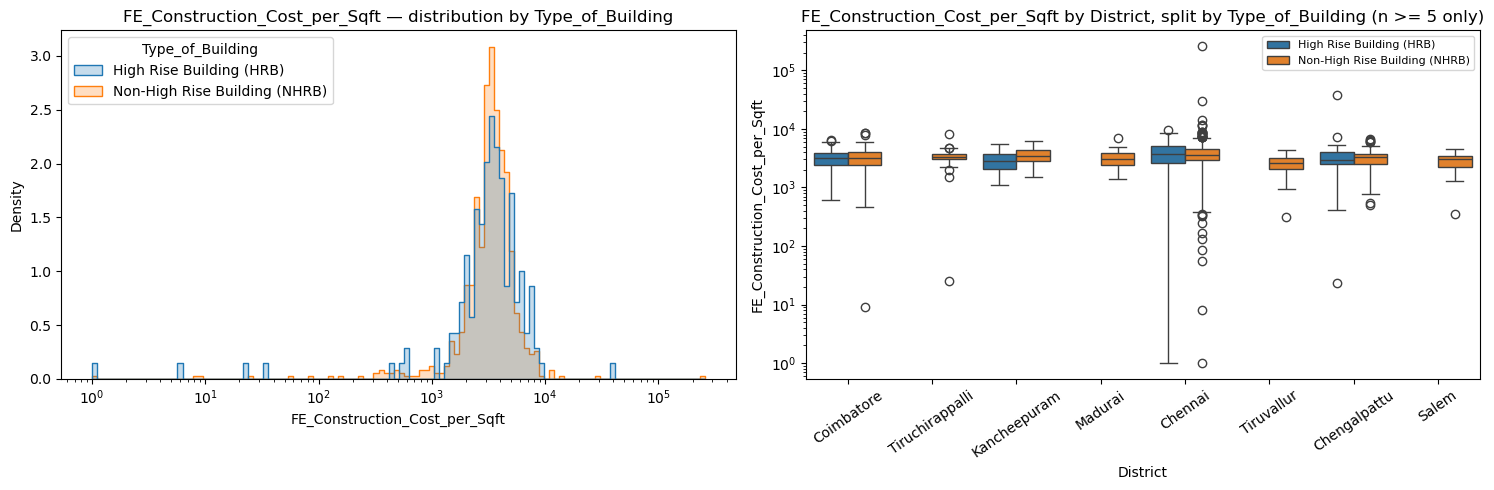

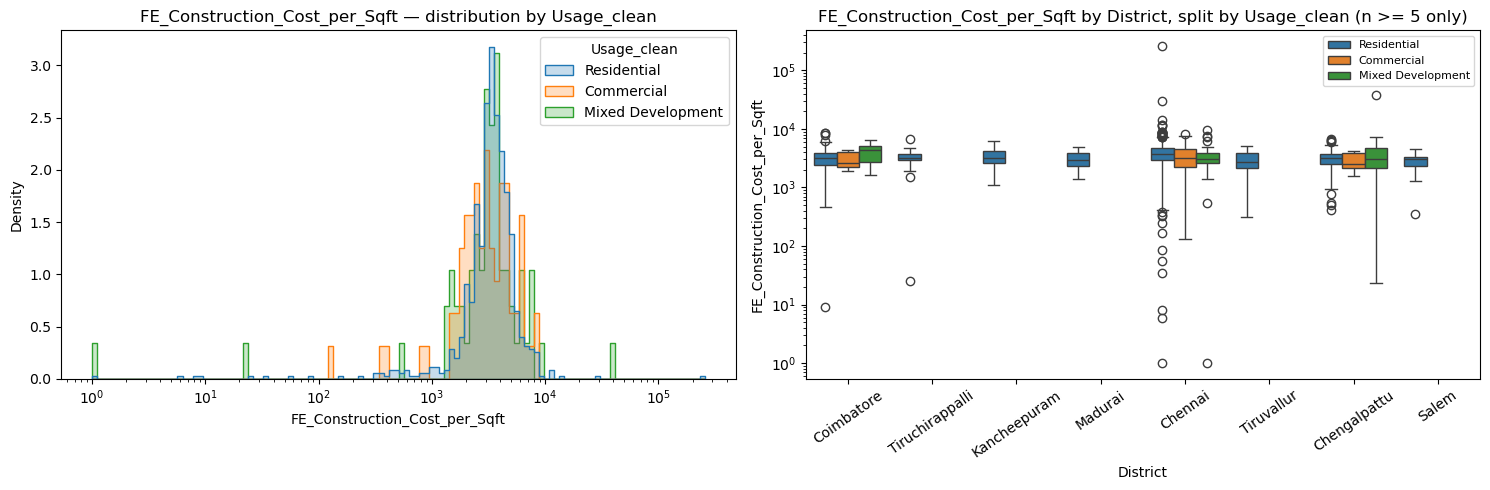

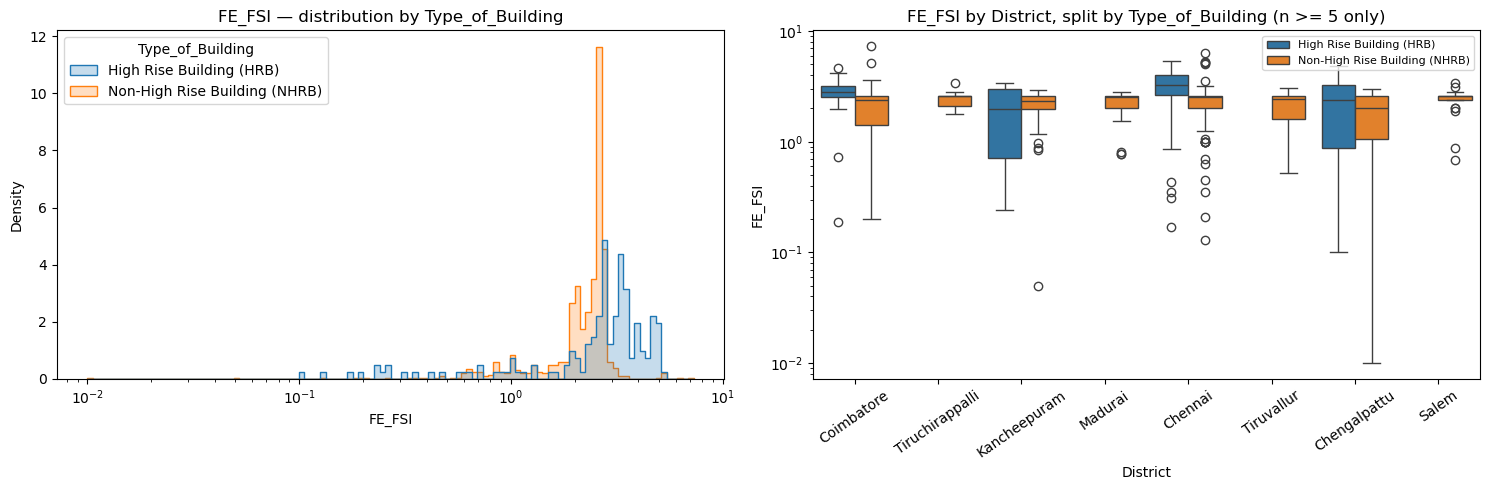

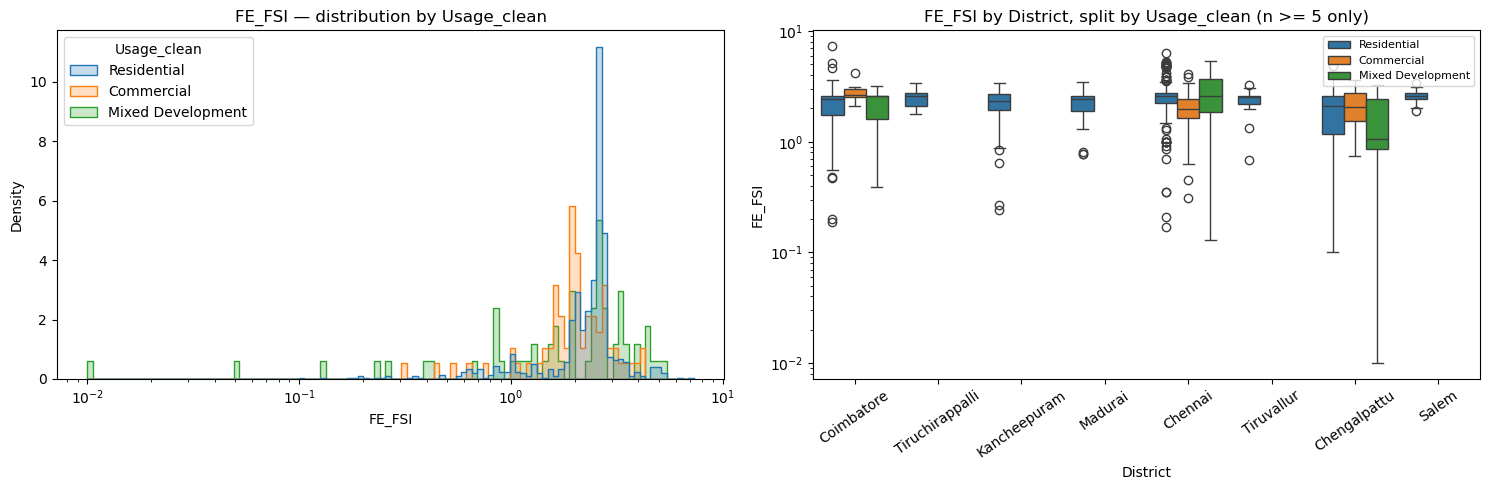

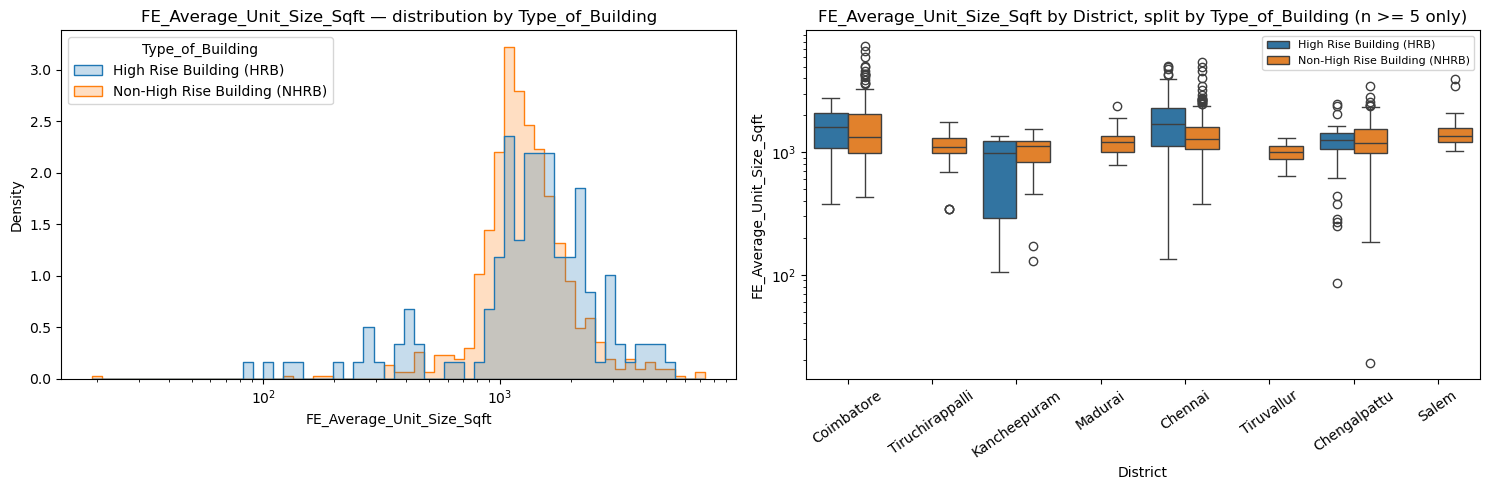

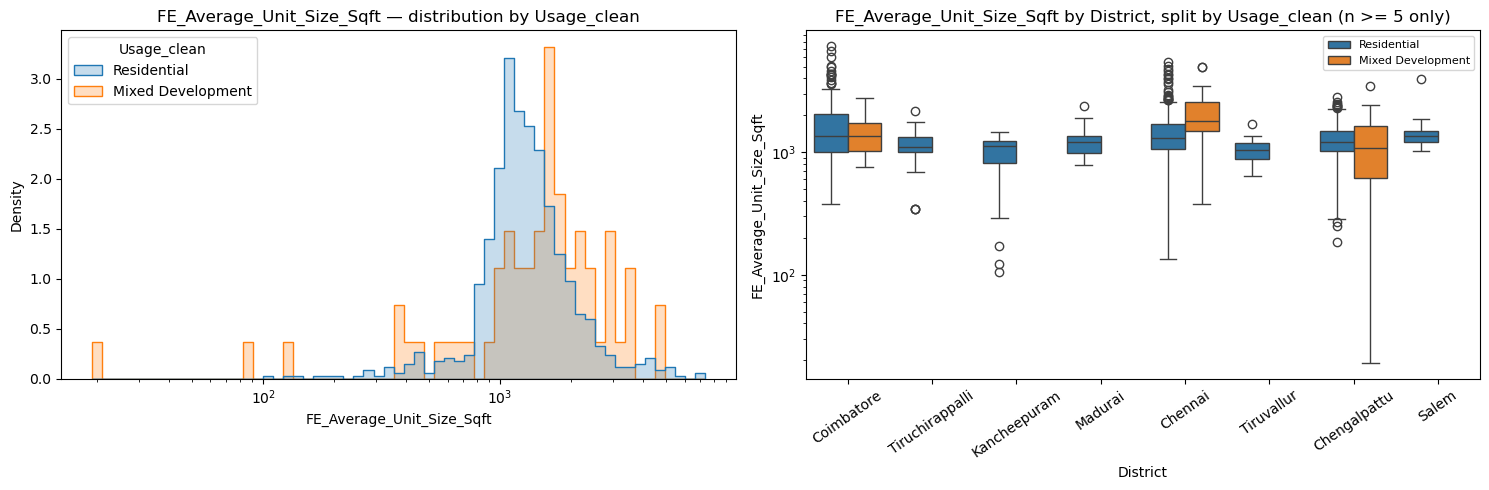

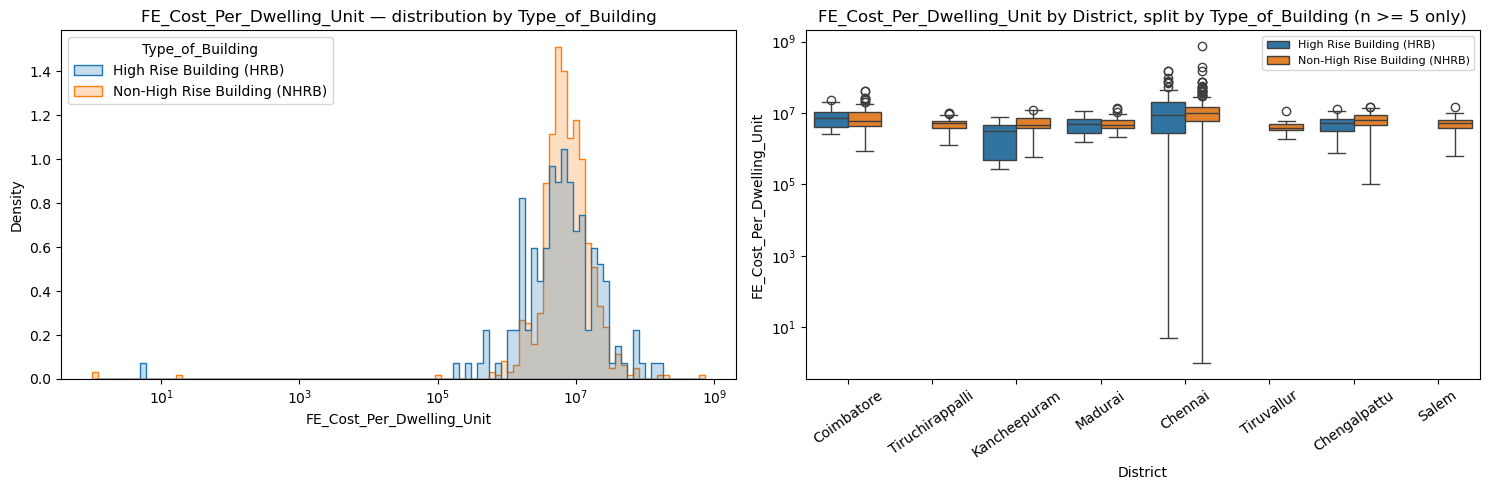

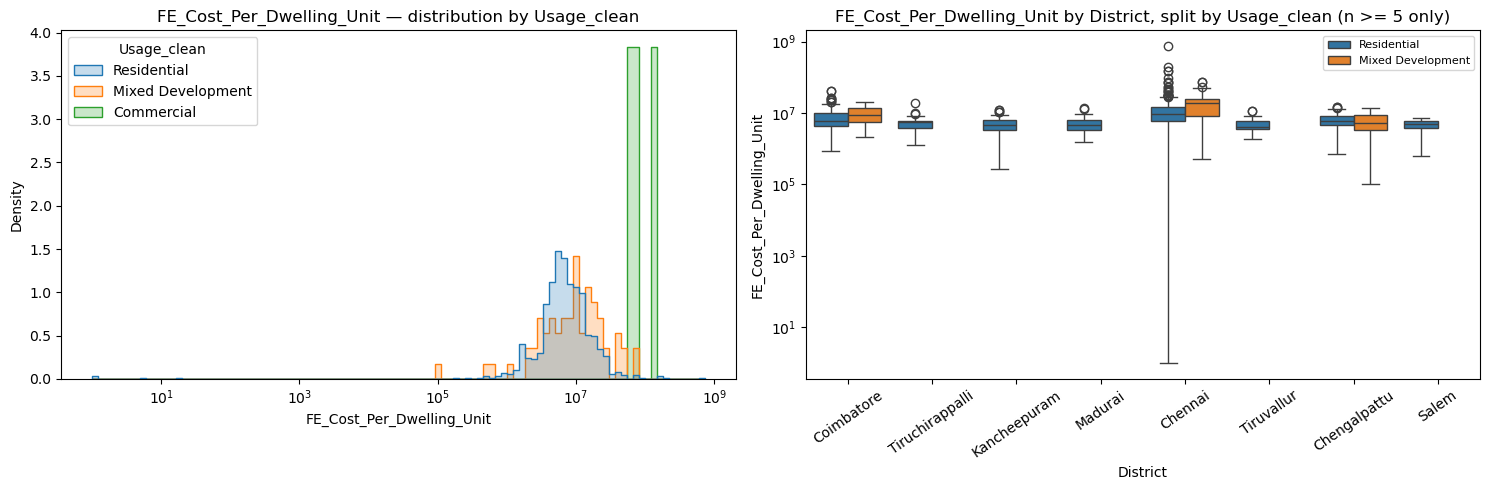

In [81]:
# ---------------------------------------------------------------------------
# CONFIG — adjust these to control granularity and readability
# ---------------------------------------------------------------------------
TOP_N_DISTRICTS = 8
MIN_GROUP_SIZE = 5
NUMERIC_COLS = [
    'Site_Extent_Sqm', 'FE_Total_Project_Cost_per_Sqft', 'FE_Construction_Cost_per_Sqft',
    'FE_FSI', 'FE_Average_Unit_Size_Sqft', 'FE_Cost_Per_Dwelling_Unit'
]

# Align column names used by this analysis with the dataframe schema
if 'District' not in df.columns:
    df['District'] = df['Districts'].astype('string').str.strip()

if 'Usage_clean' not in df.columns:
    df['Usage_clean'] = (
        df['Usage']
        .astype('string')
        .str.replace(r'\s*\d+/\d+\s*$', '', regex=True)
        .str.strip()
    )

if 'FSI_outlier_flag' not in df.columns:
    df['FSI_outlier_flag'] = df['FE_FSI'].gt(10).fillna(False)

top_districts = df['District'].value_counts().head(TOP_N_DISTRICTS).index
df_sub = df[df['District'].isin(top_districts)].copy()

df_sub_fsi_clean = df_sub[~df_sub['FSI_outlier_flag']]

print(f"Districts kept: {list(top_districts)}")
print(f"Rows after district filter: {len(df_sub)} / {len(df)}")

# ---------------------------------------------------------------------------
# 1. NUMERIC SUMMARY TABLE — District x Usage x Type_of_Building
# ---------------------------------------------------------------------------
GROUP_COLS = ['District', 'Usage_clean', 'Type_of_Building']

grouped_summary = (
    df_sub.groupby(GROUP_COLS)[NUMERIC_COLS]
    .agg(['count', 'median', 'mean', 'std', 'min', 'max'])
    .round(1)
)

group_sizes = df_sub.groupby(GROUP_COLS).size()
small_groups = group_sizes[group_sizes < MIN_GROUP_SIZE]
print(f"\n{len(small_groups)} of {len(group_sizes)} District x Usage x Type groups have "
      f"fewer than {MIN_GROUP_SIZE} projects — excluded from plots below, still in the table.")

# ---------------------------------------------------------------------------
# 2. HISTOGRAM + BOXPLOT SIDE BY SIDE, PER NUMERIC COLUMN
# ---------------------------------------------------------------------------
def plot_grouped(col, hue_col, data, min_size=MIN_GROUP_SIZE):
    plot_data = data[[col, 'District', hue_col]].dropna()
    plot_data = plot_data[plot_data[col] > 0]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.histplot(data=plot_data, x=col, hue=hue_col, log_scale=True,
                 element='step', stat='density', common_norm=False, ax=axes[0])
    axes[0].set_title(f'{col} — distribution by {hue_col}')

    sizes = plot_data.groupby(['District', hue_col]).size()
    valid_keys = sizes[sizes >= min_size].index
    box_data = plot_data[plot_data.set_index(['District', hue_col]).index.isin(valid_keys)]

    sns.boxplot(data=box_data, x='District', y=col, hue=hue_col, ax=axes[1])
    axes[1].set_yscale('log')
    axes[1].tick_params(axis='x', rotation=35)
    axes[1].set_title(f'{col} by District, split by {hue_col} (n >= {min_size} only)')
    axes[1].legend(loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.show()

for col in NUMERIC_COLS:
    source = df_sub_fsi_clean if col == 'FE_FSI' else df_sub
    plot_grouped(col, 'Type_of_Building', source)
    plot_grouped(col, 'Usage_clean', source)

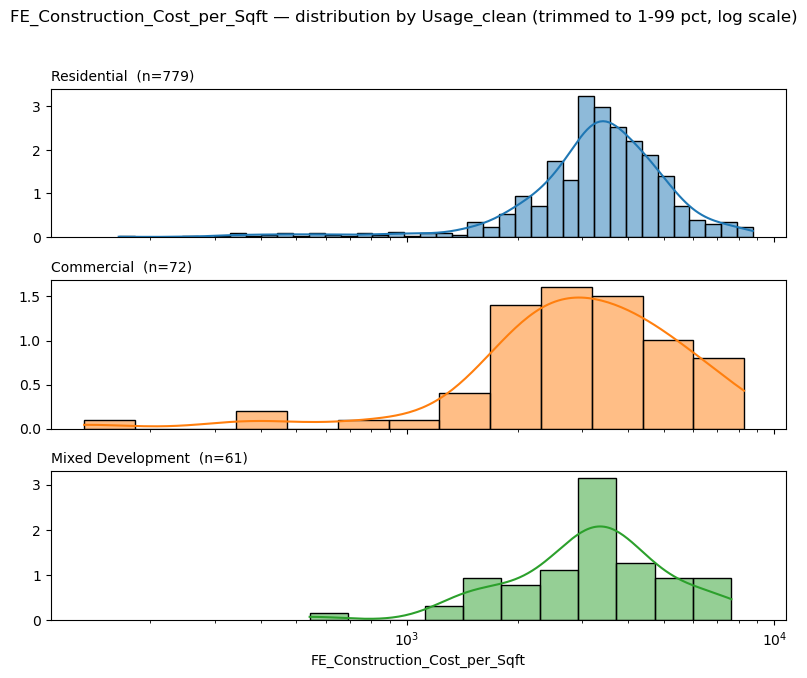

In [82]:
# ---------------------------------------------------------------------------
# ALTERNATIVE TO OVERLAPPING HISTOGRAM: small-multiples KDE, one row per category
#    Overlapping step histograms on a 5-decade log axis (driven by outliers like
#    Rs.1/sqft and Rs.300000/sqft) makes it impossible to compare shapes.
#    Splitting into stacked panels + trimming the view to the 1st-99th percentile
#    keeps the same data but makes the actual distribution shape visible.
# ---------------------------------------------------------------------------
def plot_small_multiples(col, hue_col, data, min_size=MIN_GROUP_SIZE, trim_pct=(1, 99)):
    plot_data = data[[col, hue_col]].dropna()
    plot_data = plot_data[plot_data[col] > 0]

    # trim extreme tails for THIS VIEW ONLY — doesn't touch df, just what's plotted
    lo, hi = np.percentile(plot_data[col], trim_pct)
    plot_data = plot_data[(plot_data[col] >= lo) & (plot_data[col] <= hi)]

    categories = plot_data[hue_col].value_counts()
    categories = categories[categories >= min_size].index

    fig, axes = plt.subplots(len(categories), 1, figsize=(8, 2.2 * len(categories)),
                              sharex=True)
    if len(categories) == 1:
        axes = [axes]

    colors = sns.color_palette('tab10', len(categories))

    for ax, cat, color in zip(axes, categories, colors):
        subset = plot_data[plot_data[hue_col] == cat][col]
        sns.histplot(subset, log_scale=True, kde=True, ax=ax, color=color, stat='density')
        ax.set_title(f'{cat}  (n={len(subset)})', loc='left', fontsize=10)
        ax.set_ylabel('')

    axes[-1].set_xlabel(col)
    fig.suptitle(f'{col} — distribution by {hue_col} (trimmed to {trim_pct[0]}-{trim_pct[1]} pct, log scale)',
                 y=1.02)
    plt.tight_layout()
    plt.show()

plot_small_multiples('FE_Construction_Cost_per_Sqft', 'Usage_clean', df_sub)

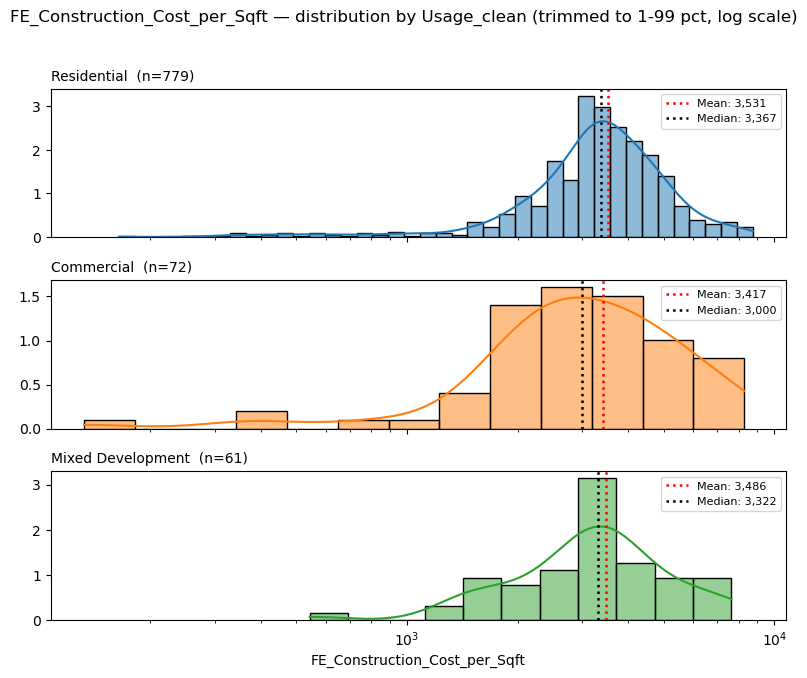

In [83]:
# ---------------------------------------------------------------------------
# SAME SMALL-MULTIPLES VIEW + MEAN/MEDIAN REFERENCE LINES PER PANEL
# ---------------------------------------------------------------------------
def plot_small_multiples(col, hue_col, data, min_size=MIN_GROUP_SIZE, trim_pct=(1, 99)):
    plot_data = data[[col, hue_col]].dropna()
    plot_data = plot_data[plot_data[col] > 0]

    lo, hi = np.percentile(plot_data[col], trim_pct)
    plot_data = plot_data[(plot_data[col] >= lo) & (plot_data[col] <= hi)]

    categories = plot_data[hue_col].value_counts()
    categories = categories[categories >= min_size].index

    fig, axes = plt.subplots(len(categories), 1, figsize=(8, 2.2 * len(categories)),
                              sharex=True)
    if len(categories) == 1:
        axes = [axes]

    colors = sns.color_palette('tab10', len(categories))

    for ax, cat, color in zip(axes, categories, colors):
        subset = plot_data[plot_data[hue_col] == cat][col]
        sns.histplot(subset, log_scale=True, kde=True, ax=ax, color=color, stat='density')

        # mean/median computed on the SAME trimmed subset shown in the panel —
        # keeps the lines visually consistent with what's actually plotted
        mean_val = subset.mean()
        median_val = subset.median()

        ax.axvline(mean_val, color='red', linestyle=':', linewidth=1.8,
                   label=f'Mean: {mean_val:,.0f}')
        ax.axvline(median_val, color='black', linestyle=':', linewidth=1.8,
                   label=f'Median: {median_val:,.0f}')

        ax.set_title(f'{cat}  (n={len(subset)})', loc='left', fontsize=10)
        ax.set_ylabel('')
        ax.legend(fontsize=8, loc='upper right')

    axes[-1].set_xlabel(col)
    fig.suptitle(f'{col} — distribution by {hue_col} (trimmed to {trim_pct[0]}-{trim_pct[1]} pct, log scale)',
                 y=1.02)
    plt.tight_layout()
    plt.show()

plot_small_multiples('FE_Construction_Cost_per_Sqft', 'Usage_clean', df_sub)

Districts kept: ['Chennai', 'Chengalpattu', 'Coimbatore', 'Kancheepuram', 'Tiruchirappalli', 'Madurai', 'Tiruvallur', 'Salem']
Rows after district filter: 961 / 1026

17 of 37 District x Usage x Type groups have fewer than 5 projects — excluded from plots below, still in the table.


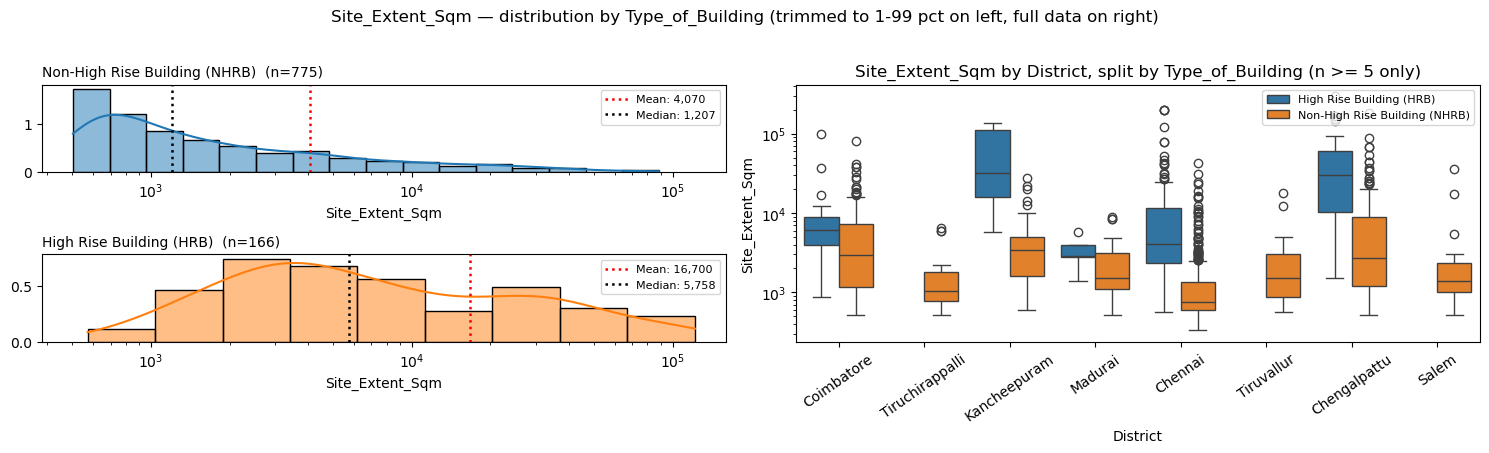

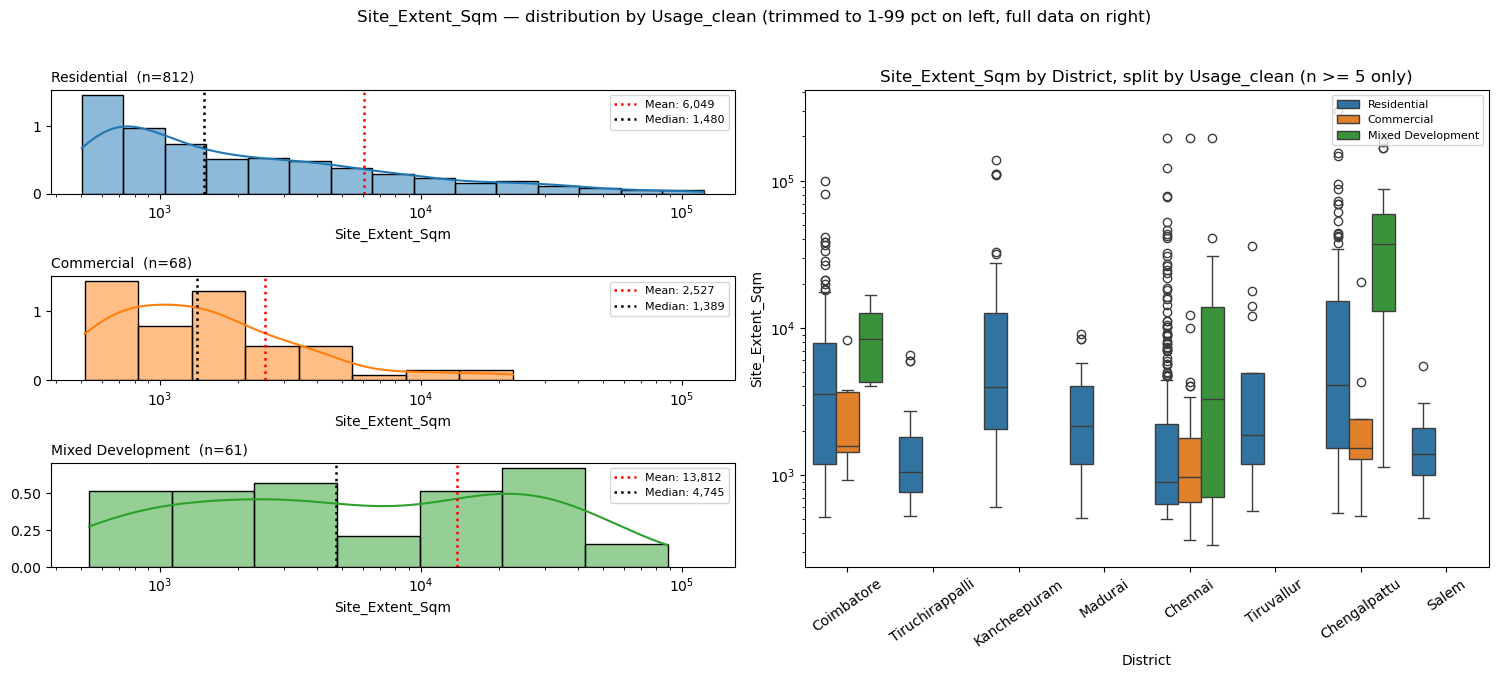

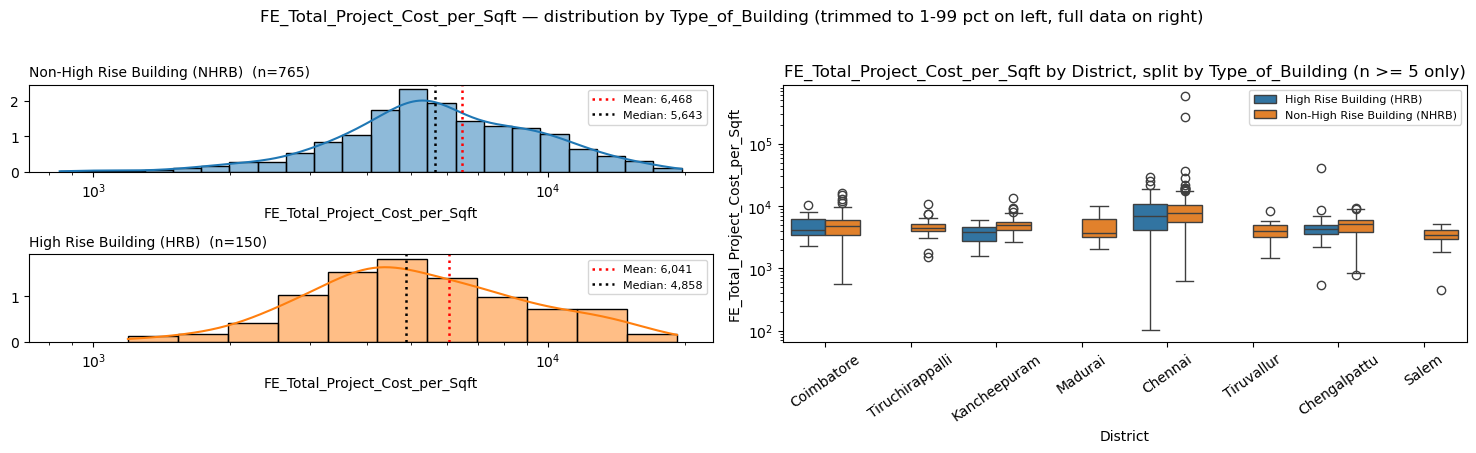

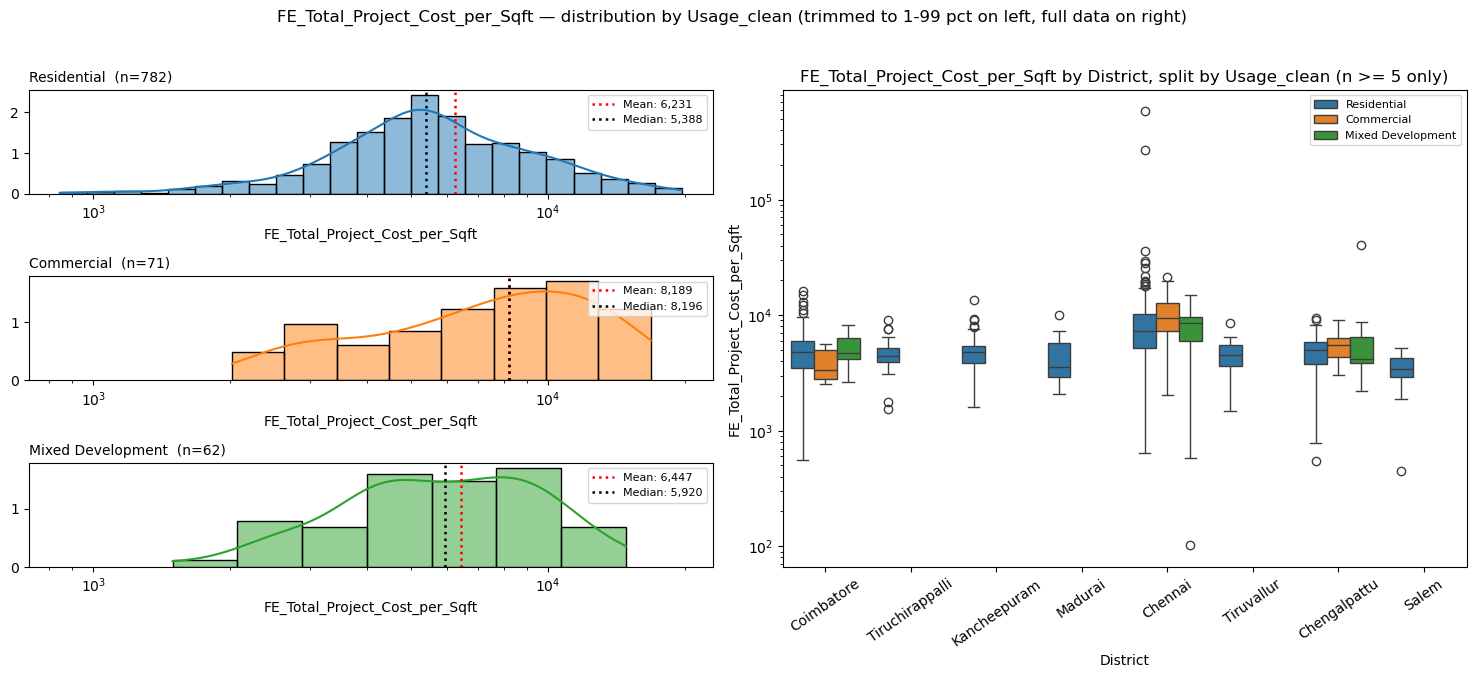

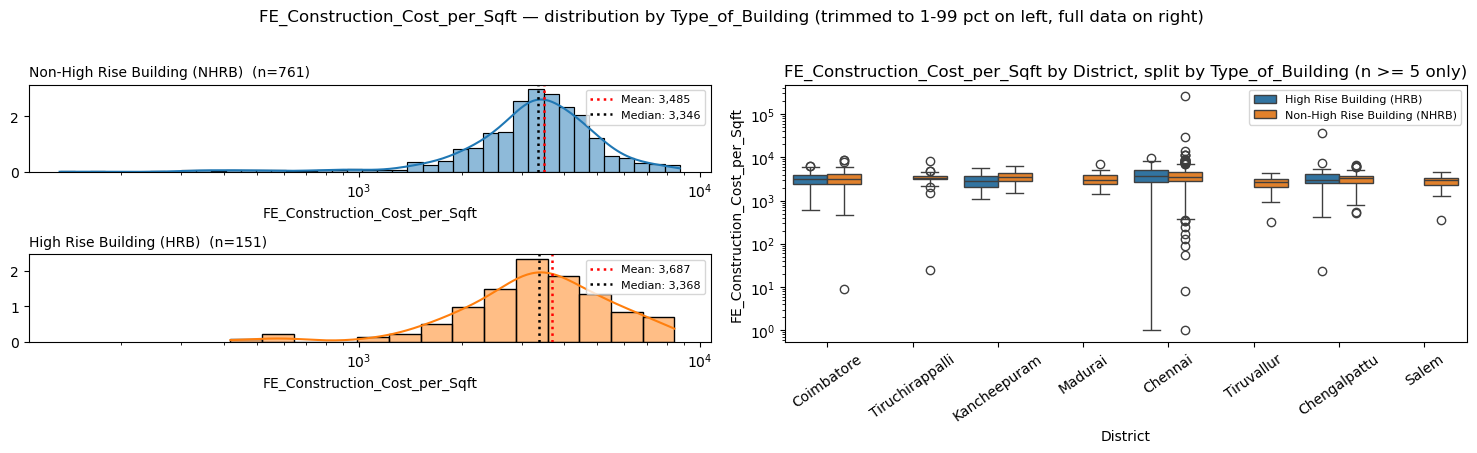

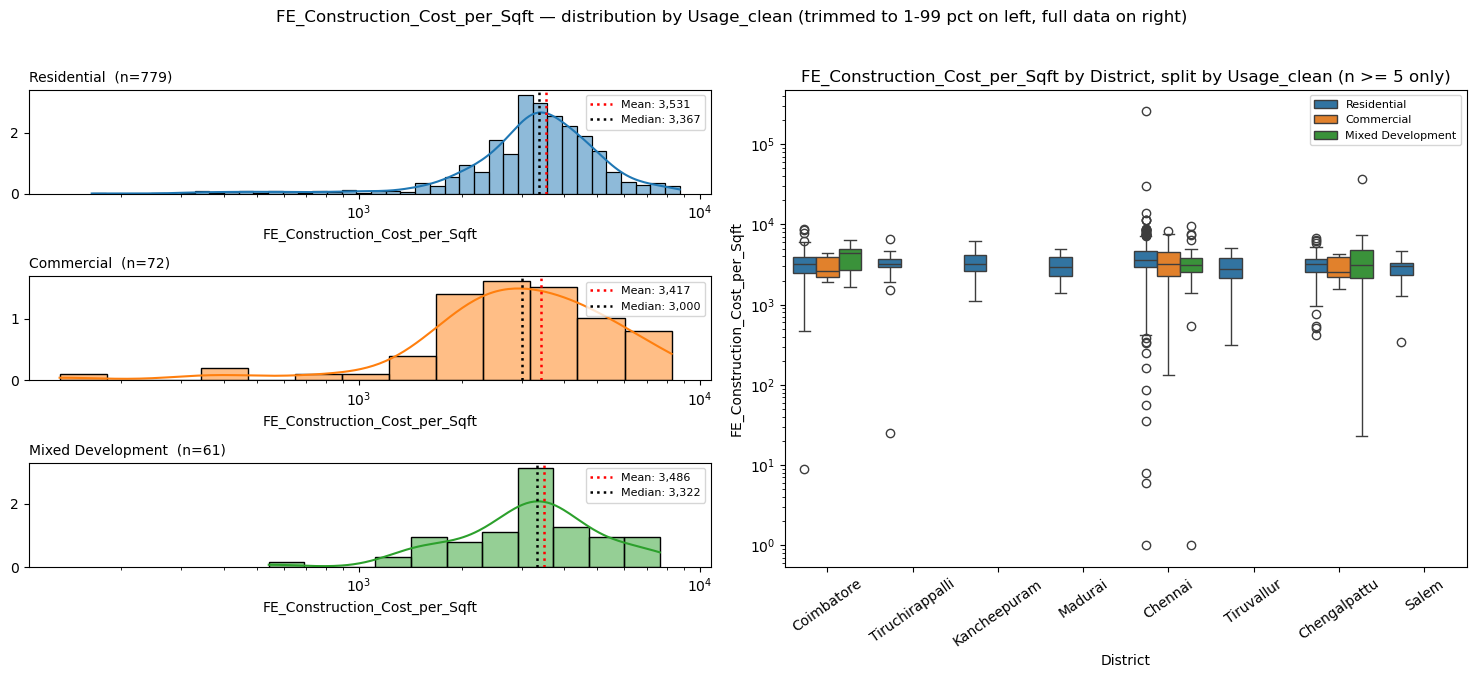

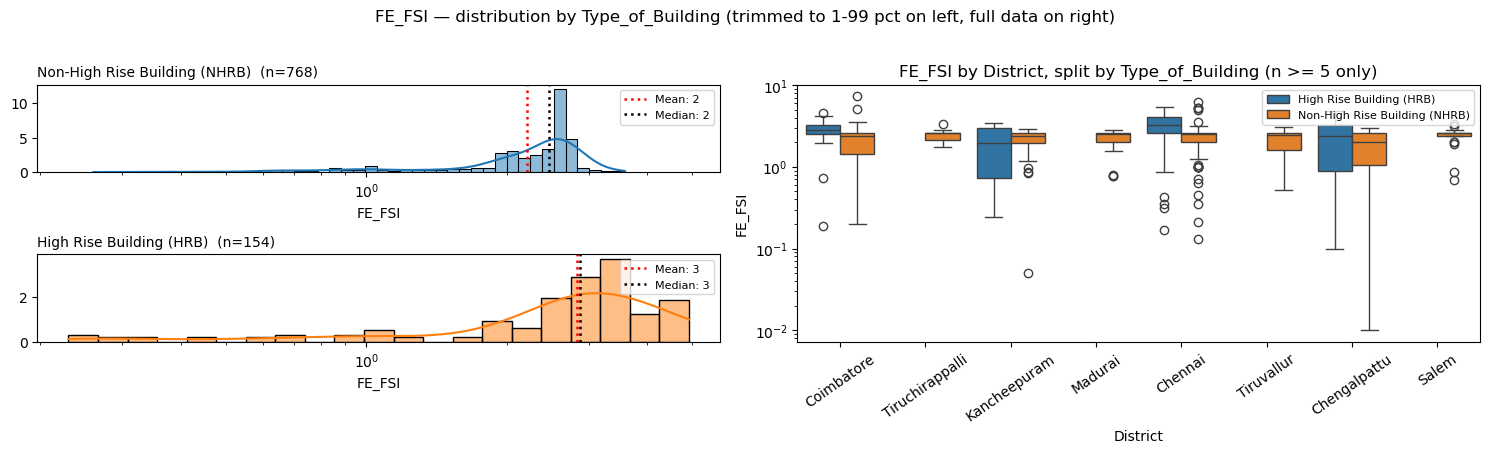

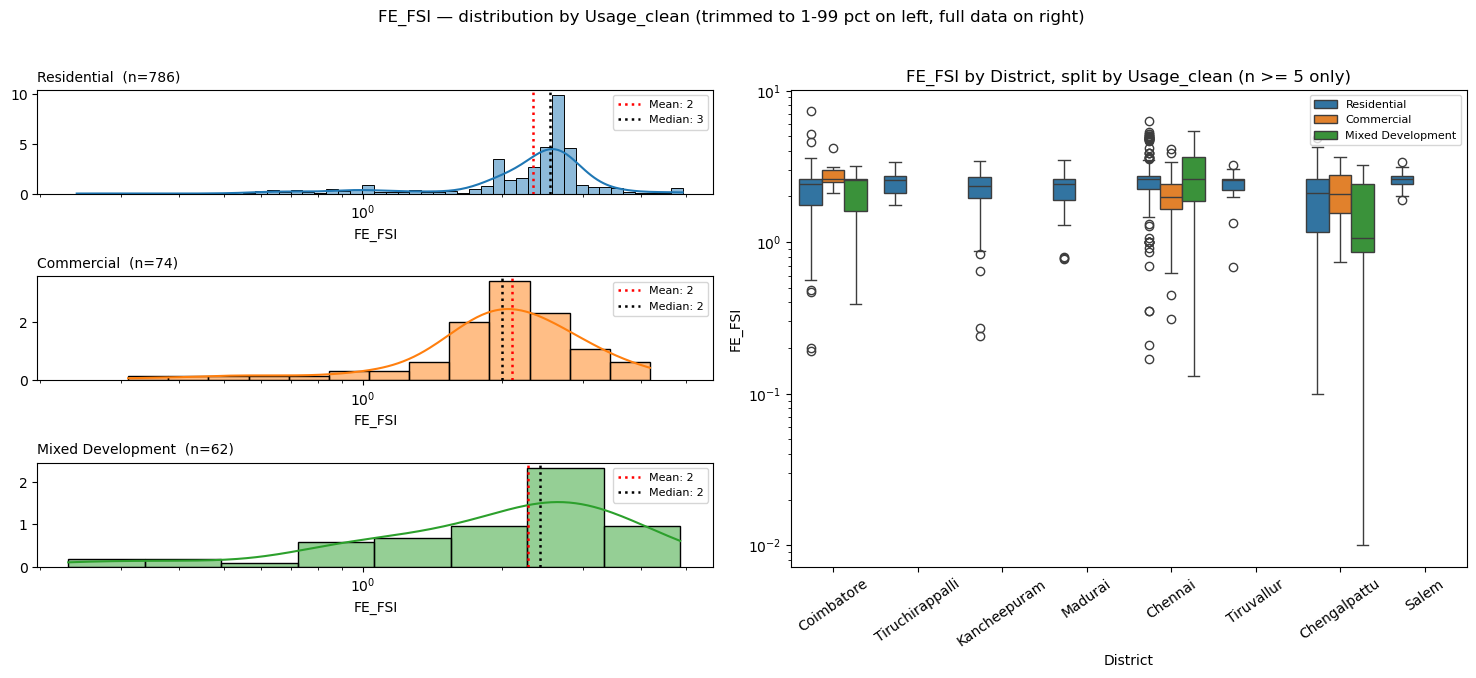

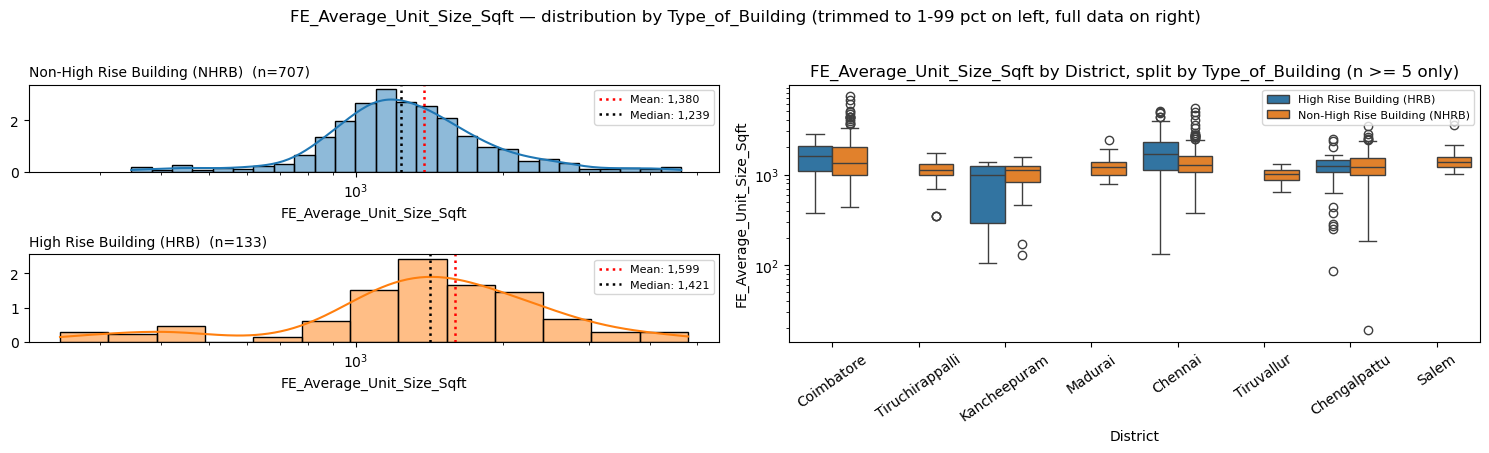

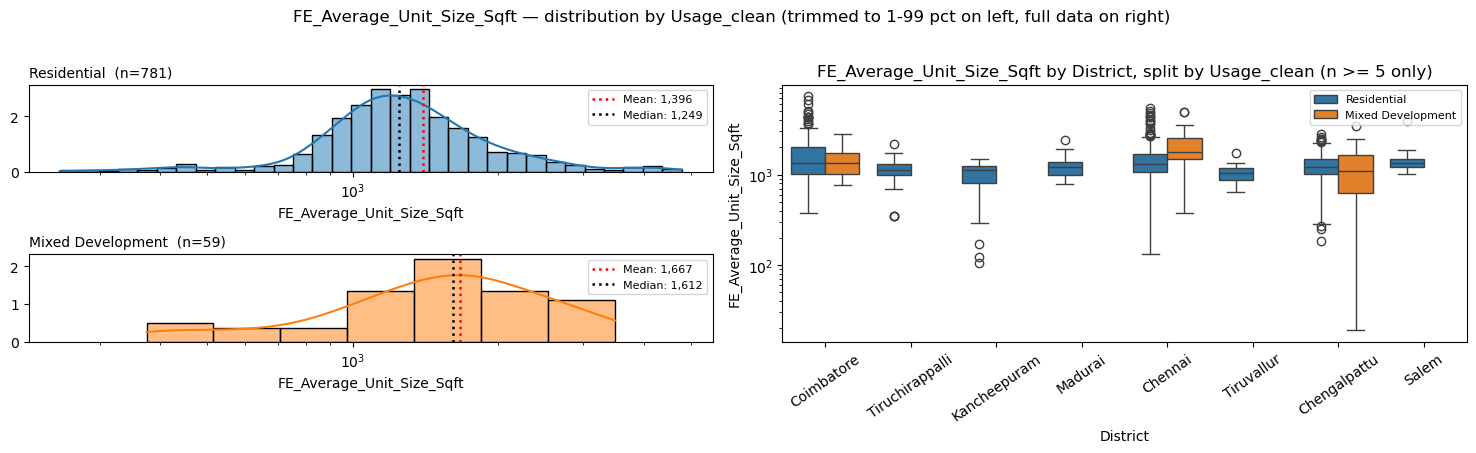

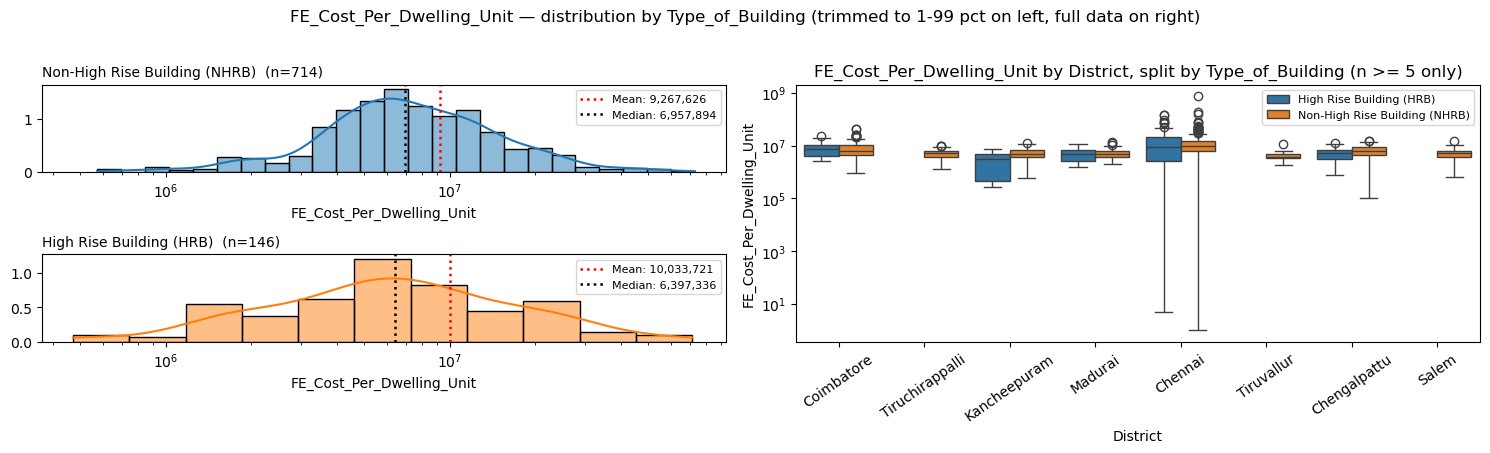

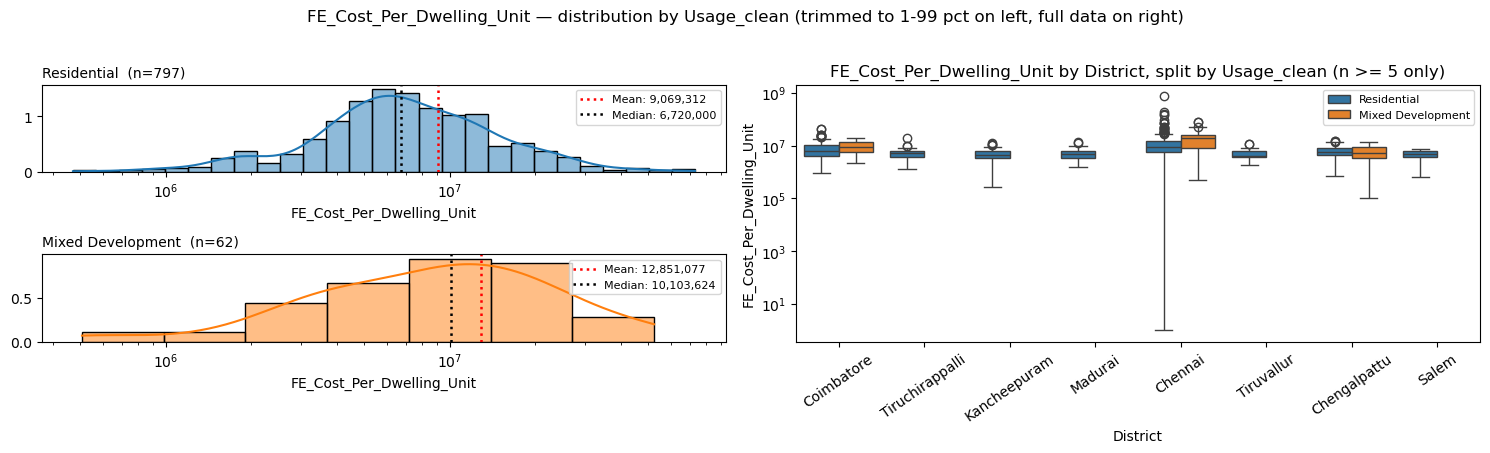

In [84]:
# ---------------------------------------------------------------------------
# CONFIG — adjust these to control granularity and readability
# ---------------------------------------------------------------------------
TOP_N_DISTRICTS = 8
MIN_GROUP_SIZE = 5
TRIM_PCT = (1, 99)  # view-only trim to keep extreme outliers from stretching the x-axis
NUMERIC_COLS = [
    'Site_Extent_Sqm', 'FE_Total_Project_Cost_per_Sqft', 'FE_Construction_Cost_per_Sqft',
    'FE_FSI', 'FE_Average_Unit_Size_Sqft', 'FE_Cost_Per_Dwelling_Unit'
]

# Align column names used by this analysis with the dataframe schema
if 'District' not in df.columns:
    df['District'] = df['Districts'].astype('string').str.strip()

if 'Usage_clean' not in df.columns:
    df['Usage_clean'] = (
        df['Usage']
        .astype('string')
        .str.replace(r'\s*\d+/\d+\s*$', '', regex=True)
        .str.strip()
    )

if 'FSI_outlier_flag' not in df.columns:
    df['FSI_outlier_flag'] = df['FE_FSI'].gt(10).fillna(False)

top_districts = df['District'].value_counts().head(TOP_N_DISTRICTS).index
df_sub = df[df['District'].isin(top_districts)].copy()

df_sub_fsi_clean = df_sub[~df_sub['FSI_outlier_flag']]

print(f"Districts kept: {list(top_districts)}")
print(f"Rows after district filter: {len(df_sub)} / {len(df)}")

# ---------------------------------------------------------------------------
# 1. NUMERIC SUMMARY TABLE — District x Usage x Type_of_Building
# ---------------------------------------------------------------------------
GROUP_COLS = ['District', 'Usage_clean', 'Type_of_Building']

grouped_summary = (
    df_sub.groupby(GROUP_COLS)[NUMERIC_COLS]
    .agg(['count', 'median', 'mean', 'std', 'min', 'max'])
    .round(1)
)

group_sizes = df_sub.groupby(GROUP_COLS).size()
small_groups = group_sizes[group_sizes < MIN_GROUP_SIZE]
print(f"\n{len(small_groups)} of {len(group_sizes)} District x Usage x Type groups have "
      f"fewer than {MIN_GROUP_SIZE} projects — excluded from plots below, still in the table.")

# ---------------------------------------------------------------------------
# 2. SMALL-MULTIPLES DISTRIBUTION PLOT, PER NUMERIC COLUMN
#    One stacked panel per category (Type_of_Building / Usage_clean), each with
#    its own histogram + KDE + mean/median reference lines. Replaces the old
#    overlapping-histogram + boxplot pair — overlap on a multi-decade log axis
#    made shapes impossible to compare, especially with extreme outliers present.
# ---------------------------------------------------------------------------
def plot_small_multiples(col, hue_col, data, min_size=MIN_GROUP_SIZE, trim_pct=TRIM_PCT):
    plot_data = data[[col, hue_col]].dropna()
    plot_data = plot_data[plot_data[col] > 0]

    lo, hi = np.percentile(plot_data[col], trim_pct)
    plot_data_trimmed = plot_data[(plot_data[col] >= lo) & (plot_data[col] <= hi)]

    categories = plot_data_trimmed[hue_col].value_counts()
    categories = categories[categories >= min_size].index

    if len(categories) == 0:
        print(f"Skipping {col} by {hue_col} — no category has >= {min_size} rows after trim.")
        return

    n_rows = len(categories)
    fig = plt.figure(figsize=(15, 2.2 * n_rows))
    gs = fig.add_gridspec(n_rows, 2, width_ratios=[1, 1])

    colors = sns.color_palette('tab10', n_rows)

    # LEFT COLUMN: small-multiples histogram + KDE + mean/median lines (unchanged)
    hist_axes = []
    for i, (cat, color) in enumerate(zip(categories, colors)):
        ax = fig.add_subplot(gs[i, 0], sharex=hist_axes[0] if hist_axes else None)
        hist_axes.append(ax)
        subset = plot_data_trimmed[plot_data_trimmed[hue_col] == cat][col]
        sns.histplot(subset, log_scale=True, kde=True, ax=ax, color=color, stat='density')

        mean_val = subset.mean()
        median_val = subset.median()
        ax.axvline(mean_val, color='red', linestyle=':', linewidth=1.8, label=f'Mean: {mean_val:,.0f}')
        ax.axvline(median_val, color='black', linestyle=':', linewidth=1.8, label=f'Median: {median_val:,.0f}')

        ax.set_title(f'{cat}  (n={len(subset)})', loc='left', fontsize=10)
        ax.set_ylabel('')
        ax.legend(fontsize=8, loc='upper right')

    hist_axes[-1].set_xlabel(col)

    # RIGHT: boxplot by District, split by hue_col — undersized District x hue groups dropped,
    # uses the FULL (non-trimmed) data since boxplots show outliers as points rather than
    # getting visually wrecked by them the way a histogram does
    ax_box = fig.add_subplot(gs[:, 1])
    box_data = data[[col, 'District', hue_col]].dropna()
    box_data = box_data[box_data[col] > 0]

    sizes = box_data.groupby(['District', hue_col]).size()
    valid_keys = sizes[sizes >= min_size].index
    box_data = box_data[box_data.set_index(['District', hue_col]).index.isin(valid_keys)]

    sns.boxplot(data=box_data, x='District', y=col, hue=hue_col, ax=ax_box)
    ax_box.set_yscale('log')
    ax_box.tick_params(axis='x', rotation=35)
    ax_box.set_title(f'{col} by District, split by {hue_col} (n >= {min_size} only)')
    ax_box.legend(loc='upper right', fontsize=8)

    fig.suptitle(f'{col} — distribution by {hue_col} (trimmed to {trim_pct[0]}-{trim_pct[1]} pct on left, full data on right)', y=1.02)
    plt.tight_layout()
    plt.show()

for col in NUMERIC_COLS:
    source = df_sub_fsi_clean if col == 'FE_FSI' else df_sub
    plot_small_multiples(col, 'Type_of_Building', source)
    plot_small_multiples(col, 'Usage_clean', source)

Rows with plausible coordinates (any district): 1026 / 1026
Rows within Chennai + suburban bounding box: 598 / 1026
Of those, District already tagged as Chennai/CMA: 598 / 598
Districts appearing inside the box: ['Chengalpattu', 'Chennai', 'Kancheepuram', 'Tiruvallur']


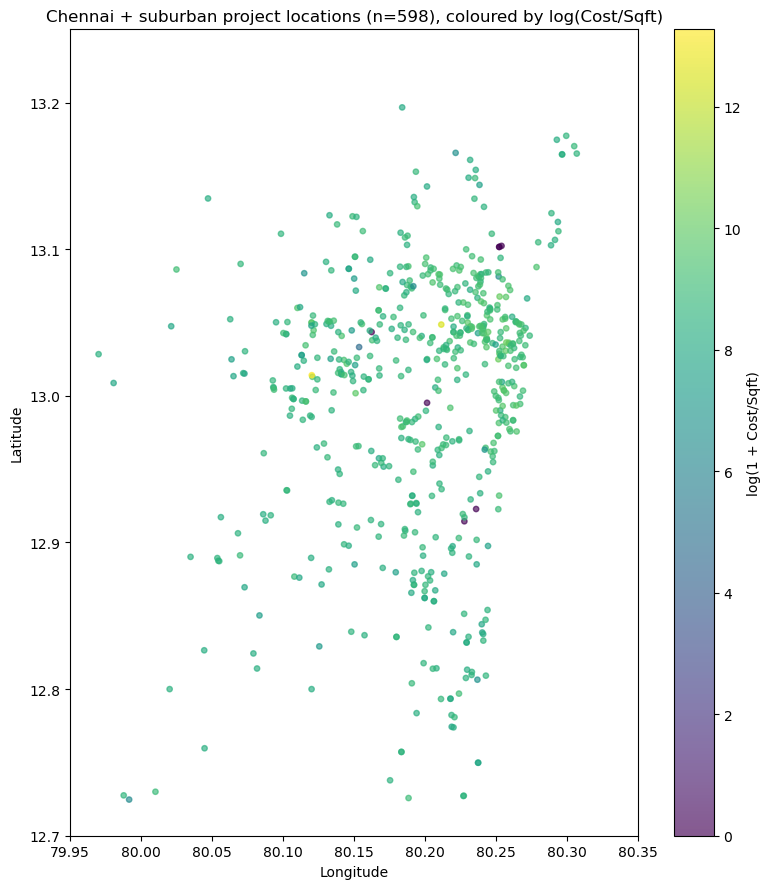

In [85]:
# 1. CHENNAI + SUBURBAN CHENNAI (CMA) BOUNDING BOX
CHENNAI_LAT_MIN, CHENNAI_LAT_MAX = 12.70, 13.25
CHENNAI_LON_MIN, CHENNAI_LON_MAX = 79.95, 80.35

valid_geo = df[
    df['Latitude'].between(CHENNAI_LAT_MIN, CHENNAI_LAT_MAX) &
    df['Longitude'].between(CHENNAI_LON_MIN, CHENNAI_LON_MAX)
].copy()

print(f"Rows with plausible coordinates (any district): {df[['Latitude','Longitude']].notna().all(axis=1).sum()} / {len(df)}")
print(f"Rows within Chennai + suburban bounding box: {len(valid_geo)} / {len(df)}")

cma_districts = ['Chennai', 'Chengalpattu', 'Kancheepuram', 'Tiruvallur']
print(f"Of those, District already tagged as Chennai/CMA: "
      f"{valid_geo['District'].isin(cma_districts).sum()} / {len(valid_geo)}")
print(f"Districts appearing inside the box: {sorted(valid_geo['District'].dropna().unique())}")

# ---------------------------------------------------------------------------
# 2. PLOT
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 9))

sc = ax.scatter(valid_geo['Longitude'], valid_geo['Latitude'],
                 c=np.log1p(valid_geo['FE_Total_Project_Cost_per_Sqft']),
                 cmap='viridis', s=15, alpha=0.65)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Chennai + suburban project locations (n={len(valid_geo)}), coloured by log(Cost/Sqft)')
ax.set_xlim(CHENNAI_LON_MIN, CHENNAI_LON_MAX)
ax.set_ylim(CHENNAI_LAT_MIN, CHENNAI_LAT_MAX)
plt.colorbar(sc, ax=ax, label='log(1 + Cost/Sqft)')
plt.tight_layout()
plt.show()

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


Note: you may need to restart the kernel to use updated packages.


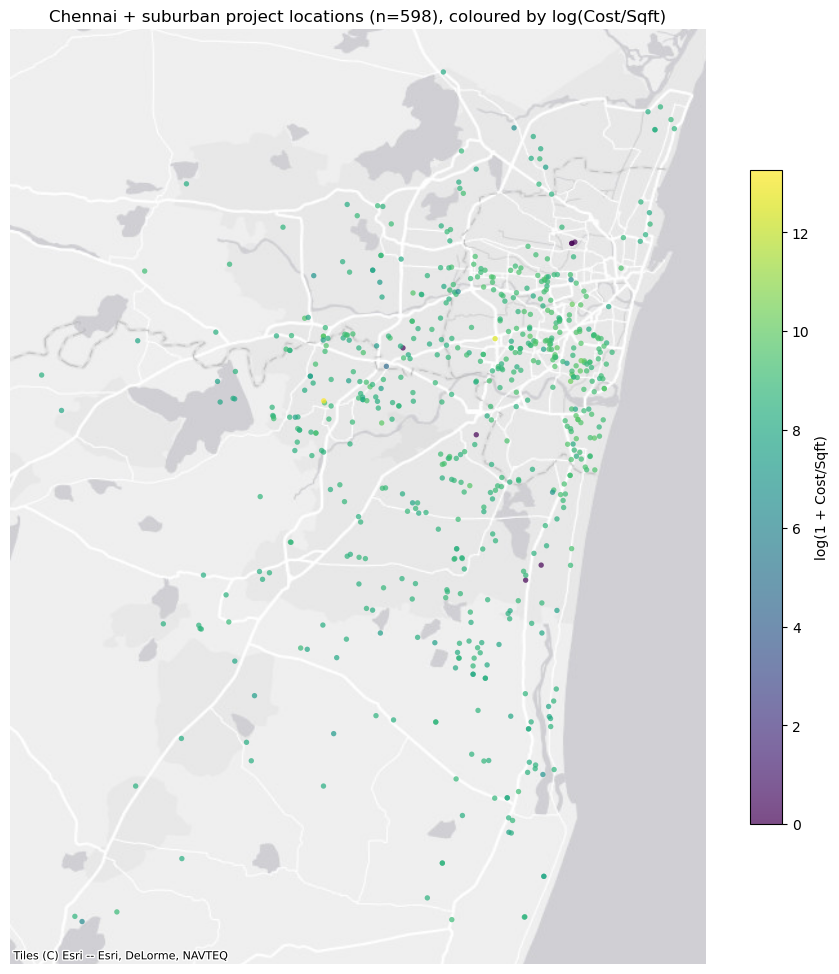

In [86]:
%pip install contextily  # one-time, if not already installed

import geopandas as gpd
import contextily as ctx

ctx.set_cache_dir('/home/claude/tile_cache')  # set BEFORE add_basemap, so the first fetch is cached too

# 1. Build a GeoDataFrame from your fixed coordinates, in standard lat/lon (EPSG:4326)
gdf = gpd.GeoDataFrame(
    valid_geo,
    geometry=gpd.points_from_xy(valid_geo['Longitude'], valid_geo['Latitude']),
    crs='EPSG:4326'
)

# 2. Reproject to Web Mercator (EPSG:3857) — this is the projection basemap tiles
#    (OSM, CartoDB, etc.) are served in. Plotting lat/lon directly against tiles
#    without this step gives you a badly warped map.
gdf_web = gdf.to_crs(epsg=3857)

# 3. Plot
fig, ax = plt.subplots(figsize=(9, 10))

sc = ax.scatter(
    gdf_web.geometry.x, gdf_web.geometry.y,
    c=np.log1p(gdf_web['FE_Total_Project_Cost_per_Sqft']),
    cmap='viridis', s=15, alpha=0.7, edgecolor='none'
)

# 4. Add the basemap UNDER the points. zoom='auto' picks tile resolution based on
#    the current axis extent — set explicitly (e.g. zoom=11) if tiles look too
#    blurry or too slow to load.
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldGrayCanvas, zoom='auto')

ax.set_axis_off()  # lat/lon tick labels are meaningless in Web Mercator meters
ax.set_title(f'Chennai + suburban project locations (n={len(gdf_web)}), coloured by log(Cost/Sqft)')
plt.colorbar(sc, ax=ax, label='log(1 + Cost/Sqft)', shrink=0.7)
plt.tight_layout()
plt.show()

In [87]:
# Rule: if a project reports ZERO parking across all three parking types
# (Covered, Open, Visitor), that's almost certainly a data collection gap or a Tamil Nadu Housing Board Project.

all_parking_zero = (
    (df['Covered_Parking'] == 0) &
    (df['Open_Parking'] == 0) &
    (df['Visitor_Parking'] == 0)
)

# Exclude small-unit projects — genuine zero parking, not a gap.
# Rows with unknown unit size are treated as NOT exempt (i.e. still flagged for imputation) —
# explicit choice, not a silent NaN default.
small_unit_exemption = df['FE_Average_Unit_Size_Sqft'] < 600

needs_parking_imputation = all_parking_zero & ~small_unit_exemption.fillna(False)

df['Imputed_Car_Parking'] = np.nan
df.loc[all_parking_zero, 'Imputed_Car_Parking'] = df.loc[all_parking_zero, 'Total_Dwelling_Units']

print(f"Rows with all parking = 0: {all_parking_zero.sum()}")
print(f"Rows exempted (small units, <600 sqft — genuine zero parking): {(all_parking_zero & small_unit_exemption.fillna(False)).sum()}")
print(f"Rows flagged for imputation (all parking = 0, unit size >= 600 or unknown): {needs_parking_imputation.sum()}")
print(f"Rows with a valid Total_Dwelling_Units to impute from: "
      f"{df.loc[needs_parking_imputation, 'Total_Dwelling_Units'].notna().sum()}")

unresolvable = needs_parking_imputation & df['Total_Dwelling_Units'].isna()
print(f"Rows flagged but unresolvable (Total_Dwelling_Units also null): {unresolvable.sum()}")

df['Parking_was_imputed'] = needs_parking_imputation

Rows with all parking = 0: 36
Rows exempted (small units, <600 sqft — genuine zero parking): 35
Rows flagged for imputation (all parking = 0, unit size >= 600 or unknown): 1
Rows with a valid Total_Dwelling_Units to impute from: 1
Rows flagged but unresolvable (Total_Dwelling_Units also null): 0


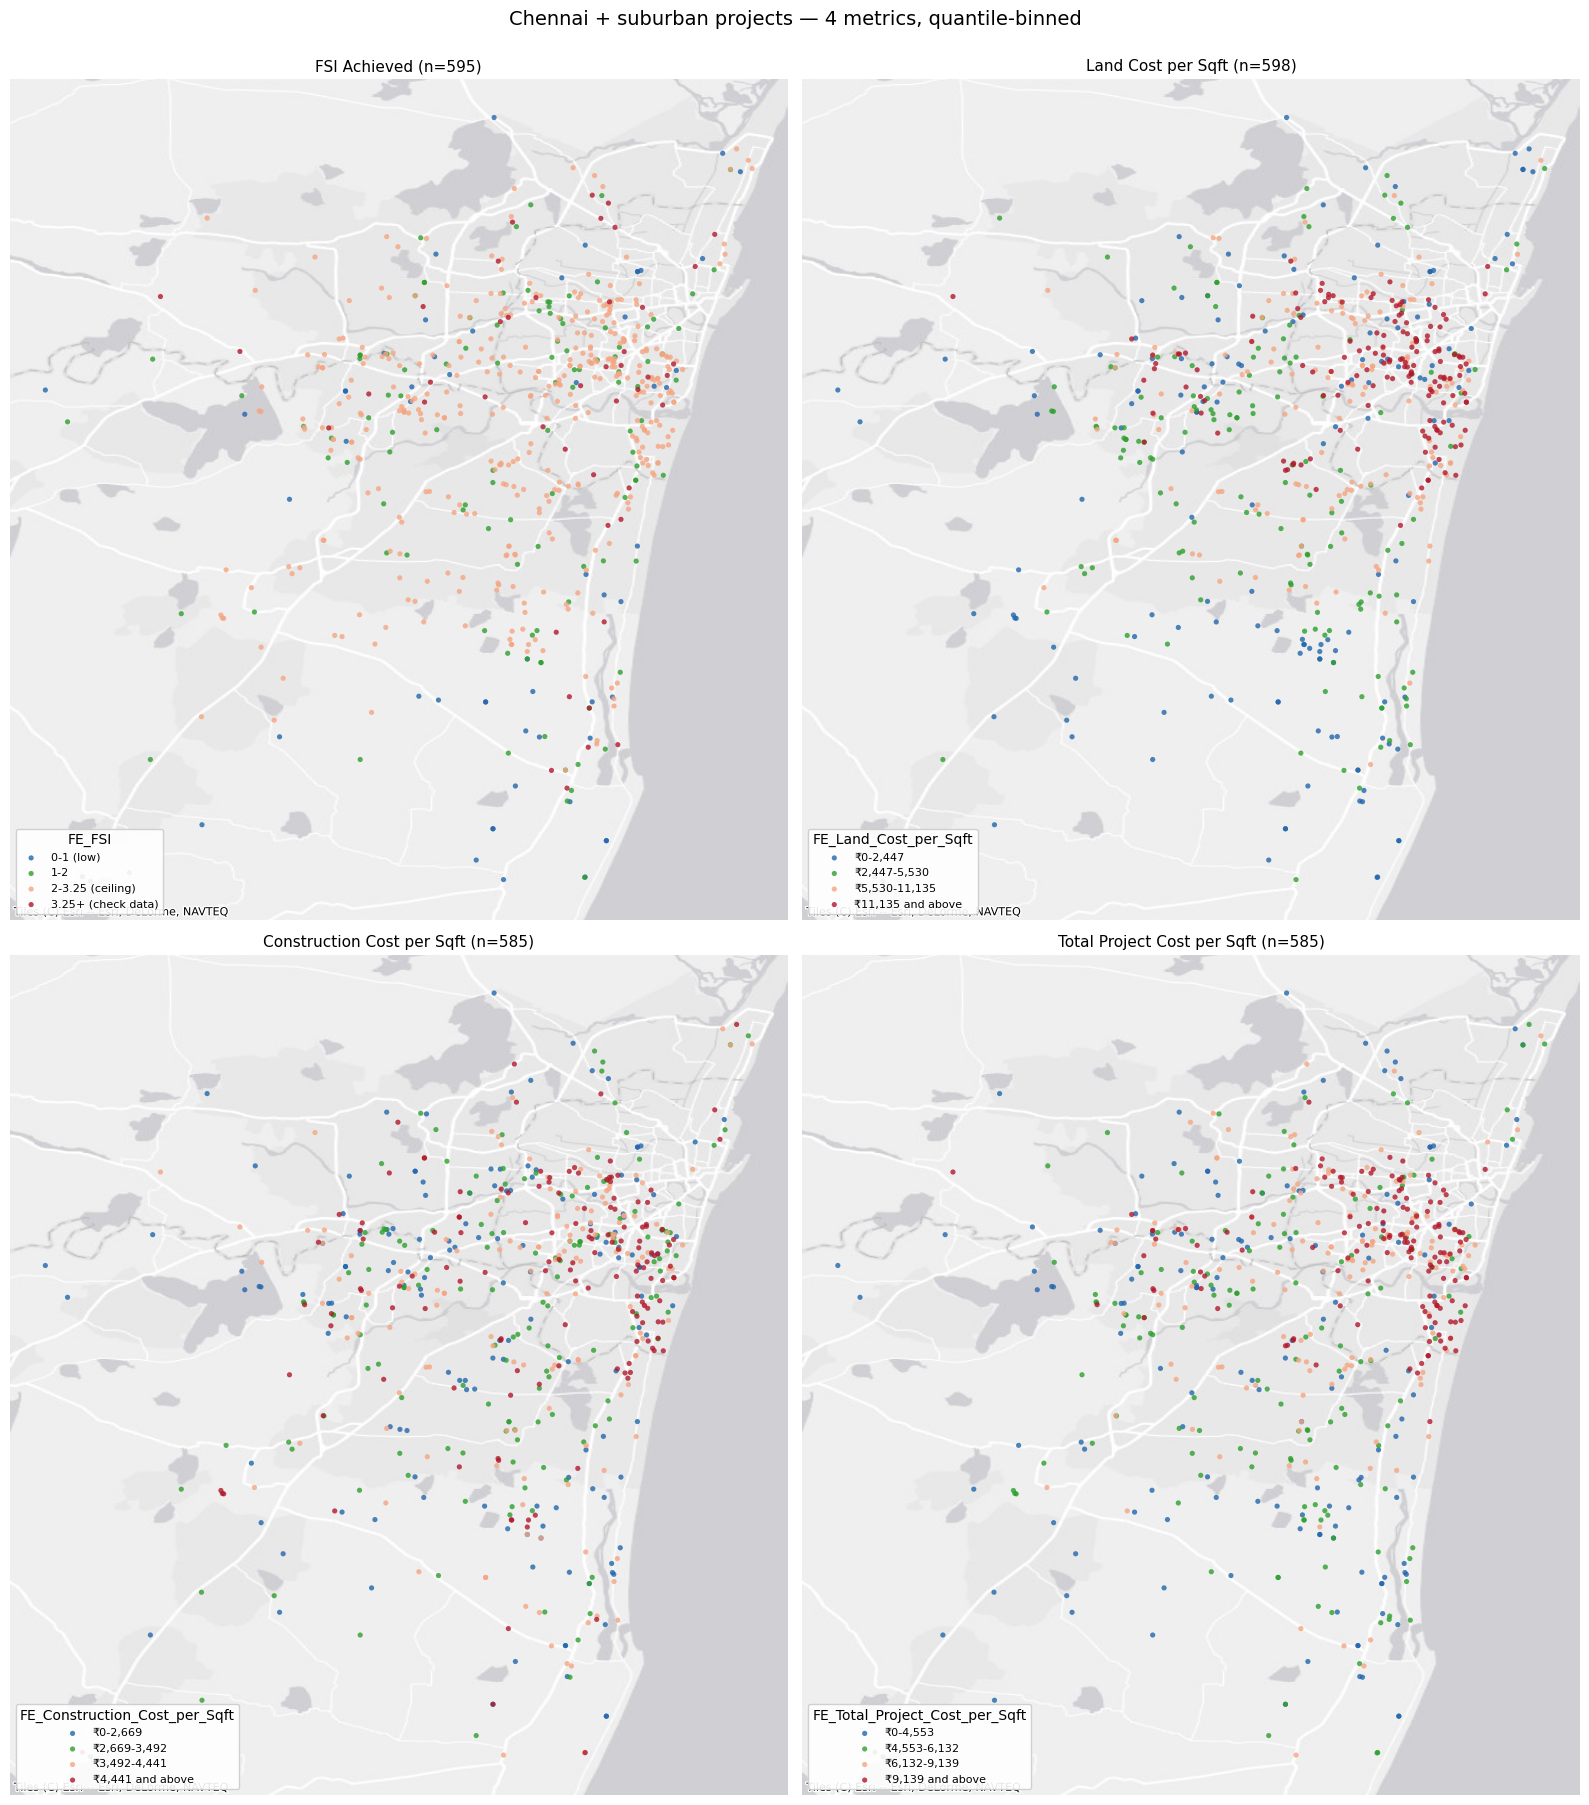

In [88]:
import numpy as np
import pandas as pd
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# Legend Colour Selection — 2nd bin changed from light blue (#67a9cf) to green
solid_colors = ['#2166ac', '#2ca02c', '#f4a582', '#b2182b']  # blue -> green -> orange -> red

gdf = gpd.GeoDataFrame(
    valid_geo,
    geometry=gpd.points_from_xy(valid_geo['Longitude'], valid_geo['Latitude']),
    crs='EPSG:4326'
).to_crs(epsg=3857)

ctx.set_cache_dir('/home/claude/tile_cache')

def add_binned_layer(ax, plot_df, col, bins, bin_labels):
    """Bins `col` into fixed categories and plots each as a solid colour with a legend."""
    plot_df = plot_df.copy()
    plot_df['_bin'] = pd.cut(plot_df[col], bins=bins, labels=bin_labels, include_lowest=True)

    for label, color in zip(bin_labels, solid_colors):
        subset = plot_df[plot_df['_bin'] == label]
        ax.scatter(subset.geometry.x, subset.geometry.y,
                   color=color, s=14, alpha=0.8, edgecolor='none', label=label)

    ctx.add_basemap(ax, source=ctx.providers.Esri.WorldGrayCanvas, zoom='auto')
    ax.set_axis_off()
    ax.legend(loc='lower left', fontsize=8, framealpha=0.9, title=col)

fig, axes = plt.subplots(2, 2, figsize=(16, 18))
axes = axes.flatten()

fsi_df = gdf.dropna(subset=['FE_FSI'])
add_binned_layer(
    axes[0], fsi_df, 'FE_FSI',
    bins=[0, 1, 2, 3.25, 5],
    bin_labels=['0-1 (low)', '1-2', '2-3.25 (ceiling)', '3.25+ (check data)']
)
axes[0].set_title(f'FSI Achieved (n={len(fsi_df)})', fontsize=11)

cost_cols = [
    ('FE_Land_Cost_per_Sqft', 'Land Cost per Sqft'),
    ('FE_Construction_Cost_per_Sqft', 'Construction Cost per Sqft'),
    ('FE_Total_Project_Cost_per_Sqft', 'Total Project Cost per Sqft'),
]

for ax, (col, title) in zip(axes[1:], cost_cols):
    plot_df = gdf.dropna(subset=[col])
    binned, edges = pd.qcut(plot_df[col], q=4, retbins=True, duplicates='drop')

    labels = []
    for i in range(len(edges) - 1):
        if i == len(edges) - 2:
            labels.append(f'₹{edges[i]:,.0f} and above')
        else:
            labels.append(f'₹{edges[i]:,.0f}-{edges[i+1]:,.0f}')

    add_binned_layer(ax, plot_df, col, bins=edges, bin_labels=labels)
    ax.set_title(f'{title} (n={len(plot_df)})', fontsize=11)

plt.suptitle('Chennai + suburban projects — 4 metrics, quantile-binned', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

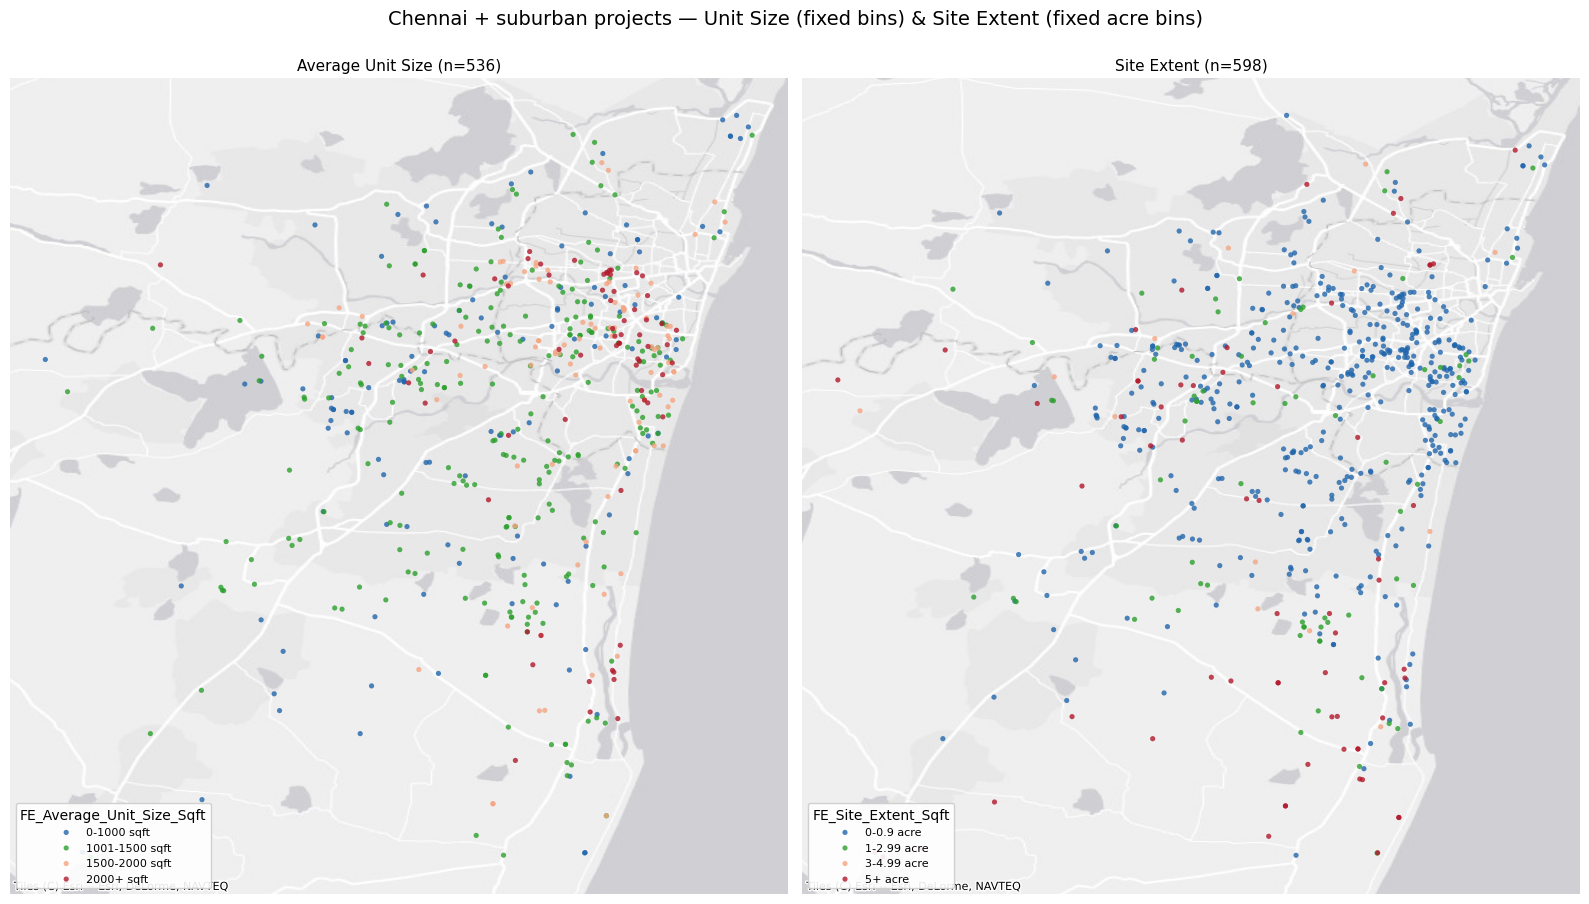

In [89]:
ACRE_TO_SQFT = 43560

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# --- Panel 1: Average Unit Size — fixed bins (unchanged) ---
unit_size_df = gdf.dropna(subset=['FE_Average_Unit_Size_Sqft'])
add_binned_layer(
    axes[0], unit_size_df, 'FE_Average_Unit_Size_Sqft',
    bins=[0, 1000, 1500, 2000, np.inf],
    bin_labels=['0-1000 sqft', '1001-1500 sqft', '1500-2000 sqft', '2000+ sqft']
)
axes[0].set_title(f'Average Unit Size (n={len(unit_size_df)})', fontsize=11)

# --- Panel 2: Site Extent — fixed acre-based bins, not quantiles ---
site_df = gdf.dropna(subset=['FE_Site_Extent_Sqft'])
acre_bins_sqft = [0, 0.9 * ACRE_TO_SQFT, 2.99 * ACRE_TO_SQFT, 4.99 * ACRE_TO_SQFT, np.inf]
acre_labels = ['0-0.9 acre', '1-2.99 acre', '3-4.99 acre', '5+ acre']

add_binned_layer(axes[1], site_df, 'FE_Site_Extent_Sqft', bins=acre_bins_sqft, bin_labels=acre_labels)
axes[1].set_title(f'Site Extent (n={len(site_df)})', fontsize=11)

plt.suptitle('Chennai + suburban projects — Unit Size (fixed bins) & Site Extent (fixed acre bins)', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

## Checking and Drop

Checking some values that hindered in modelling phase. 

In [90]:
df[df['Total_Project_Cost']==0]

,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m,FE_Site_Extent_Sqft,FE_Total_FSI_Area_Sqft,FE_FSI,FE_Permissable_FSI,FE_Max_Premium_FSI,FE_Total_Parking,FE_Land_Cost_per_Sqft,FE_Construction_Cost_per_Sqft,FE_Total_Project_Cost_per_Sqft,FE_Land_Cost_Ratio,FE_Construction_Cost_Ratio,FE_Cost_Per_Dwelling_Unit,FE_Average_Unit_Size_Sqft,Is_TNUHDB_TNHB,Is_Dwelling_Units_Hardcoded,Is_FSI_Imputed_From_Comparable_Avg,Coord_Was_Corrupted,Is_Coordinates_Hardcoded,District,Usage_clean,FSI_outlier_flag,Imputed_Car_Parking,Parking_was_imputed


In [91]:
df[df['FE_Total_Project_Cost_per_Sqft'] == 0]

,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m,FE_Site_Extent_Sqft,FE_Total_FSI_Area_Sqft,FE_FSI,FE_Permissable_FSI,FE_Max_Premium_FSI,FE_Total_Parking,FE_Land_Cost_per_Sqft,FE_Construction_Cost_per_Sqft,FE_Total_Project_Cost_per_Sqft,FE_Land_Cost_Ratio,FE_Construction_Cost_Ratio,FE_Cost_Per_Dwelling_Unit,FE_Average_Unit_Size_Sqft,Is_TNUHDB_TNHB,Is_Dwelling_Units_Hardcoded,Is_FSI_Imputed_From_Comparable_Avg,Coord_Was_Corrupted,Is_Coordinates_Hardcoded,District,Usage_clean,FSI_outlier_flag,Imputed_Car_Parking,Parking_was_imputed
138,RISINGTON PHASE - II,TN/29/Building/0379/2024,"S. No: 166/1A, 166/1B,166/2, 166/3A, 166/3B, 1...",Chennai,12.91,80.23,Residential,High Rise Building (HRB),46186,9869,29903,<NA>,1332,2200,4500,100,6800,242,43,13,[],[],497141,428106,0.86,2.00,4.87,298,0,0,0,0.32,0.66,5,321,False,False,False,0,False,Chennai,Residential,False,NaN,False
143,SPR Binny Highliving - Phase II,TN/29/Building/0390/2024,Block 4 (Tower C&D) (Residential Use): compris...,Chennai,13.10,80.25,Residential,High Rise Building (HRB),196202,<NA>,34139,<NA>,1796,46,91,28,164,540,270,45,[{'block': 'Block 4 (Tower C&D) (Residential U...,[],2111898,367464,0.17,2.00,4.87,855,0,0,0,0.28,0.56,0,205,False,False,False,0,False,Chennai,Residential,False,NaN,False
145,SPR BINNY SKY - PHASE I (THE CAPITAL DISTRICT),TN/29/Building/0396/2024,Block No.7 (residential + commercial): Double ...,Chennai,13.10,80.25,Mixed Development,High Rise Building (HRB),196202,<NA>,74587,10336,1796,125,90,8,223,651,0,65,[{'block': 'Block No.7 (residential + commerci...,[],2111898,914097,0.43,2.00,4.87,716,0,0,0,0.56,0.40,0,447,False,False,False,0,False,Chennai,Mixed Development,False,NaN,False
154,SPR CITY Market of India - Phase I,TN/29/Building/0416/2024,Block No.6 (commercial Market & retail): Tripl...,Chennai,13.10,80.25,Commercial,High Rise Building (HRB),196202,<NA>,<NA>,60117,<NA>,313,580,62,955,431,0,0,[{'block': 'Block No.6 (commercial Market & re...,[],2111898,647093,0.31,2.00,4.87,431,0,0,0,0.33,0.61,<NA>,<NA>,False,False,False,0,False,Chennai,Commercial,False,NaN,False
157,Construction of 450 EWS tenements at NN Nagar ...,TN/29/Building/0420/2024,Construction of 450 EWS tenements at NN Nagar ...,Chennai,13.04,80.16,Residential,Non-High Rise Building (NHRB),9063,<NA>,18547,<NA>,450,0,7687,0,7687,0,0,0,[],[],97556,199638,2.05,2.00,2.00,0,0,0,0,0.00,1.00,17,444,True,False,False,1,False,Chennai,Residential,False,450.00,False
195,VILASA,TN/29/Building/0497/2024,"Plot No.64, Sakthi Garden, Okkiam Thoraipakkam...",Chennai,12.92,80.24,Residential,Non-High Rise Building (NHRB),570,0,1129,<NA>,9,4,6,1,11,10,10,0,[],[],6135,12153,1.98,2.00,2.00,20,0,0,0,0.36,0.55,1,1350,False,False,False,0,False,Chennai,Residential,False,NaN,False
892,Kaadosh Cullinan,TNRERA/29/BLG/0123/2026,The Proposed construction of stilt floor + 4 F...,Chennai,13.00,80.20,Residential,Non-High Rise Building (NHRB),3026,0,7841,0,66,35,43,<NA>,78,50,17,7,"[{'block': None, 'base_level': 'Stilt', 'floor...",[18.3],32566,84396,2.59,2.00,2.00,74,0,0,0,0.45,0.55,1,1279,False,False,False,0,False,Chennai,Residential,False,NaN,False


In [92]:
df[(df['Total_Project_Cost'] < 3000000) & (df['Is_TNUHDB_TNHB'] == False)]

,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m,FE_Site_Extent_Sqft,FE_Total_FSI_Area_Sqft,FE_FSI,FE_Permissable_FSI,FE_Max_Premium_FSI,FE_Total_Parking,FE_Land_Cost_per_Sqft,FE_Construction_Cost_per_Sqft,FE_Total_Project_Cost_per_Sqft,FE_Land_Cost_Ratio,FE_Construction_Cost_Ratio,FE_Cost_Per_Dwelling_Unit,FE_Average_Unit_Size_Sqft,Is_TNUHDB_TNHB,Is_Dwelling_Units_Hardcoded,Is_FSI_Imputed_From_Comparable_Avg,Coord_Was_Corrupted,Is_Coordinates_Hardcoded,District,Usage_clean,FSI_outlier_flag,Imputed_Car_Parking,Parking_was_imputed
138,RISINGTON PHASE - II,TN/29/Building/0379/2024,"S. No: 166/1A, 166/1B,166/2, 166/3A, 166/3B, 1...",Chennai,12.91,80.23,Residential,High Rise Building (HRB),46186,9869,29903,<NA>,1332,2200,4500,100,6800,242,43,13,[],[],497141,428106,0.86,2.00,4.87,298,0,0,0,0.32,0.66,5,321,False,False,False,0,False,Chennai,Residential,False,NaN,False
143,SPR Binny Highliving - Phase II,TN/29/Building/0390/2024,Block 4 (Tower C&D) (Residential Use): compris...,Chennai,13.10,80.25,Residential,High Rise Building (HRB),196202,<NA>,34139,<NA>,1796,46,91,28,164,540,270,45,[{'block': 'Block 4 (Tower C&D) (Residential U...,[],2111898,367464,0.17,2.00,4.87,855,0,0,0,0.28,0.56,0,205,False,False,False,0,False,Chennai,Residential,False,NaN,False
145,SPR BINNY SKY - PHASE I (THE CAPITAL DISTRICT),TN/29/Building/0396/2024,Block No.7 (residential + commercial): Double ...,Chennai,13.10,80.25,Mixed Development,High Rise Building (HRB),196202,<NA>,74587,10336,1796,125,90,8,223,651,0,65,[{'block': 'Block No.7 (residential + commerci...,[],2111898,914097,0.43,2.00,4.87,716,0,0,0,0.56,0.40,0,447,False,False,False,0,False,Chennai,Mixed Development,False,NaN,False
154,SPR CITY Market of India - Phase I,TN/29/Building/0416/2024,Block No.6 (commercial Market & retail): Tripl...,Chennai,13.10,80.25,Commercial,High Rise Building (HRB),196202,<NA>,<NA>,60117,<NA>,313,580,62,955,431,0,0,[{'block': 'Block No.6 (commercial Market & re...,[],2111898,647093,0.31,2.00,4.87,431,0,0,0,0.33,0.61,<NA>,<NA>,False,False,False,0,False,Chennai,Commercial,False,NaN,False
195,VILASA,TN/29/Building/0497/2024,"Plot No.64, Sakthi Garden, Okkiam Thoraipakkam...",Chennai,12.92,80.24,Residential,Non-High Rise Building (NHRB),570,0,1129,<NA>,9,4,6,1,11,10,10,0,[],[],6135,12153,1.98,2.00,2.00,20,0,0,0,0.36,0.55,1,1350,False,False,False,0,False,Chennai,Residential,False,NaN,False
892,Kaadosh Cullinan,TNRERA/29/BLG/0123/2026,The Proposed construction of stilt floor + 4 F...,Chennai,13.00,80.20,Residential,Non-High Rise Building (NHRB),3026,0,7841,0,66,35,43,<NA>,78,50,17,7,"[{'block': None, 'base_level': 'Stilt', 'floor...",[18.3],32566,84396,2.59,2.00,2.00,74,0,0,0,0.45,0.55,1,1279,False,False,False,0,False,Chennai,Residential,False,NaN,False


In [93]:
# Dropping these projects 

corrupted_cost_reg_nos = [
    'TN/29/Building/0379/2024',
    'TN/29/Building/0390/2024',
    'TN/29/Building/0396/2024',
    'TN/29/Building/0497/2024',
    'TNRERA/29/BLG/0123/2026',
    'TN/29/Building/0416/2024',
]

df = df[~df['Project_Registration_No'].isin(corrupted_cost_reg_nos)]
print(f"Rows remaining: {len(df)}")

Rows remaining: 1020


Dropped 6 projects with corrupted cost data

These rows had Total_Project_Cost values far too small to be real — implied cost-per-dwelling-unit of ₹0-5, when a real dwelling unit costs lakhs at minimum. Checked for a consistent unit-conversion error (lakhs vs. rupees, crore vs. rupees) but the implied multiplier needed to reach a plausible cost differs row to row with no consistent factor — ruling out a simple scale fix. Most likely a PDF extraction failure that pulled a partial or wrong figure, not a recoverable unit mismatch.

Dropped rather than imputed, since Total_Project_Cost directly feeds the model's target variable — imputing a target-adjacent field defeats the purpose of training on it.

Registration numbers dropped: TN/29/Building/0379/2024, TN/29/Building/0390/2024, TN/29/Building/0396/2024, TN/29/Building/0497/2024, TNRERA/29/BLG/0123/2026, TN/29/Building/0416/2024

In [94]:
# Drop Rows which have 'Is_TNUHDB_TNHB'==TRUE


drop_index = df[df['Is_TNUHDB_TNHB'] == True].index
print("No of Rows being dropped :",len(drop_index))
df = df.drop(drop_index)
print("No of Rows in df_set1 :",len(df))

No of Rows being dropped : 30
No of Rows in df_set1 : 990


In [95]:
# Check Total Project COst per sqft column 

df['FE_Total_Project_Cost_per_Sqft'].describe()

count      984.00
mean      7284.80
std      20486.97
min        102.00
25%       4027.00
50%       5473.00
75%       8088.75
max     581304.00
Name: FE_Total_Project_Cost_per_Sqft, dtype: Float64

In [96]:
Cost_less_2000 = df[df['FE_Total_Project_Cost_per_Sqft'] <= 2000]
Cost_above_14000 = df[df['FE_Total_Project_Cost_per_Sqft'] >=14000]

print("No of rows belwow 2000 : " , len(Cost_less_2000))
print("no of rows above 14000 : " , len(Cost_above_14000))

display(Cost_less_2000)
display(Cost_above_14000)


No of rows belwow 2000 :  38
no of rows above 14000 :  44


,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m,FE_Site_Extent_Sqft,FE_Total_FSI_Area_Sqft,FE_FSI,FE_Permissable_FSI,FE_Max_Premium_FSI,FE_Total_Parking,FE_Land_Cost_per_Sqft,FE_Construction_Cost_per_Sqft,FE_Total_Project_Cost_per_Sqft,FE_Land_Cost_Ratio,FE_Construction_Cost_Ratio,FE_Cost_Per_Dwelling_Unit,FE_Average_Unit_Size_Sqft,Is_TNUHDB_TNHB,Is_Dwelling_Units_Hardcoded,Is_FSI_Imputed_From_Comparable_Avg,Coord_Was_Corrupted,Is_Coordinates_Hardcoded,District,Usage_clean,FSI_outlier_flag,Imputed_Car_Parking,Parking_was_imputed
2,CASAGRAND ALPINE,TN/11/Building/0331/2024,proposed construction of Residential Group Dev...,Coimbatore,11.06,76.60,Residential,Non-High Rise Building (NHRB),5673,<NA>,11986,599,144,12212576,203202738,23029644,238444958,97,2,2,"[{'block': None, 'base_level': 'Stilt', 'floor...",[],61063,135467,2.22,2.00,2.00,101,200,1500,1760,0.05,0.85,1655868,896,False,False,False,1,False,Coimbatore,Residential,False,NaN,False
3,TIARA,TN/11/Building/0341/2024,"S.F.NO:370/3,CHINNAVEDAMPATTI,COIM BATORE-641049",Coimbatore,11.05,76.58,Residential,Non-High Rise Building (NHRB),1133,<NA>,2914,<NA>,22,3659100,30000000,2917400,36576500,24,0,2,[],[],12195,31362,2.57,2.00,2.00,26,300,957,1166,0.10,0.82,1662568,1426,False,False,False,1,False,Coimbatore,Residential,False,NaN,False
52,-,TN/16/Building/0311/2024,Block 1 - Stilt Floor + 5 Floors residential b...,Tiruchirappalli,10.50,78.42,Residential,Non-High Rise Building (NHRB),1827,<NA>,3678,<NA>,47,10000000,1000000,50000000,61000000,23,3,0,"[{'block': None, 'base_level': 'Stilt', 'floor...",[],19661,39588,2.01,2.00,2.00,26,509,25,1541,0.16,0.02,1297872,842,False,False,False,0,False,Tiruchirappalli,Residential,False,NaN,False
72,CASAGRAND MASSIMO https://rera.tn.gov.in/publi...,TN/1/Building/0362/2024,Proposed Construction of High Rise Group Devel...,Kancheepuram,13.01,80.11,Residential,High Rise Building (HRB),31930,<NA>,106992,2290,853,207434412,1764451187,199971135,2171856734,850,138,60,"[{'block': None, 'base_level': 'Ground', 'floo...",[65.35],343688,1176290,3.42,2.00,4.87,1048,604,1500,1846,0.10,0.81,2546139,1350,False,False,False,1,True,Kancheepuram,Residential,False,NaN,False
94,SUDHARMA,TN/26/Building/0532/2024,"T.S.NO: 62, NEW SURVEY WARD: BM, BLOCK: 6, SUR...",Tirunelveli,8.70,77.74,Residential,Non-High Rise Building (NHRB),944,78,2623,<NA>,25,17500000,8000000,6000000,31500000,16,9,3,[],[],10157,29071,2.86,2.00,2.00,28,1723,275,1084,0.56,0.25,1260000,1163,False,False,False,0,False,Tirunelveli,Residential,False,NaN,False
106,Megh Aarika,TN/29/Building/0318/2024,"Plot No.17,Chanakyan Main Road,Annamalai Avenu...",Chennai,13.04,80.10,Residential,Non-High Rise Building (NHRB),1200,<NA>,2833,<NA>,17,50000000,250000,1200000,51450000,28,2,0,[],[],12917,30496,2.36,2.00,2.00,30,3871,8,1687,0.97,0.00,3026471,1794,False,False,False,0,False,Chennai,Residential,False,NaN,False
116,VATSA AMAZE,TN/29/Building/0336/2024,Group Housing Development consisting of 2 Bloc...,Chennai,13.02,80.07,Residential,Non-High Rise Building (NHRB),4050,<NA>,9875,<NA>,107,174240000,142000,3876700,178258700,81,10,0,[],"[18.3, 18.3]",43594,106289,2.44,2.00,2.00,91,3997,1,1677,0.98,0.00,1665969,993,False,False,False,0,False,Chennai,Residential,False,NaN,False
119,Akshardham,TN/29/Building/0342/2024,"Old Door No.75, New Door No.68 (earlier Door N...",Chennai,13.08,80.25,Residential,Non-High Rise Building (NHRB),1538,<NA>,4888,<NA>,25,15000000,13000000,5500000,33500000,38,2,4,[],[],16560,52619,3.18,2.00,2.00,44,906,247,637,0.45,0.39,1340000,2105,False,False,False,0,False,Chennai,Residential,False,NaN,False
121,CASAGRAND HOLA CHENNAI https://rera.tn.gov.in/...,TN/29/Building/0352/2024,Proposed Construction of High Rise Group Devel.

,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m,FE_Site_Extent_Sqft,FE_Total_FSI_Area_Sqft,FE_FSI,FE_Permissable_FSI,FE_Max_Premium_FSI,FE_Total_Parking,FE_Land_Cost_per_Sqft,FE_Construction_Cost_per_Sqft,FE_Total_Project_Cost_per_Sqft,FE_Land_Cost_Ratio,FE_Construction_Cost_Ratio,FE_Cost_Per_Dwelling_Unit,FE_Average_Unit_Size_Sqft,Is_TNUHDB_TNHB,Is_Dwelling_Units_Hardcoded,Is_FSI_Imputed_From_Comparable_Avg,Coord_Was_Corrupted,Is_Coordinates_Hardcoded,District,Usage_clean,FSI_outlier_flag,Imputed_Car_Parking,Parking_was_imputed
97,ETICA MALAR MRC NAGAR,TN/29/Building/0305/2024,"Old R.S.No. 4297/8, R.S.NO.4297/24, BLOCK NO.9...",Chennai,13.02,80.27,Residential,High Rise Building (HRB),1207,<NA>,3172,<NA>,18,227959375,255875531,0,483834906,18,12,30,[],[],12995,34147,2.63,2.00,4.87,60,17542,7493,14169,0.47,0.53,26879717,1897,False,False,False,1,False,Chennai,Residential,False,NaN,False
107,-,TN/29/Building/0319/2024,Registration of Stilt Floor + 5 Floors Commerc...,Chennai,13.05,80.26,Commercial,Non-High Rise Building (NHRB),418,<NA>,<NA>,728,<NA>,87500000,25000000,9000000,121500000,11,4,0,"[{'block': None, 'base_level': 'Stilt', 'floor...",[],4499,7833,1.74,2.00,2.00,15,19449,3192,15511,0.72,0.21,<NA>,<NA>,False,False,False,0,False,Chennai,Commercial,False,NaN,False
109,#61,TN/29/Building/0322/2024,Stilt floor ( Mechanized Puzzle Parking ) + 4 ...,Chennai,13.03,80.26,Commercial,Non-High Rise Building (NHRB),670,<NA>,<NA>,1413,<NA>,240000000,80000000,7000000,327000000,17,0,0,"[{'block': None, 'base_level': 'Stilt', 'floor...",[],7217,15208,2.11,2.00,2.00,17,33254,5260,21502,0.73,0.24,<NA>,<NA>,False,False,False,0,False,Chennai,Commercial,False,NaN,False
129,-,TN/29/Building/0366/2024,Basement Floor + Stilt Floor (Part) / Ground F...,Chennai,12.99,80.25,Commercial,Non-High Rise Building (NHRB),962,<NA>,<NA>,1580,<NA>,185150000,59400000,15748500,260298500,13,1,2,"[{'block': None, 'base_level': 'Ground', 'floo...",[],10360,17008,1.64,2.00,2.00,16,17872,3492,15304,0.71,0.23,<NA>,<NA>,False,False,False,0,False,Chennai,Commercial,False,NaN,False
137,KHURINJI ORCHID,TN/29/Building/0377/2024,"Plot No.68, New No.2, Old No.43, 1st Cross Str...",Chennai,13.01,80.25,Residential,Non-High Rise Building (NHRB),512,<NA>,1224,<NA>,10,140000000,67500000,7500000,215000000,8,3,1,[],[],5515,13170,2.39,2.00,2.00,12,25385,5125,16325,0.65,0.31,21500000,1317,False,False,False,0,False,Chennai,Residential,False,NaN,False
162,-,TN/29/Building/0427/2024,proposed project Commercial building at plot N...,Chennai,13.05,80.12,Commercial,Non-High Rise Building (NHRB),567,80,0,840,<NA>,137200000,56600000,1355500,195155500,2,8,2,[],[],6100,9906,1.62,2.00,2.00,12,22492,5714,19701,0.70,0.29,<NA>,<NA>,False,False,False,0,False,Chennai,Commercial,False,NaN,False
175,AMARA AANYA,TN/29/Building/0456/2024,"Old Door No. 121 & 122, New Door No. 187 & 191...",Chennai,13.03,80.25,Residential,High Rise Building (HRB),3390,0,15781,<NA>,39,2194900000,1420400000,99500000,3714800000,149,5,15,[],[],36484,169868,4.66,2.00,4.87,169,60160,8362,21869,0.59,0.38,95251282,4356,False,False,False,0,False,Chennai,Residential,False,NaN,False
196,UPPER HOUSE https://rera.tn.gov.in/public-view...,TN/29/Building/0501/2024,REVISED PROPOSED CONSTRUCTION OF REGISTRATION ...,Chennai,13.02,80.25,Residential,Non-High Rise Building (NHRB),1832,0,4518,<NA>,9,970000000,390000000,20000000,1380000000,51,0,4,"[{'block': None, 'base_level': 'Ground', 'floo...",[18.3],19725,48630,2.47,2.00,2.00,55,49177,8020,28378,0.70,0.28,153333333,5403,False,False,False,0,False,Chennai,Residential,False,NaN,False
199,BRINDAVAN,TN/29/Building/0508/2024,STILT + 5 FLOORS,Chennai,13.00,80.26,Residential,Non-High Rise Building (NHRB),1012,0,2829,<NA>,1

In [97]:
# Drop selected rows for having unusual high cost.

reg_nos_to_drop = ['TNRERA/29/BLG/0422/2025', 'TN/29/Building/0508/2024', 'TNRERA29BLG0002/2026']

drop_index = df[df['Project_Registration_No'].isin(reg_nos_to_drop)].index
df = df.drop(drop_index)
print(len(df))

987


In [98]:
# Drop selected rows for having unusual low cost

Cost_less_2000 = df[df['FE_Total_Project_Cost_per_Sqft'] <= 2000]
print(f"Dropping {len(Cost_less_2000)} rows")

df = df.drop(Cost_less_2000.index)
print(len(df))

Dropping 38 rows
949


In [99]:
df['FE_Total_Project_Cost_per_Sqft'].isna().sum()

np.int64(6)

In [100]:
missing_cost_rows = df[df['FE_Total_Project_Cost_per_Sqft'].isna()]
display(missing_cost_rows)

,Project_Name,Project_Registration_No,Project_Details,Districts,Latitude,Longitude,Usage,Type_of_Building,Site_Extent_Sqm,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial,Total_Dwelling_Units,Land_Cost,Construction_Cost,Other_Cost,Total_Project_Cost,Covered_Parking,Open_Parking,Visitor_Parking,Floor_mentions,Heights_m,FE_Site_Extent_Sqft,FE_Total_FSI_Area_Sqft,FE_FSI,FE_Permissable_FSI,FE_Max_Premium_FSI,FE_Total_Parking,FE_Land_Cost_per_Sqft,FE_Construction_Cost_per_Sqft,FE_Total_Project_Cost_per_Sqft,FE_Land_Cost_Ratio,FE_Construction_Cost_Ratio,FE_Cost_Per_Dwelling_Unit,FE_Average_Unit_Size_Sqft,Is_TNUHDB_TNHB,Is_Dwelling_Units_Hardcoded,Is_FSI_Imputed_From_Comparable_Avg,Coord_Was_Corrupted,Is_Coordinates_Hardcoded,District,Usage_clean,FSI_outlier_flag,Imputed_Car_Parking,Parking_was_imputed
278,JONES CASSIA VIII https://rera.tn.gov.in/publi...,TN/35/Building/0431/2024,"S.NO284/1A, 285/1, 285/2A, 285/2B, 285/2C1A, 2...",Chengalpattu,12.87,80.19,Residential,Non-High Rise Building (NHRB),15146,<NA>,14500,<NA>,66,85000000,448332500,65705684,599038184,131,10,13,"[{'block': None, 'base_level': 'Ground', 'floo...","[10.5, 10.5]",163030,156072,NaN,2.00,2.00,154,521,<NA>,<NA>,0.14,0.75,9076336,<NA>,False,False,False,0,False,Chengalpattu,Residential,False,NaN,False
339,Kalaignar Nagar Scheme,TNRERA/26/BLG/0405/2025,Construction of 468 tenements (G+5 Storied) in...,Tirunelveli,8.33,77.55,Residential,Non-High Rise Building (NHRB),20200,0,0,<NA>,468,0,5301202095,<NA>,5301202095,0,0,0,"[{'block': None, 'base_level': 'Ground', 'floo...",[],217431,0,0.00,2.00,2.00,0,0,<NA>,<NA>,0.00,1.00,11327355,0,False,False,False,0,False,Tirunelveli,Residential,False,468.00,False
369,Whispers of sky,TNRERA/29/BLG/0389/2025,"740/1 & 742/1A of Sholinganallur Village, Shol...",Chennai,12.53,80.13,Mixed Development,High Rise Building (HRB),24845,<NA>,<NA>,<NA>,623,1025800000,3833700000,<NA>,4859500000,626,46,46,[],[],267429,<NA>,NaN,2.00,4.87,718,3836,<NA>,<NA>,0.21,0.79,7800161,<NA>,False,False,False,1,False,Chennai,Mixed Development,False,NaN,False
370,MERIDIAN,TNRERA/29/BLG/0390/2025,Revised Approval for Proposed Additional const...,Chennai,12.95,80.19,Commercial,Non-High Rise Building (NHRB),1389,<NA>,<NA>,<NA>,<NA>,112339470,134316142,<NA>,246655612,15,10,3,"[{'block': None, 'base_level': 'Ground', 'floo...",[18.3],14951,<NA>,NaN,2.00,2.00,28,7514,<NA>,<NA>,0.46,0.54,<NA>,<NA>,False,False,False,0,False,Chennai,Commercial,False,NaN,False
442,Varam,TN/11/Building/0202/2025,Construction of 144 Nos of Apartment units in ...,Coimbatore,11.09,77.02,Residential,High Rise Building (HRB),6248,<NA>,15100,<NA>,144,150000000,700000000,<NA>,850000000,144,44,15,[],[],67253,162530,NaN,2.00,4.87,203,2230,<NA>,<NA>,0.18,0.82,5902778,<NA>,False,False,False,0,False,Coimbatore,Residential,False,NaN,False
651,SIGNATURE TOWERS,TN/29/Building/0298/2025,"S.NO. 552/1A1, 553/2B1A. 553/2B2A, 742/2, 742/...",Chennai,12.90,80.23,Mixed Development,High Rise Building (HRB),30755,<NA>,<NA>,<NA>,770,1092458070,1694824700,156308434,2943591204,680,101,62,[],[],331045,<NA>,NaN,2.00,4.87,843,3300,<NA>,<NA>,0.37,0.58,3822846,<NA>,False,False,False,0,False,Chennai,Mixed Development,False,NaN,False


In [101]:
# Dropping missing FE_Total_Project_Cost_per_Sqft rows

print(f"Dropping {len(missing_cost_rows)} rows")
df = df.drop(missing_cost_rows.index)
print(len(df))
print(df['FE_Total_Project_Cost_per_Sqft'].isna().sum())

Dropping 6 rows
943
0


#### Construction Cost , Land Cost, Total Project Cost Re-Evaluation

In [102]:
# Keeping construction cost minimum filter value at 1800rs/sqft

CONSTRUCTION_FLOOR = 1800  # today's realistic minimum construction cost, ₹/sqft

df['Is_Construction_Cost_Below_Floor'] = df['FE_Construction_Cost_per_Sqft'] < CONSTRUCTION_FLOOR
pd.set_option('display.max_rows', None)
print(f"Rows below floor: {df['Is_Construction_Cost_Below_Floor'].sum()} / {len(df)}")
display(df[df['Is_Construction_Cost_Below_Floor']][
    ['Districts', 'Type_of_Building', 'FE_Total_FSI_Area_Sqft','FE_Land_Cost_per_Sqft', 'FE_Construction_Cost_per_Sqft', 'FE_Total_Project_Cost_per_Sqft']
].sort_values('FE_Construction_Cost_per_Sqft'))

Rows below floor: 63 / 943


,Districts,Type_of_Building,FE_Total_FSI_Area_Sqft,FE_Land_Cost_per_Sqft,FE_Construction_Cost_per_Sqft,FE_Total_Project_Cost_per_Sqft
5,Coimbatore,Non-High Rise Building (NHRB),173299,1367,0,6924
12,Coimbatore,Non-High Rise Building (NHRB),85244,6504,0,3092
105,Chennai,Non-High Rise Building (NHRB),11840,21857,0,10422
523,Chennai,High Rise Building (HRB),1389339,24552,6,5045
36,Coimbatore,Non-High Rise Building (NHRB),59485,17570,9,8075
688,Chengalpattu,High Rise Building (HRB),2074435,12485,23,3880
943,Chennai,High Rise Building (HRB),154104,6600,35,6635
111,Chennai,Non-High Rise Building (NHRB),57360,4591,87,5230
115,Chennai,Non-High Rise Building (NHRB),30380,12754,132,8196
861,Chennai,Non-High Rise Building (NHRB),15205,22215,329,8879


In [103]:
# CHeck district wise average construction cost (>rs100/sqft)

district_avg_construction_clean = df[df['FE_Construction_Cost_per_Sqft'] >= 100].groupby('Districts')['FE_Construction_Cost_per_Sqft'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
display(district_avg_construction_clean)

,mean,median,count
Districts,,,
Chennai,4000.72,3646.00,430
Cuddalore,3905.00,3905.00,1
Vellore,3746.71,3540.00,7
Virudhunagar,3607.00,3607.00,1
Tiruppur,3606.88,3644.00,8
Chengalpattu,3556.54,3268.00,149
Tiruchirappalli,3532.93,3298.00,41
Kancheepuram,3490.93,3291.00,43
Coimbatore,3416.88,3225.00,147


In [104]:
# Checking Districtwise Mean and Median COnstruction Cost for the major Cities

target_districts = ['Chennai', 'Kancheepuram', 'Chengalpattu','Coimbatore']

district_building_avg_clean = df[
    (df['Districts'].isin(target_districts)) & (df['FE_Construction_Cost_per_Sqft'] >= 100)
].groupby(
    ['Districts', 'Type_of_Building']
)['FE_Construction_Cost_per_Sqft'].agg(['mean', 'median', 'count']).sort_values(['Districts', 'mean'], ascending=[True, False])

display(district_building_avg_clean)

mean  median  count
Districts    Type_of_Building                                    
Chengalpattu High Rise Building (HRB)      4326.12 3041.00     33
             Non-High Rise Building (NHRB) 3337.60 3295.50    116
Chennai      High Rise Building (HRB)      4443.29 3928.00     69
             Non-High Rise Building (NHRB) 3916.13 3594.00    361
Coimbatore   Non-High Rise Building (NHRB) 3417.56 3228.50    128
             High Rise Building (HRB)      3412.32 3175.00     19
Kancheepuram Non-High Rise Building (NHRB) 3517.54 3455.00     35
             High Rise Building (HRB)      3374.50 3163.00      8

In [105]:
CONSTRUCTION_FLOOR = 1800

district_median_clean = df[df['FE_Construction_Cost_per_Sqft'] >= CONSTRUCTION_FLOOR].groupby(
    'Districts'
)['FE_Construction_Cost_per_Sqft'].median()

mask_impute = df['FE_Construction_Cost_per_Sqft'] < CONSTRUCTION_FLOOR

df['Is_Construction_Cost_Imputed'] = mask_impute

# cast to float64 first so the assigned medians (which can be non-integer) fit
df['FE_Construction_Cost_per_Sqft'] = df['FE_Construction_Cost_per_Sqft'].astype('float64')

df.loc[mask_impute, 'FE_Construction_Cost_per_Sqft'] = df.loc[mask_impute, 'Districts'].map(district_median_clean)

# round back to whole rupees, keep as float64 (Int64 would just re-trigger the same issue on future writes)
df['FE_Construction_Cost_per_Sqft'] = df['FE_Construction_Cost_per_Sqft'].round()

print(f"Rows imputed: {mask_impute.sum()}")
print(f"Remaining NaN after imputation: {df.loc[mask_impute, 'FE_Construction_Cost_per_Sqft'].isna().sum()}")

Rows imputed: 63
Remaining NaN after imputation: 2


C:\Users\Asus\AppData\Local\Temp\ipykernel_27920\555658656.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<FloatingArray>
[3307.0, 3307.0, 3307.0, 3307.0, 3307.0, 3307.0, 3307.0, 3373.0, 3225.0,
 2495.5, 3682.0, 3682.0, 3682.0, 3682.0, 3682.0, 3682.0, 3682.0, 3682.0,
 3682.0, 3682.0, 3682.0, 3294.5, 3294.5, 3322.0, 3322.0, 3322.0,   <NA>,
   <NA>, 3135.0, 3307.0, 3682.0, 3682.0, 2756.5, 3294.5, 3307.0, 3307.0,
 3682.0, 3682.0, 3682.0, 3682.0, 3682.0, 3682.0, 3682.0, 2756.5, 3322.0,
 3322.0, 3322.0, 3659.0, 3307.0, 3307.0, 3307.0, 3307.0, 3225.0, 3682.0,
 3682.0, 3682.0, 3682.0, 3682.0, 2756.5, 3322.0, 3322.0, 3322.0, 3322.0]
Length: 63, dtype: Float64' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[mask_impute, 'FE_Construction_Cost_per_Sqft'] = df.loc[mask_impute, 'Districts'].map(district_median_clean)


## Save file for Modelling

In [ ]:
# Save file for modelling

df.to_csv('../outputs/tnrera_projects_for_modelling.csv', index=False)


## CHECKING OUT THE GAP IN FSI AND WHERE ITS HAPPENING

In [107]:
df.columns

Index(['Project_Name', 'Project_Registration_No', 'Project_Details',
       'Districts', 'Latitude', 'Longitude', 'Usage', 'Type_of_Building',
       'Site_Extent_Sqm', 'FSI_LIG_Residential', 'FSI_Other_Residential',
       'FSI_Commercial', 'Total_Dwelling_Units', 'Land_Cost',
       'Construction_Cost', 'Other_Cost', 'Total_Project_Cost',
       'Covered_Parking', 'Open_Parking', 'Visitor_Parking', 'Floor_mentions',
       'Heights_m', 'FE_Site_Extent_Sqft', 'FE_Total_FSI_Area_Sqft', 'FE_FSI',
       'FE_Permissable_FSI', 'FE_Max_Premium_FSI', 'FE_Total_Parking',
       'FE_Land_Cost_per_Sqft', 'FE_Construction_Cost_per_Sqft',
       'FE_Total_Project_Cost_per_Sqft', 'FE_Land_Cost_Ratio',
       'FE_Construction_Cost_Ratio', 'FE_Cost_Per_Dwelling_Unit',
       'FE_Average_Unit_Size_Sqft', 'Is_TNUHDB_TNHB',
       'Is_Dwelling_Units_Hardcoded', 'Is_FSI_Imputed_From_Comparable_Avg',
       'Coord_Was_Corrupted', 'Is_Coordinates_Hardcoded', 'District',
       'Usage_clean', 'FSI_outlier

In [108]:
cols = ['Project_Name', 'Usage', 'Total_Dwelling_Units', 'Type_of_Building', 'Project_Registration_No',
        'FE_Site_Extent_Sqft', 'FE_Total_FSI_Area_Sqft', 'FE_FSI', 'FE_Permissable_FSI',
        'FE_Max_Premium_FSI', 'FSI_LIG_Residential', 'FSI_Other_Residential', 'FSI_Commercial']

is_hrb = df['Type_of_Building'] == 'High Rise Building (HRB)'

# HRB: compare against Max_Premium_FSI (their actual applicable ceiling)
# NHRB: compare against Permissable_FSI (their actual applicable ceiling)
under_ceiling = np.where(
    is_hrb,
    df['FE_FSI'] < df['FE_Max_Premium_FSI'],
    df['FE_FSI'] < df['FE_Permissable_FSI']
)

filtered = df[under_ceiling][cols]

print(f"Rows under their applicable FSI ceiling: {len(filtered)} / {len(df)}")
display(filtered.head())

Rows under their applicable FSI ceiling: 367 / 943


,Project_Name,Usage,Total_Dwelling_Units,Type_of_Building,Project_Registration_No,FE_Site_Extent_Sqft,FE_Total_FSI_Area_Sqft,FE_FSI,FE_Permissable_FSI,FE_Max_Premium_FSI,FSI_LIG_Residential,FSI_Other_Residential,FSI_Commercial
1,Mayflower East Gate,Residential,42,High Rise Building (HRB),TN/11/Building/0301/2024,24003,67383,2.81,2.00,4.87,<NA>,6260,<NA>
5,SHRESTHA VILLAS https://rera.tn.gov.in/public-...,Residential,400,Non-High Rise Building (NHRB),TN/11/Building/0346/2024,877796,173299,0.20,2.00,2.00,<NA>,16100,<NA>
7,REGAL VILLAS,Residential,18,Non-High Rise Building (NHRB),TN/11/Building/0361/2024,25284,21768,0.86,2.00,2.00,<NA>,2022,<NA>
8,COROMANDEL ENCLAVE,Residential,100,Non-High Rise Building (NHRB),TN/11/Building/0363/2024,109443,67349,0.62,2.00,2.00,<NA>,5853,404
9,Ananyas Nana Nani Homes Phase 9,Residential,89,High Rise Building (HRB),TN/11/Building/0372/2024,392004,284238,0.73,2.00,4.87,<NA>,22947,3460


In [110]:
# Fix Coordinates that can be fixed 

swap_reg_nos = [
    'TN/1/Building/0398/2024',   # CASAGRAND ESTILO
    'TN/1/Building/0605/2024',   # CASAGRAND MADELYN
    'TN/29/Building/0329/2024',  # 80 HIG flats
    'TN/29/Building/0612/2024',  # Office cum Shopping Complex
    'TN/35/Building/0023/2025',  # CASAGRAND TRANQUIL
    'TNRERA/1/BLG/0397/2025',    # PARK VILLE
]

swap_mask = df['Project_Registration_No'].isin(swap_reg_nos)
df.loc[swap_mask, ['Latitude', 'Longitude']] = df.loc[swap_mask, ['Longitude', 'Latitude']].values

print(f"Swapped {swap_mask.sum()} rows")

Swapped 6 rows


In [111]:
# Unfixable coordinate rows 

unfixable_reg_nos = [
    'TN/29/Building/0335/2024',  # row 115, no name
    'TN/29/Building/0593/2024',  # SIVA SANKARA GANAPATHY
    'TN/35/Building/0491/2024',  # ENCANTO
    'TNRERA/29/BLG/0364/2025',   # ALTITUDE 9
    'TN/35/Building/0029/2025',  # SR HAVEN
    'TNRERA/35/BLG/0237/2026',   # RHYTHM BY DAC
]

unfixable_mask = df['Project_Registration_No'].isin(unfixable_reg_nos)
df.loc[unfixable_mask, ['Latitude', 'Longitude']] = np.nan
print(f"Nulled coordinates for {unfixable_mask.sum()} unrecoverable rows")

Nulled coordinates for 6 unrecoverable rows


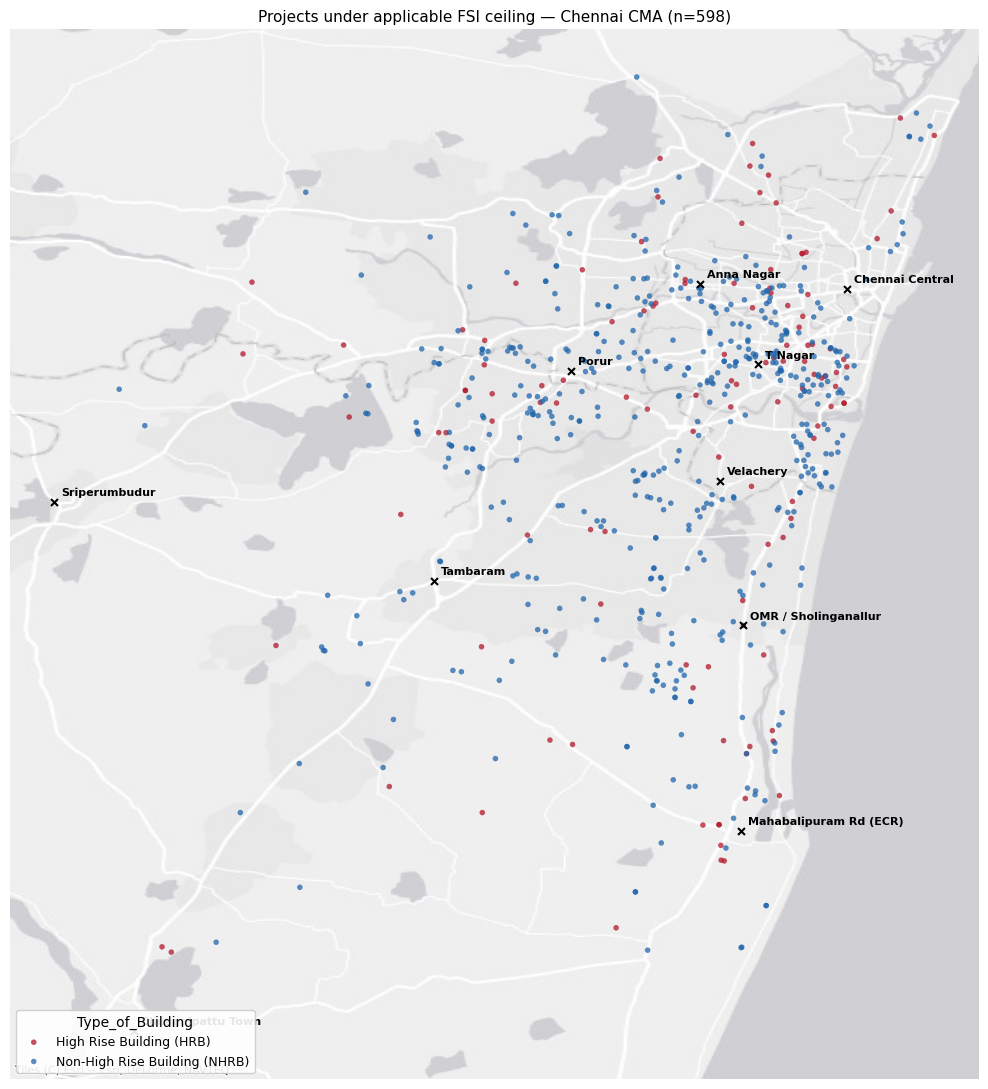

In [112]:
landmarks = {
    'Chennai Central': (13.0827, 80.2707),
    'T Nagar': (13.0418, 80.2341),
    'Anna Nagar': (13.0850, 80.2101),
    'Velachery': (12.9791, 80.2183),
    'OMR / Sholinganallur': (12.9010, 80.2279),
    'Tambaram': (12.9249, 80.1000),
    'Porur': (13.0382, 80.1565),
    'Sriperumbudur': (12.9675, 79.9430),
    'Mahabalipuram Rd (ECR)': (12.7900, 80.2270),
    'Chengalpattu Town': (12.6819, 79.9761),
}

fig, ax = plt.subplots(figsize=(10, 11))

type_colors = {
    'High Rise Building (HRB)': '#b2182b',
    'Non-High Rise Building (NHRB)': '#2166ac',
}

for building_type, color in type_colors.items():
    subset = gdf[gdf['Type_of_Building'] == building_type]
    ax.scatter(subset.geometry.x, subset.geometry.y,
               color=color, s=16, alpha=0.75, edgecolor='none', label=building_type)

# add landmark reference points, converted to the same Web Mercator projection
landmark_gdf = gpd.GeoDataFrame(
    {'name': list(landmarks.keys())},
    geometry=gpd.points_from_xy([v[1] for v in landmarks.values()], [v[0] for v in landmarks.values()]),
    crs='EPSG:4326'
).to_crs(epsg=3857)

ax.scatter(landmark_gdf.geometry.x, landmark_gdf.geometry.y,
           color='black', s=25, marker='x', zorder=5)

for _, row in landmark_gdf.iterrows():
    ax.annotate(row['name'], (row.geometry.x, row.geometry.y),
                fontsize=8, fontweight='bold', color='black',
                xytext=(5, 5), textcoords='offset points')

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldGrayCanvas, zoom='auto')
ax.set_axis_off()
ax.set_title(f'Projects under applicable FSI ceiling — Chennai CMA (n={len(gdf)})', fontsize=11)
ax.legend(loc='lower left', fontsize=9, framealpha=0.9, title='Type_of_Building')

plt.tight_layout()
plt.show()

In [113]:
# Basemap with bouding lats and lons . Also selecting only projects rows that have not acheived FSI ceiling


CMA_LAT_MIN, CMA_LAT_MAX = 12.70, 13.25
CMA_LON_MIN, CMA_LON_MAX = 79.95, 80.35
target_districts = ['Chennai', 'Kancheepuram', 'Chengalpattu']

base = df[
    df['Districts'].isin(target_districts) &
    df['Latitude'].between(CMA_LAT_MIN, CMA_LAT_MAX) &
    df['Longitude'].between(CMA_LON_MIN, CMA_LON_MAX)
].copy()

# Filter to only projects under their applicable FSI ceiling —
# HRB compares against Max_Premium_FSI (their real ceiling, since they can access premium FSI)
# NHRB compares against Permissable_FSI (base FSI only, no premium access)
is_hrb = base['Type_of_Building'] == 'High Rise Building (HRB)'
under_ceiling = np.where(
    is_hrb,
    base['FE_FSI'] < base['FE_Max_Premium_FSI'],
    base['FE_FSI'] < base['FE_Permissable_FSI']
)
base = base[under_ceiling].copy()

print(f"Projects under applicable FSI ceiling (Chennai CMA): {len(base)}")

gdf_base = gpd.GeoDataFrame(
    base,
    geometry=gpd.points_from_xy(base['Longitude'], base['Latitude']),
    crs='EPSG:4326').to_crs(epsg=3857)

Projects under applicable FSI ceiling (Chennai CMA): 196


In [114]:
# Landmarks on Map

landmarks = {
    'Chennai Central': (13.0827, 80.2707),
    'T Nagar': (13.0418, 80.2341),
    'Anna Nagar': (13.0850, 80.2101),
    'Velachery': (12.9791, 80.2183),
    'OMR / Sholinganallur': (12.9010, 80.2279),
    'Tambaram': (12.9249, 80.1000),
    'Porur': (13.0382, 80.1565),
    'Sriperumbudur': (12.9675, 79.9430),
    'Mahabalipuram Rd (ECR)': (12.7900, 80.2270),
    'Chengalpattu Town': (12.6819, 79.9761),
}

landmark_gdf = gpd.GeoDataFrame(
    {'name': list(landmarks.keys())},
    geometry=gpd.points_from_xy([v[1] for v in landmarks.values()], [v[0] for v in landmarks.values()]),
    crs='EPSG:4326'
).to_crs(epsg=3857)

def add_landmarks(ax):
    ax.scatter(landmark_gdf.geometry.x, landmark_gdf.geometry.y,
               color='black', s=25, marker='x', zorder=5)
    for _, row in landmark_gdf.iterrows():
        ax.annotate(row['name'], (row.geometry.x, row.geometry.y),
                    fontsize=8, fontweight='bold', color='black',
                    xytext=(5, 5), textcoords='offset points')

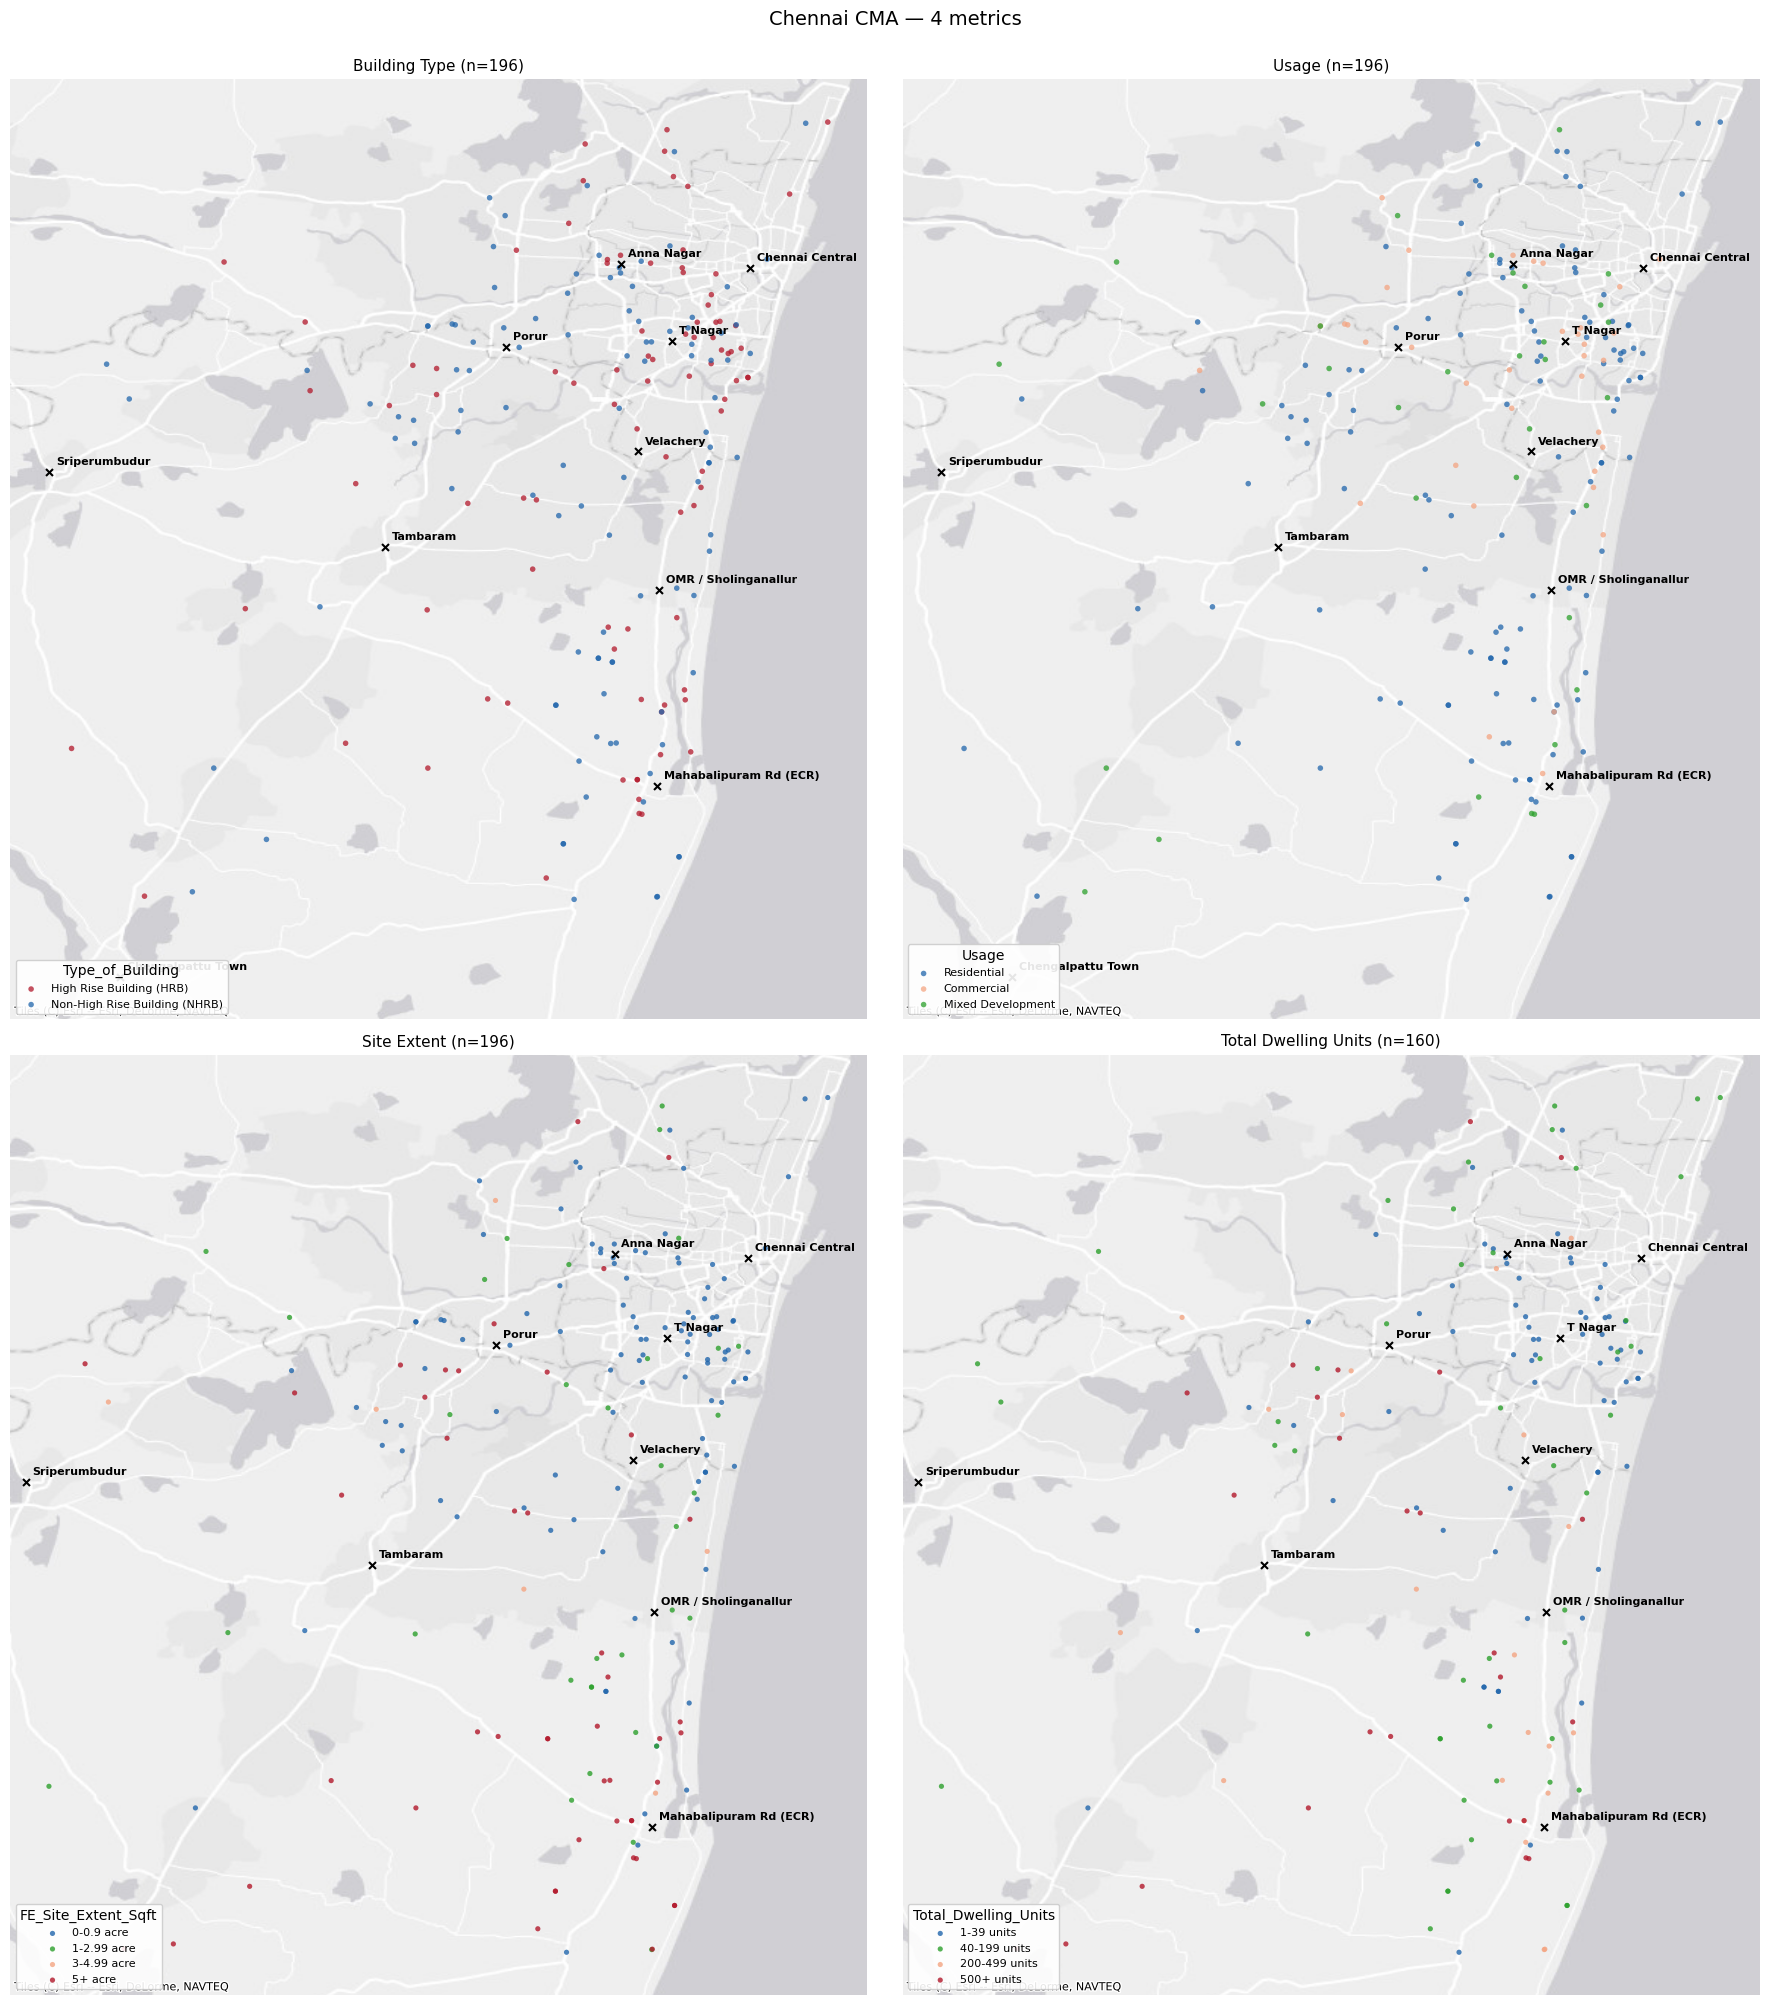

In [115]:
# The Map 


fig, axes = plt.subplots(2, 2, figsize=(18, 20))
axes = axes.flatten()

# --- Panel 1: High Rise vs Non-High Rise ---
type_colors = {'High Rise Building (HRB)': '#b2182b', 'Non-High Rise Building (NHRB)': '#2166ac'}
for building_type, color in type_colors.items():
    subset = gdf_base[gdf_base['Type_of_Building'] == building_type]
    axes[0].scatter(subset.geometry.x, subset.geometry.y, color=color, s=16, alpha=0.75, edgecolor='none', label=building_type)
add_landmarks(axes[0])
ctx.add_basemap(axes[0], source=ctx.providers.Esri.WorldGrayCanvas, zoom='auto')
axes[0].set_axis_off()
axes[0].set_title(f'Building Type (n={len(gdf_base)})', fontsize=11)
axes[0].legend(loc='lower left', fontsize=8, framealpha=0.9, title='Type_of_Building')

# --- Panel 2: Usage ---
usage_colors = {'Residential': '#2166ac', 'Commercial': '#f4a582', 'Mixed Development': '#2ca02c'}
for usage_type, color in usage_colors.items():
    subset = gdf_base[gdf_base['Usage'] == usage_type]
    axes[1].scatter(subset.geometry.x, subset.geometry.y, color=color, s=16, alpha=0.75, edgecolor='none', label=usage_type)
add_landmarks(axes[1])
ctx.add_basemap(axes[1], source=ctx.providers.Esri.WorldGrayCanvas, zoom='auto')
axes[1].set_axis_off()
axes[1].set_title(f'Usage (n={len(gdf_base)})', fontsize=11)
axes[1].legend(loc='lower left', fontsize=8, framealpha=0.9, title='Usage')

# --- Panel 3: Site Extent ---
ACRE_TO_SQFT = 43560
site_df = gdf_base.dropna(subset=['FE_Site_Extent_Sqft'])
acre_bins_sqft = [0, 0.9 * ACRE_TO_SQFT, 2.99 * ACRE_TO_SQFT, 4.99 * ACRE_TO_SQFT, np.inf]
acre_labels = ['0-0.9 acre', '1-2.99 acre', '3-4.99 acre', '5+ acre']
add_binned_layer(axes[2], site_df, 'FE_Site_Extent_Sqft', bins=acre_bins_sqft, bin_labels=acre_labels)
add_landmarks(axes[2])
axes[2].set_title(f'Site Extent (n={len(site_df)})', fontsize=11)


# --- Panel 4: Total Dwelling Units — fixed bins ---
units_df = gdf_base.dropna(subset=['Total_Dwelling_Units'])
unit_bins = [0, 39, 199, 499, np.inf]
unit_labels = ['1-39 units', '40-199 units', '200-499 units', '500+ units']

add_binned_layer(axes[3], units_df, 'Total_Dwelling_Units', bins=unit_bins, bin_labels=unit_labels)
add_landmarks(axes[3])
axes[3].set_title(f'Total Dwelling Units (n={len(units_df)})', fontsize=11)

plt.suptitle('Chennai CMA — 4 metrics', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()